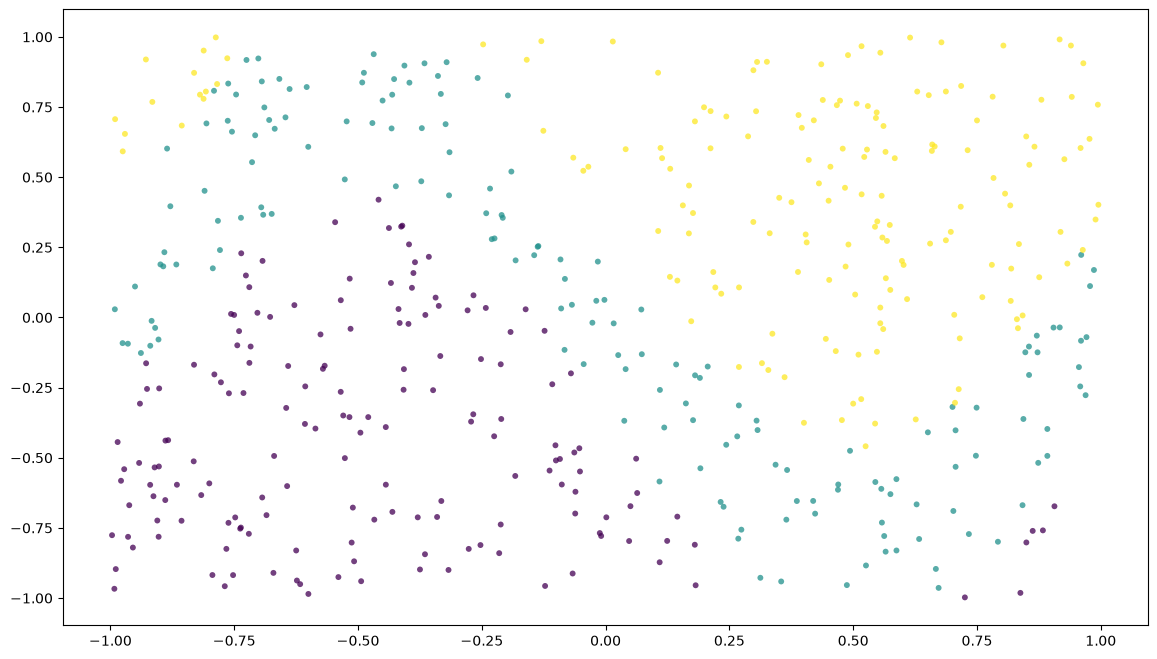

7750 5136 2614


In [1]:
from experiments import *

WEIGHTED CONTRASTIVE PARA PALIAR PROBLEMA ENTRENAMIENTO DESBALANCEADO ENTRE CLASES: margin 0.5

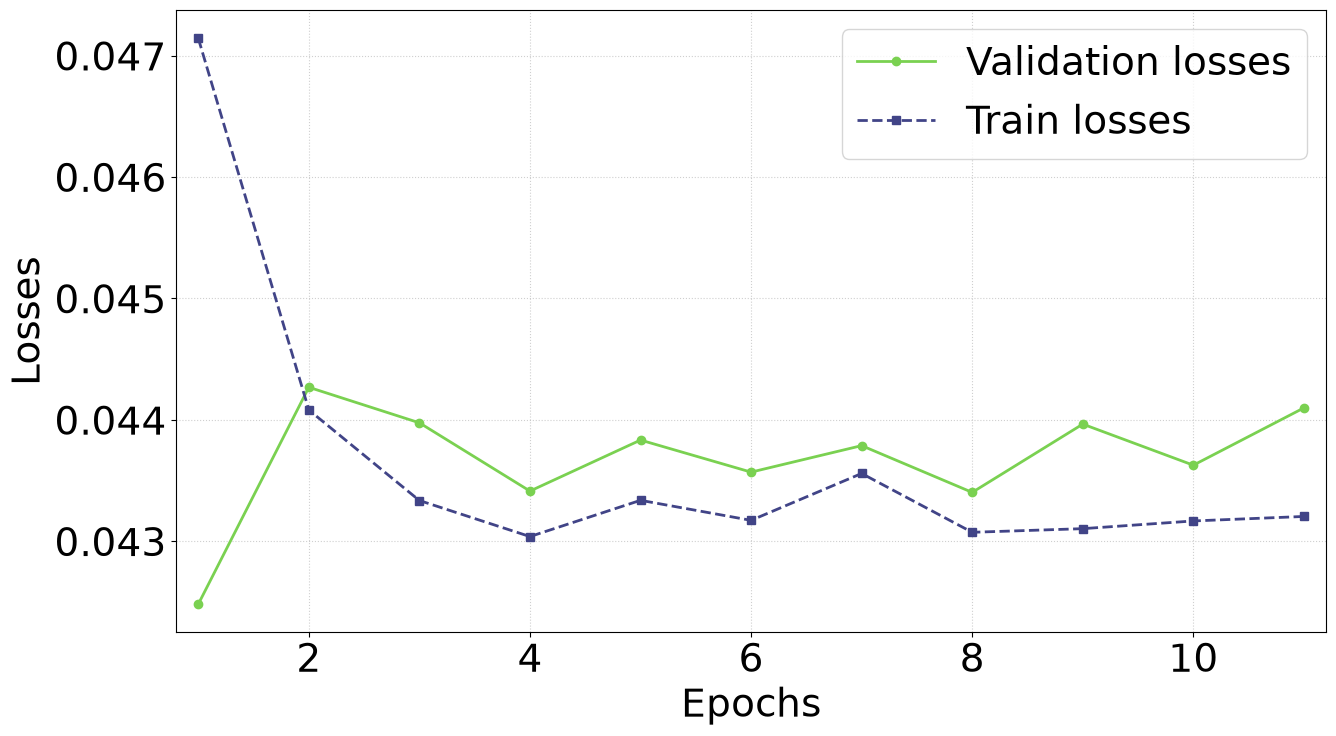

In [2]:
model = models_overlap['angle-twolocal-1']
layers = 5
similarity_measurement = model.qnode_generator(layers)
predict = compile_predict(similarity_measurement)

result = train_model(evaluate=True, model=model, layers=layers, dataset=dataset, seeds=SEEDS_EVALUATE)
(model.result)[layers] = result

loss_v_epochs(result.best, 5, 'angle-twolocal-1')
validation_output = predict(dataset.threshold_val.features, result.best.theta)
roc = roc_curve(y_true=dataset.threshold_val.labels, y_score=validation_output)
fpr, tpr, thresholds = roc
output = predict(dataset.test.features, result.best.theta)

In [4]:
# =========================================================
# OPTIMAL THRESHOLD FOR ACCURACY
# =========================================================
accuracies = []

for t in thresholds:
    y_pred = (validation_output >= t).astype(int)
    accuracies.append(
        accuracy_score(
            dataset.threshold_val.labels,
            y_pred
        )
    )

idx_accuracy = np.argmax(accuracies)
threshold_accuracy = thresholds[idx_accuracy]

# Test
y_pred_accuracy = (output >= threshold_accuracy).astype(jnp.int64)
test_accuracy = accuracy_score(y_true=dataset.test.labels, y_pred=y_pred_accuracy)

same = validation_output[dataset.threshold_val.labels == 1]
different = validation_output[dataset.threshold_val.labels == 0]
print('-------------------------------------------------------------')

print(f"Accuracy-optimal threshold: {threshold_accuracy:.6f}")
print(f"Accuracy-optimal val acc:   {accuracies[idx_accuracy]:.6f}")
print(f"Accuracy-optimal test acc:  {test_accuracy:.6f}")

print()

print('-------------------------------------------------------------')
print("Same:")
print(" mean:", np.mean(same))
print(" std :", np.std(same))
print(" min :", np.min(same))
print(" max :", np.max(same))

print("Different:")
print(" mean:", np.mean(different))
print(" std :", np.std(different))
print(" min :", np.min(different))
print(" max :", np.max(different))
print('-------------------------------------------------------------')


# =========================================================
# YOUDEN OPTIMAL THRESHOLD FOR ACCURACY
# =========================================================
youden_j = tpr - fpr
idx = np.argmax(youden_j)

threshold_youden = thresholds[idx]
same = validation_output[dataset.threshold_val.labels == 1]
different = validation_output[dataset.threshold_val.labels == 0]

y_pred = (output >= threshold_youden).astype(jnp.int64)
test_accuracy_youden = accuracy_score(y_true=dataset.test.labels, y_pred=y_pred)

print(f"Youden threshold:            {threshold_youden:.6f}")
print(f"Youden val acc:              "
      f"{accuracy_score(dataset.threshold_val.labels, 
        (validation_output >= threshold_youden).astype(int)):.6f}")

print(f"Youden test acc:             {test_accuracy_youden:.6f}")

print("Same:")
print(" mean:", np.mean(same))
print(" std :", np.std(same))
print(" min :", np.min(same))
print(" max :", np.max(same))

print("Different:")
print(" mean:", np.mean(different))
print(" std :", np.std(different))
print(" min :", np.min(different))
print(" max :", np.max(different))
print('-------------------------------------------------------------')
        

print(f'L={layers}:  best threshold {result.best.threshold} | val loss {result.best.best_val_loss:.4f} |  train loss {result.best.final_train_loss:.4f} | '
                  f'avg loss {np.average(result.val_over_seeds):.4f}  +- {np.std(result.val_over_seeds):.4f} '
                  f' | accuracy = {result.best.accuracy:.3f} | auc {result.best.auc:.3f} | epochs {result.best.epochs}' )


-------------------------------------------------------------
Accuracy-optimal threshold: 0.855832
Accuracy-optimal val acc:   0.770982
Accuracy-optimal test acc:  0.792903

-------------------------------------------------------------
Same:
 mean: 0.845604765444158
 std : 0.14087653792724295
 min : 0.16639389604912094
 max : 0.999428550247648
Different:
 mean: 0.545073399225967
 std : 0.25778248074148996
 min : 0.10886527346414164
 max : 0.9919246634545275
-------------------------------------------------------------
Youden threshold:            0.706164
Youden val acc:              0.745377
Youden test acc:             0.717032
Same:
 mean: 0.845604765444158
 std : 0.14087653792724295
 min : 0.16639389604912094
 max : 0.999428550247648
Different:
 mean: 0.545073399225967
 std : 0.25778248074148996
 min : 0.10886527346414164
 max : 0.9919246634545275
-------------------------------------------------------------
L=5:  best threshold 0.7061638884538565 | val loss 0.0425 |  train loss 0.

In [5]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(
    dataset.test.labels,
    y_pred_accuracy
)

print("Balanced accuracy:", balanced_acc)

Balanced accuracy: 0.7596864892372011


BCE

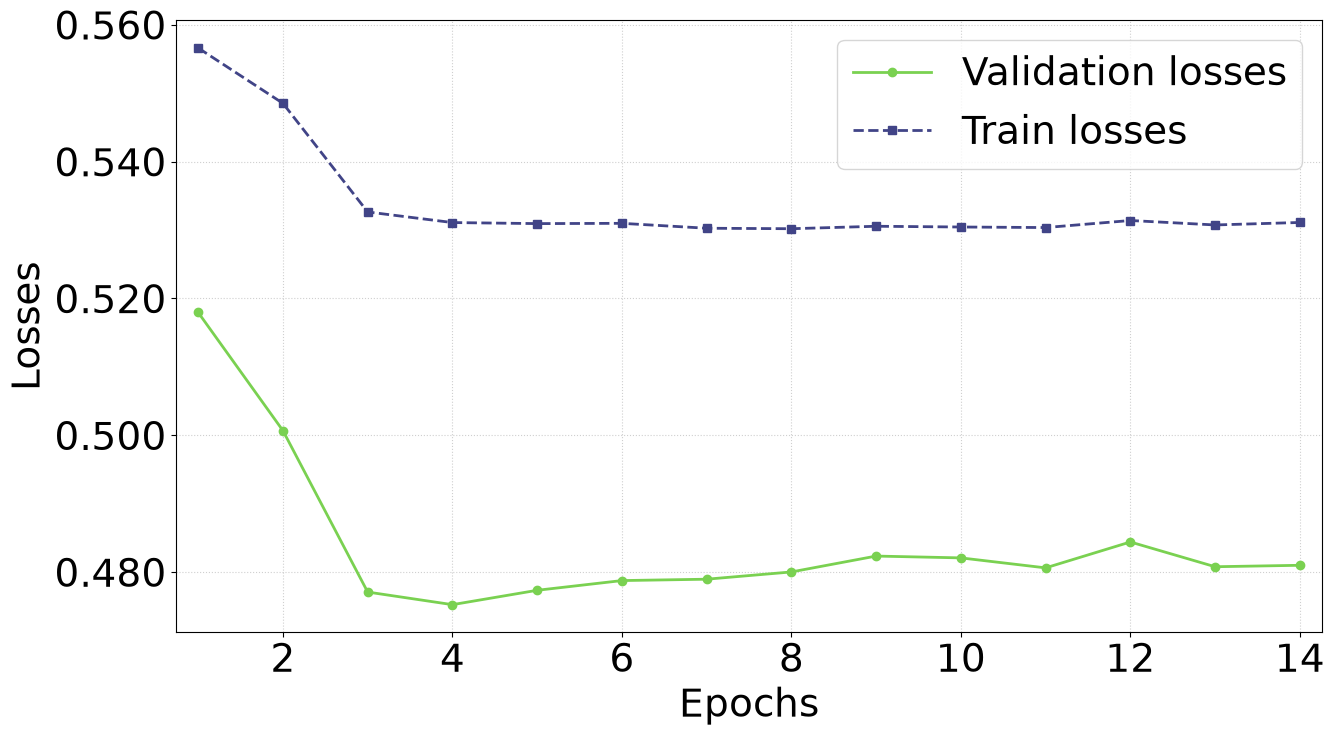

In [3]:
model = models_overlap['angle-twolocal-1']
layers = 5
similarity_measurement = model.qnode_generator(layers)
predict = compile_predict(similarity_measurement)

result = train_model(evaluate=True, model=model, layers=layers, dataset=dataset, seeds=SEEDS_EVALUATE)
(model.result)[layers] = result

loss_v_epochs(result.best, 5, 'angle-twolocal-1')
validation_output = predict(dataset.threshold_val.features, result.best.theta)
roc = roc_curve(y_true=dataset.threshold_val.labels, y_score=validation_output)
fpr, tpr, thresholds = roc
output = predict(dataset.test.features, result.best.theta)

In [ ]:
# =========================================================
# OPTIMAL THRESHOLD FOR ACCURACY
# =========================================================
accuracies = []

for t in thresholds:
    y_pred = (validation_output >= t).astype(int)
    accuracies.append(
        accuracy_score(
            dataset.threshold_val.labels,
            y_pred
        )
    )

idx_accuracy = np.argmax(accuracies)
threshold_accuracy = thresholds[idx_accuracy]

# Test
y_pred_accuracy = (output >= threshold_accuracy).astype(jnp.int64)
test_accuracy = accuracy_score(y_true=dataset.test.labels, y_pred=y_pred_accuracy)

same = validation_output[dataset.threshold_val.labels == 1]
different = validation_output[dataset.threshold_val.labels == 0]
print('-------------------------------------------------------------')

print(f"Accuracy-optimal threshold: {threshold_accuracy:.6f}")
print(f"Accuracy-optimal val acc:   {accuracies[idx_accuracy]:.6f}")
print(f"Accuracy-optimal test acc:  {test_accuracy:.6f}")

print()

print('-------------------------------------------------------------')
print("Same:")
print(" mean:", np.mean(same))
print(" std :", np.std(same))
print(" min :", np.min(same))
print(" max :", np.max(same))

print("Different:")
print(" mean:", np.mean(different))
print(" std :", np.std(different))
print(" min :", np.min(different))
print(" max :", np.max(different))
print('-------------------------------------------------------------')


# =========================================================
# YOUDEN OPTIMAL THRESHOLD FOR ACCURACY
# =========================================================
youden_j = tpr - fpr
idx = np.argmax(youden_j)

threshold_youden = thresholds[idx]
same = validation_output[dataset.threshold_val.labels == 1]
different = validation_output[dataset.threshold_val.labels == 0]

y_pred = (output >= threshold_youden).astype(jnp.int64)
test_accuracy_youden = accuracy_score(y_true=dataset.test.labels, y_pred=y_pred)

print(f"Youden threshold:            {threshold_youden:.6f}")
print(f"Youden val acc:              "
      f"{accuracy_score(dataset.threshold_val.labels, 
        (validation_output >= threshold_youden).astype(int)):.6f}")

print(f"Youden test acc:             {test_accuracy_youden:.6f}")

print("Same:")
print(" mean:", np.mean(same))
print(" std :", np.std(same))
print(" min :", np.min(same))
print(" max :", np.max(same))

print("Different:")
print(" mean:", np.mean(different))
print(" std :", np.std(different))
print(" min :", np.min(different))
print(" max :", np.max(different))
print('-------------------------------------------------------------')
        

print(f'L={layers}:  best threshold {result.best.threshold} | val loss {result.best.best_val_loss:.4f} |  train loss {result.best.final_train_loss:.4f} | '
                  f'avg loss {np.average(result.val_over_seeds):.4f}  +- {np.std(result.val_over_seeds):.4f} '
                  f' | accuracy = {result.best.accuracy:.3f} | auc {result.best.auc:.3f} | epochs {result.best.epochs}' )

-------------------------------------------------------------
Accuracy-optimal threshold: 0.596025
Accuracy-optimal val acc:   0.776671
Accuracy-optimal test acc:  0.768387

-------------------------------------------------------------
Same:
 mean: 0.5874902225521641
 std : 0.258666441052927
 min : 0.06702382261558824
 max : 0.9989704699198196
Different:
 mean: 0.25643583264334663
 std : 0.2254087266935583
 min : 0.0007465844352563777
 max : 0.96911602552828
-------------------------------------------------------------
Youden threshold:            0.389245
Youden val acc:              0.770982
Youden test acc:             0.758065
Same:
 mean: 0.5874902225521641
 std : 0.258666441052927
 min : 0.06702382261558824
 max : 0.9989704699198196
Different:
 mean: 0.25643583264334663
 std : 0.2254087266935583
 min : 0.0007465844352563777
 max : 0.96911602552828
-------------------------------------------------------------
L=5:  best threshold 0.3892448945459439 | val loss 0.4752 |  train loss 

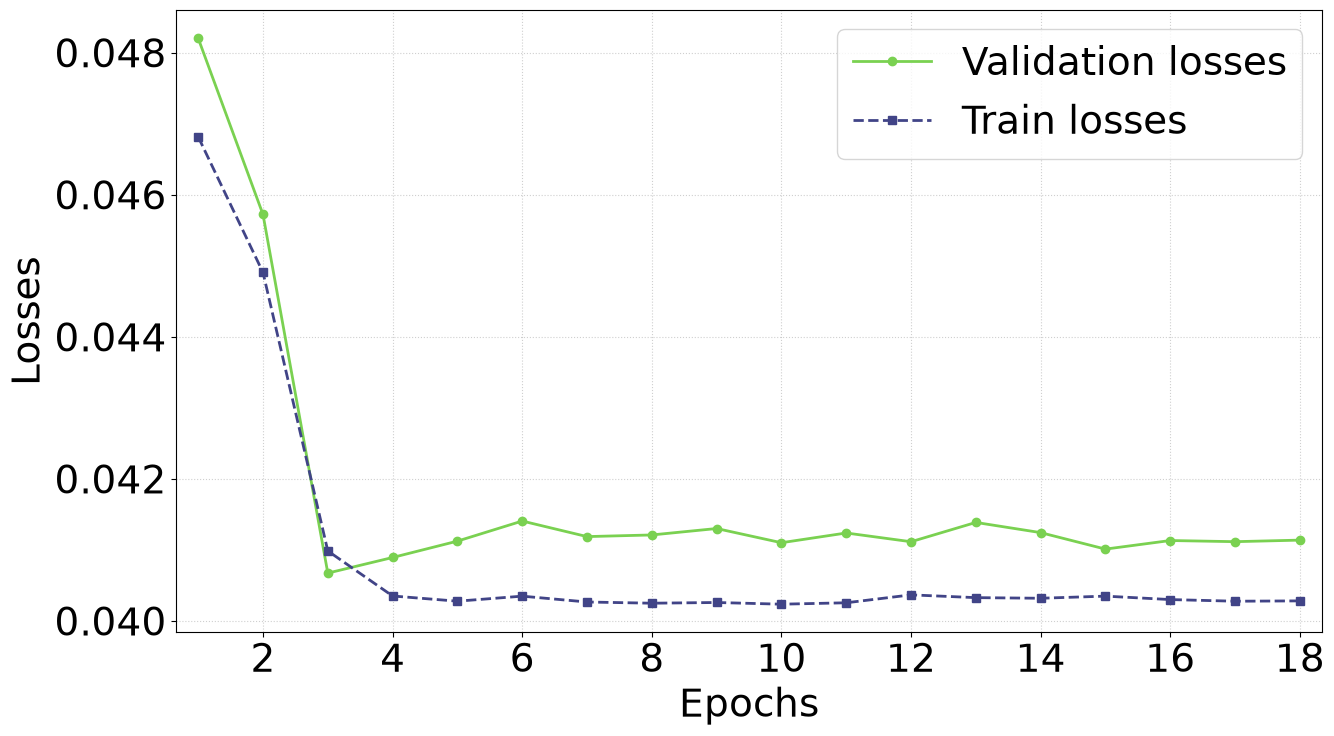

In [ ]:
model = models_overlap['angle-twolocal-1']
model.hyperparameters = HyperparametersModel(patience=15, tolerance=1e-5, learning_rate=0.001)
layers = 5
similarity_measurement = model.qnode_generator(layers)
predict = compile_predict(similarity_measurement)

result = train_model(evaluate=True, model=model, layers=layers, dataset=dataset, seeds=SEEDS_EVALUATE)
(model.result)[layers] = result

loss_v_epochs(result.best, 5, 'angle-twolocal-1')
validation_output = predict(dataset.threshold_val.features, result.best.theta)
roc = roc_curve(y_true=dataset.threshold_val.labels, y_score=validation_output)
fpr, tpr, thresholds = roc
output = predict(dataset.test.features, result.best.theta)

MARGIN 0.5

In [10]:
from sklearn.metrics import balanced_accuracy_score

# =========================================================
# OPTIMAL THRESHOLD FOR ACCURACY
# =========================================================
accuracies = []

for t in thresholds:
    y_pred = (validation_output >= t).astype(int)
    accuracies.append(
        accuracy_score(
            dataset.threshold_val.labels,
            y_pred
        )
    )

idx_accuracy = np.argmax(accuracies)
threshold_accuracy = thresholds[idx_accuracy]

# Test
y_pred_accuracy = (output >= threshold_accuracy).astype(jnp.int64)
test_accuracy = accuracy_score(y_true=dataset.test.labels, y_pred=y_pred_accuracy)

same = validation_output[dataset.threshold_val.labels == 1]
different = validation_output[dataset.threshold_val.labels == 0]
print('-------------------------------------------------------------')

print(f"Accuracy-optimal threshold: {threshold_accuracy:.6f}")
print(f"Accuracy-optimal val acc:   {accuracies[idx_accuracy]:.6f}")
print(f"Accuracy-optimal test acc:  {test_accuracy:.6f}")

print()

print('-------------------------------------------------------------')
print("Same:")
print(" mean:", np.mean(same))
print(" std :", np.std(same))
print(" min :", np.min(same))
print(" max :", np.max(same))

print("Different:")
print(" mean:", np.mean(different))
print(" std :", np.std(different))
print(" min :", np.min(different))
print(" max :", np.max(different))




balanced_acc = balanced_accuracy_score(
    dataset.test.labels,
    y_pred_accuracy
)

print("Balanced accuracy:", balanced_acc)  
print('-------------------------------------------------------------')



# =========================================================
# YOUDEN OPTIMAL THRESHOLD FOR ACCURACY
# =========================================================
youden_j = tpr - fpr
idx = np.argmax(youden_j)

threshold_youden = thresholds[idx]
same = validation_output[dataset.threshold_val.labels == 1]
different = validation_output[dataset.threshold_val.labels == 0]

y_pred = (output >= threshold_youden).astype(jnp.int64)
test_accuracy_youden = accuracy_score(y_true=dataset.test.labels, y_pred=y_pred)

print(f"Youden threshold:            {threshold_youden:.6f}")
print(f"Youden val acc:              "
      f"{accuracy_score(dataset.threshold_val.labels, 
        (validation_output >= threshold_youden).astype(int)):.6f}")

print(f"Youden test acc:             {test_accuracy_youden:.6f}")

print("Same:")
print(" mean:", np.mean(same))
print(" std :", np.std(same))
print(" min :", np.min(same))
print(" max :", np.max(same))

print("Different:")
print(" mean:", np.mean(different))
print(" std :", np.std(different))
print(" min :", np.min(different))
print(" max :", np.max(different))


balanced_acc = balanced_accuracy_score(
    dataset.test.labels,
    y_pred
)

print("Balanced accuracy:", balanced_acc)
print('-------------------------------------------------------------') 


print(f'L={layers}:   val loss {result.best.best_val_loss:.4f} |  train loss {result.best.final_train_loss:.4f} | '
                  f'avg loss {np.average(result.val_over_seeds):.4f}  +- {np.std(result.val_over_seeds):.4f} '
                  f' | accuracy = {test_accuracy_youden:.3f} | auc {result.best.auc:.3f} | epochs {result.best.epochs}' )

-------------------------------------------------------------
Accuracy-optimal threshold: 0.797366
Accuracy-optimal val acc:   0.769559
Accuracy-optimal test acc:  0.788387

-------------------------------------------------------------
Same:
 mean: 0.8070960060824464
 std : 0.137342945287784
 min : 0.4057313932231178
 max : 0.9996493326768502
Different:
 mean: 0.5048168182229833
 std : 0.2488820589272864
 min : 0.049056411561305815
 max : 0.9943150800871323
Balanced accuracy: 0.7388089862399206
-------------------------------------------------------------
Youden threshold:            0.673527
Youden val acc:              0.743954
Youden test acc:             0.754710
Same:
 mean: 0.8070960060824464
 std : 0.137342945287784
 min : 0.4057313932231178
 max : 0.9996493326768502
Different:
 mean: 0.5048168182229833
 std : 0.2488820589272864
 min : 0.049056411561305815
 max : 0.9943150800871323
Balanced accuracy: 0.7751092994348667
------------------------------------------------------------

In [11]:
for i, (tr, va) in enumerate(
    zip(result.best.train_losses, result.best.val_losses),
    start=1
):
    print(f"{i:2d}: train={tr:.8f}  val={va:.8f}")

 1: train=0.04681292  val=0.04820025
 2: train=0.04490314  val=0.04571965
 3: train=0.04098264  val=0.04067078
 4: train=0.04034855  val=0.04089050
 5: train=0.04027535  val=0.04112099
 6: train=0.04034617  val=0.04140389
 7: train=0.04026385  val=0.04118473
 8: train=0.04024687  val=0.04120782
 9: train=0.04025691  val=0.04129840
10: train=0.04023298  val=0.04109843
11: train=0.04025292  val=0.04123554
12: train=0.04036441  val=0.04111243
13: train=0.04032527  val=0.04138417
14: train=0.04031662  val=0.04124076
15: train=0.04034644  val=0.04100858
16: train=0.04029814  val=0.04112942
17: train=0.04027492  val=0.04111325
18: train=0.04027954  val=0.04113508


MARGIN 0.2

In [3]:
# =========================================================
# OPTIMAL THRESHOLD FOR ACCURACY
# =========================================================
accuracies = []

for t in thresholds:
    y_pred = (validation_output >= t).astype(int)
    accuracies.append(
        accuracy_score(
            dataset.threshold_val.labels,
            y_pred
        )
    )

idx_accuracy = np.argmax(accuracies)
threshold_accuracy = thresholds[idx_accuracy]

# Test
y_pred_accuracy = (output >= threshold_accuracy).astype(jnp.int64)
test_accuracy = accuracy_score(y_true=dataset.test.labels, y_pred=y_pred_accuracy)

same = validation_output[dataset.threshold_val.labels == 1]
different = validation_output[dataset.threshold_val.labels == 0]
print('-------------------------------------------------------------')

print(f"Accuracy-optimal threshold: {threshold_accuracy:.6f}")
print(f"Accuracy-optimal val acc:   {accuracies[idx_accuracy]:.6f}")
print(f"Accuracy-optimal test acc:  {test_accuracy:.6f}")

print()

print('-------------------------------------------------------------')
print("Same:")
print(" mean:", np.mean(same))
print(" std :", np.std(same))
print(" min :", np.min(same))
print(" max :", np.max(same))

print("Different:")
print(" mean:", np.mean(different))
print(" std :", np.std(different))
print(" min :", np.min(different))
print(" max :", np.max(different))
print('-------------------------------------------------------------')


# =========================================================
# YOUDEN OPTIMAL THRESHOLD FOR ACCURACY
# =========================================================
youden_j = tpr - fpr
idx = np.argmax(youden_j)

threshold_youden = thresholds[idx]
same = validation_output[dataset.threshold_val.labels == 1]
different = validation_output[dataset.threshold_val.labels == 0]

y_pred = (output >= threshold_youden).astype(jnp.int64)
test_accuracy_youden = accuracy_score(y_true=dataset.test.labels, y_pred=y_pred)

print(f"Youden threshold:            {threshold_youden:.6f}")
print(f"Youden val acc:              "
      f"{accuracy_score(dataset.threshold_val.labels, 
        (validation_output >= threshold_youden).astype(int)):.6f}")

print(f"Youden test acc:             {test_accuracy_youden:.6f}")

print("Same:")
print(" mean:", np.mean(same))
print(" std :", np.std(same))
print(" min :", np.min(same))
print(" max :", np.max(same))

print("Different:")
print(" mean:", np.mean(different))
print(" std :", np.std(different))
print(" min :", np.min(different))
print(" max :", np.max(different))
print('-------------------------------------------------------------')
        

print(f'L={layers}:  best threshold {result.best.threshold} | val loss {result.best.best_val_loss:.4f} |  train loss {result.best.final_train_loss:.4f} | '
                  f'avg loss {np.average(result.val_over_seeds):.4f}  +- {np.std(result.val_over_seeds):.4f} '
                  f' | accuracy = {result.best.accuracy:.3f} | auc {result.best.auc:.3f} | epochs {result.best.epochs}' )

-------------------------------------------------------------
Accuracy-optimal threshold: 0.574414
Accuracy-optimal val acc:   0.773826
Accuracy-optimal test acc:  0.768645

-------------------------------------------------------------
Same:
 mean: 0.6772851654065792
 std : 0.2263386696739317
 min : 0.044963379765770944
 max : 0.9991112609170885
Different:
 mean: 0.3132820879795538
 std : 0.2552659689352329
 min : 0.00035143385761330585
 max : 0.9852483335607848
-------------------------------------------------------------
Youden threshold:            0.476647
Youden val acc:              0.768137
Youden test acc:             0.738194
Same:
 mean: 0.6772851654065792
 std : 0.2263386696739317
 min : 0.044963379765770944
 max : 0.9991112609170885
Different:
 mean: 0.3132820879795538
 std : 0.2552659689352329
 min : 0.00035143385761330585
 max : 0.9852483335607848
-------------------------------------------------------------
L=5:  best threshold 0.4766469512357511 | val loss 0.1010 |  tra

In [ ]:
theta = result.best.theta
X = dataset.split.train.features[dataset.split.train.labels==1]
c1 = model.single_branch(layers=5, X=X, theta=theta)

print(jnp.mean(c1, axis=0))

print(jnp.mean(c1, axis=0)/jax.numpy.linalg.norm(np.mean(c1, axis=0)))

[ 0.43511572-0.43762308j  0.24948954+0.12181926j  0.01208502+0.15761497j
 -0.17048887+0.01722205j]
[ 0.60792876-0.61143196j  0.34857822+0.1702017j   0.01688477+0.22021423j
 -0.2382012 +0.02406206j]


In [ ]:
theta = result.best.theta
X = dataset.split.train.features[dataset.split.train.labels==0]
c0 = model.single_branch(layers=5, X=X, theta=theta)
print(c0)

[[ 4.12802118e-01-7.95886260e-01j  2.59617384e-01-8.70269173e-02j
   1.18363957e-01-1.07236265e-01j -2.92332356e-01-1.01077957e-01j]
 [ 6.68076344e-02-4.17419367e-01j  6.13612297e-01+4.36155753e-02j
   2.62931326e-02-1.88093348e-01j -5.40278408e-01-3.38975291e-01j]
 [ 1.79636375e-01-6.47791858e-01j  3.98304281e-01-1.92676340e-01j
   3.18306666e-02-2.40361233e-01j -5.29794833e-01-1.13387526e-01j]
 [ 5.18151331e-02-3.79249577e-01j  6.41113918e-01+7.83816413e-03j
   1.04871255e-02-2.08955717e-01j -5.32329679e-01-3.39483576e-01j]
 [-9.51276098e-02-4.13112138e-01j  5.19111762e-01-1.96784237e-01j
  -1.13933211e-01-3.87214735e-01j -5.39769643e-01-2.40459450e-01j]
 [ 2.14930175e-01-6.25805796e-01j  4.07122177e-01+1.94232234e-01j
   4.72757125e-02-9.46294612e-02j -4.94362505e-01-3.21112883e-01j]
 [ 9.44820412e-02-5.96777590e-01j  4.07068444e-01-2.22271182e-01j
  -6.49058845e-03-2.82857739e-01j -5.71944014e-01-1.12471650e-01j]
 [ 4.16232198e-01-7.90215317e-01j  1.58019805e-01+2.21937773e-01j
  -

In [ ]:
theta = result.best.theta
X = dataset.split.train.features[dataset.split.train.labels==2]
c2 = model.single_branch(layers=5, X=X, theta=theta)
print(c2)

[[ 0.43111846-0.62013852j  0.28928932-0.37203612j  0.38985913+0.17636495j
  -0.01798085+0.1550737j ]
 [ 0.32949774-0.68614833j  0.00124895-0.41384761j  0.34392346+0.25098319j
   0.15911569+0.20680084j]
 [ 0.04057405-0.64221457j -0.24029964-0.53680345j  0.10158661+0.39800563j
   0.23721212+0.12253338j]
 [ 0.01022139-0.56799069j -0.18276201-0.52834852j  0.31730225+0.47745661j
   0.17673668+0.0696175j ]
 [-0.01771686-0.62966293j -0.22999582-0.54458465j -0.14059376+0.3918391j
   0.27225768+0.0794447j ]
 [ 0.55781135+0.23227706j  0.05767929+0.69364335j -0.11014939+0.24286146j
  -0.27683538+0.05170557j]
 [ 0.34573594-0.54204602j  0.3231456 -0.40025796j  0.46188116+0.28150767j
   0.00332893+0.17155583j]
 [ 0.16289028-0.68976888j  0.0617342 -0.29887289j -0.40323684+0.2353642j
   0.26763879+0.33900259j]
 [ 0.57516174+0.14093438j  0.08379704+0.70191254j -0.20893905+0.21625267j
  -0.2309597 +0.07655184j]
 [ 0.13183948-0.55221137j  0.01375078-0.47580327j  0.46791562+0.44016988j
   0.12972442+0.146

In [ ]:
import numpy as np

def overlaps(A, B):
    G = A.conj() @ B.T          # productos internos, forma (len(A), len(B))
    return np.abs(G)**2

intra = overlaps(c0, c0)
print("intra clase 0:", intra[~np.eye(len(c0), dtype=bool)].mean(), "pm", intra[~np.eye(len(c0), dtype=bool)].std())

inter = overlaps(c0, c1)
inter2 = overlaps(c0, c2)
print("inter 0-1:", inter.mean(), "pm", inter.std())
print("inter 0-2:", inter2.mean(), "pm", inter2.std())

intra = overlaps(c1, c1)
print("intra clase 1:", intra[~np.eye(len(c1), dtype=bool)].mean(), "pm", intra[~np.eye(len(c1), dtype=bool)].std())

inter = overlaps(c1, c0)
inter2 = overlaps(c1, c2)
print("inter 1-0:", inter.mean(), "pm", inter.std())
print("inter 1-2:", inter2.mean(), "pm", inter2.std())

intra = overlaps(c2, c2)
print("intra clase 2:", intra[~np.eye(len(c2), dtype=bool)].mean(), "pm", intra[~np.eye(len(c2), dtype=bool)].std())


intra clase 0: 0.7183483361897107 pm 0.19883129613632927
inter 0-1: 0.4336077847563456 pm 0.22694881570963032
inter 0-2: 0.21002898909400505 pm 0.1585387032376741
intra clase 1: 0.5519056640174346 pm 0.2450670386419802
inter 1-0: 0.4336077847563456 pm 0.22694881570963032
inter 1-2: 0.41667112580253185 pm 0.21671243807766663
intra clase 2: 0.6346155513105091 pm 0.23312703079992345


model angle-twolocal-1


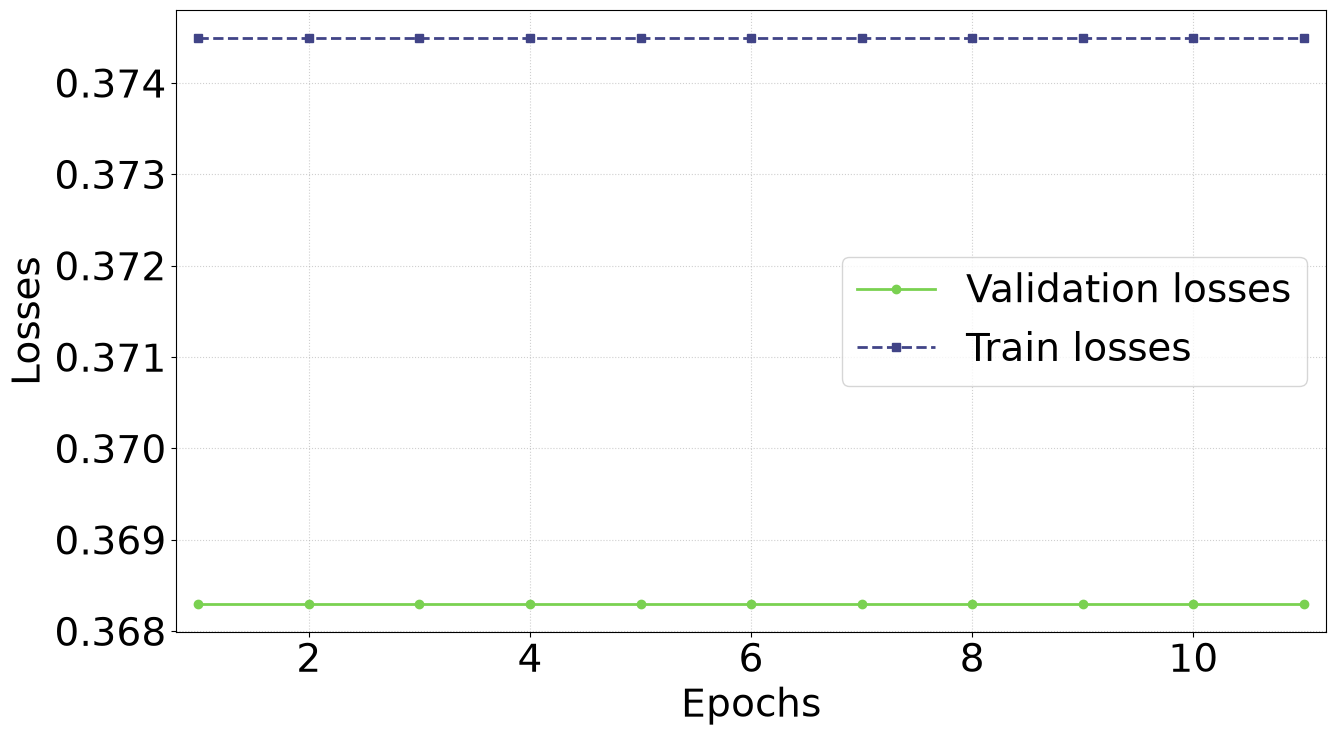

L=1:  val loss 0.3683 |  train loss 0.3745 | avg loss 0.3683  +- 0.0000  | accuracy = 0.470 | auc 0.754 | epochs 11


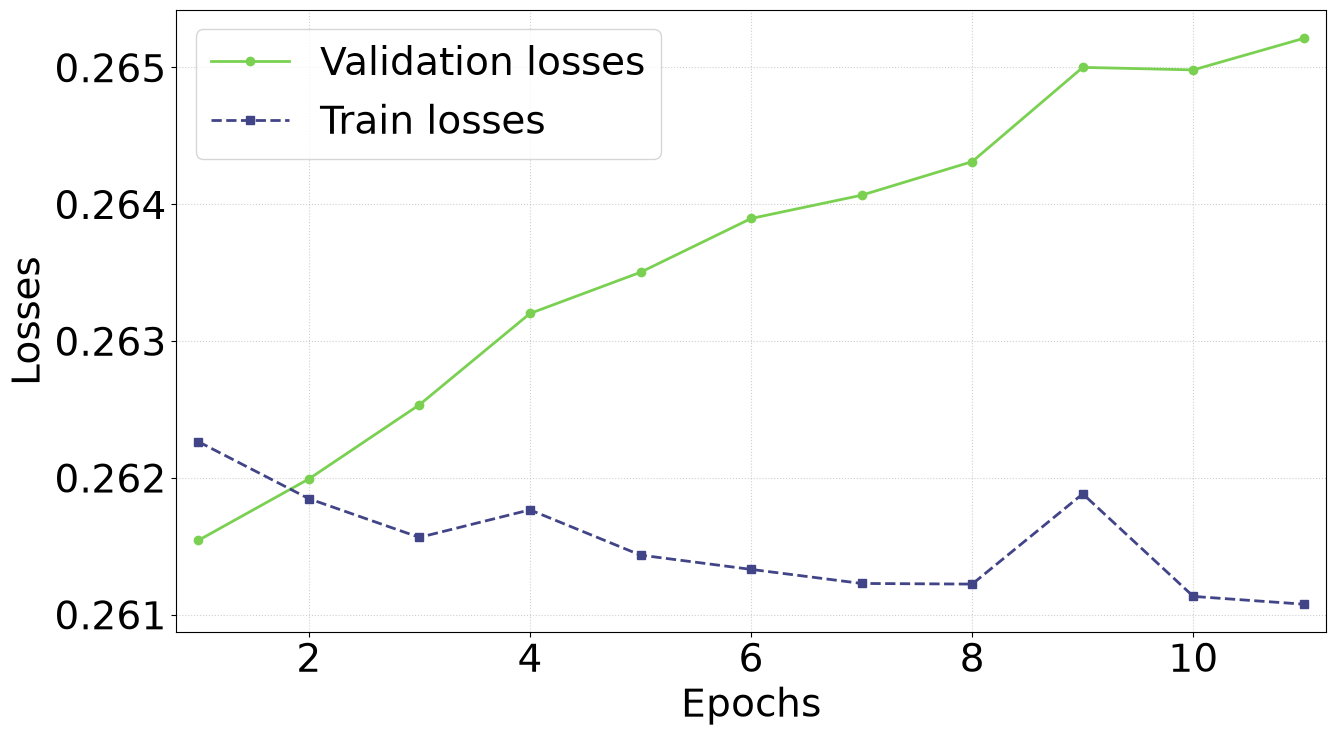

L=2:  val loss 0.2615 |  train loss 0.2623 | avg loss 0.2621  +- 0.0014  | accuracy = 0.677 | auc 0.793 | epochs 11


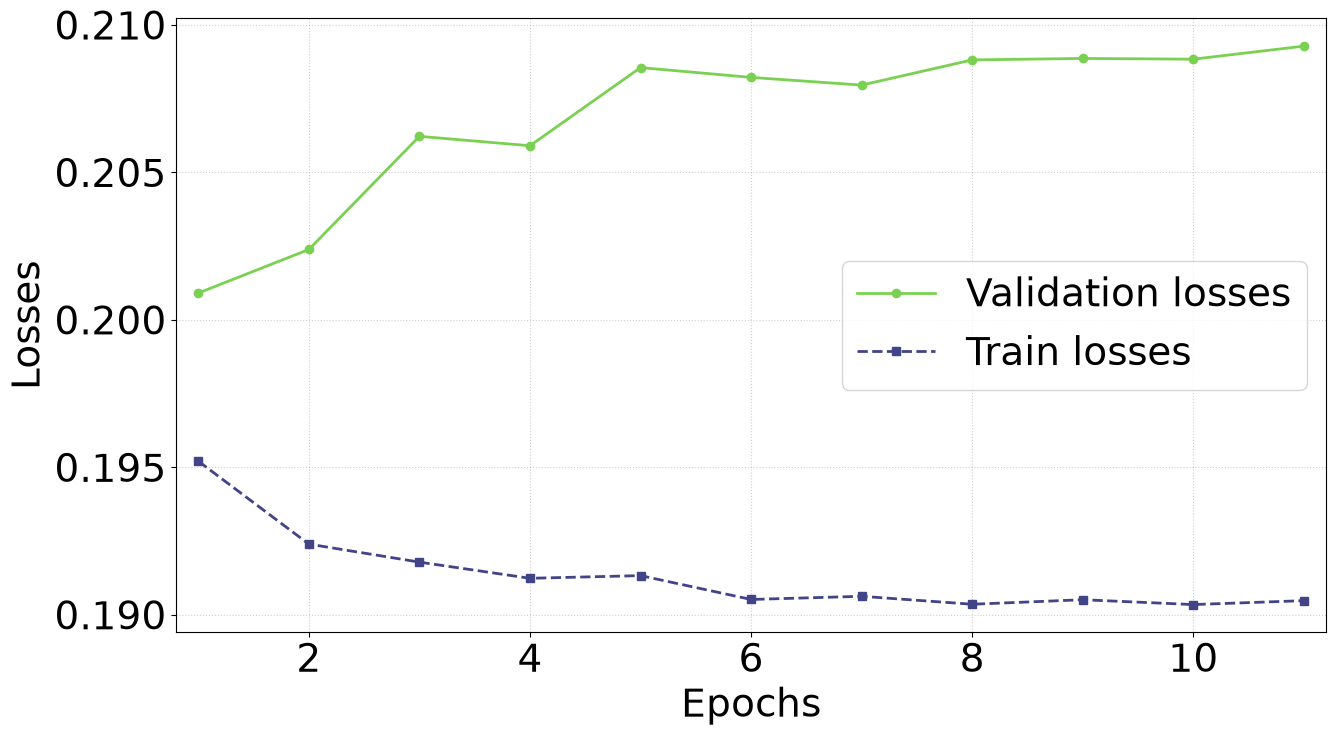

L=3:  val loss 0.2009 |  train loss 0.1952 | avg loss 0.2077  +- 0.0017  | accuracy = 0.724 | auc 0.762 | epochs 11


KeyboardInterrupt: 

In [ ]:
result = run_layers(models=models_overlap, dataset=dataset)

<h1>HYPERPARAMETERS SWEEP<h1>

<h3>BATCH SIZE<h3>

In [3]:
sweep_ov = hyperparameter_sweep(models=models_overlap, variable='batch_size', values=BATCH_SIZES, dataset=dataset)

model angle-twolocal-1
batch_size = 1:  loss 0.1904 | time 7.868 | avg loss 0.196553+-0.004993  | avg time 12.483+-4.259 | avg epochs 22.300000+-9.077995373429093
batch_size = 2:  loss 0.1912 | time 10.346 | avg loss 0.196711+-0.004376  | avg time 13.518+-4.601 | avg epochs 24.600000+-9.308061022576076
batch_size = 4:  loss 0.1915 | time 6.869 | avg loss 0.197219+-0.005252  | avg time 8.969+-4.212 | avg epochs 23.700000+-10.899999999999999
batch_size = 8:  loss 0.1909 | time 8.348 | avg loss 0.198280+-0.005863  | avg time 6.801+-3.027 | avg epochs 24.000000+-9.077444574328174
batch_size = 16:  loss 0.1904 | time 2.561 | avg loss 0.197633+-0.006596  | avg time 4.620+-3.155 | avg epochs 22.200000+-8.997777503361593
batch_size = 32:  loss 0.1890 | time 3.205 | avg loss 0.199191+-0.007435  | avg time 5.617+-3.338 | avg epochs 26.200000+-13.075167302944923
batch_size = 64:  loss 0.1884 | time 4.562 | avg loss 0.201302+-0.009817  | avg time 5.217+-3.332 | avg epochs 27.900000+-14.85563866011

KeyboardInterrupt: 

In [ ]:
sweep_sim =  hyperparameter_sweep(models=models_sim, variable='batch_size', values=BATCH_SIZES)

In [7]:
(models_overlap['angle-twolocal-1']).hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=16, learning_rate = 0.01)
models_overlap['angle-twolocal-2'].hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=8, learning_rate = 0.01)
models_overlap['angle-treetensor'].hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=8, learning_rate = 0.01)

models_sim['angle-twolocal-1'].hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=64, learning_rate = 0.01)
models_sim['angle-twolocal-2'].hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=8, learning_rate = 0.01)
models_sim['angle-treetensor'].hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=8, learning_rate = 0.01)

<h3>LEARNING RATE<h3>

In [8]:
sweep_ov = hyperparameter_sweep(models=models_overlap, variable='learning_rate', values=LEARNING_RATES, dataset=dataset)

model angle-twolocal-1
learning_rate = 1:  loss 0.1906 | time 2.896 | avg loss 0.201594+-0.006043  | avg time 3.011+-1.337 | avg epochs 17.700000+-7.887331614684398
learning_rate = 0.5:  loss 0.1896 | time 3.680 | avg loss 0.198050+-0.006804  | avg time 3.677+-1.826 | avg epochs 20.200000+-6.539113089708726
learning_rate = 0.1:  loss 0.1929 | time 5.394 | avg loss 0.200129+-0.004332  | avg time 3.802+-1.561 | avg epochs 22.500000+-8.868483523128406
learning_rate = 0.05:  loss 0.1897 | time 5.358 | avg loss 0.196430+-0.004892  | avg time 4.785+-2.675 | avg epochs 24.600000+-12.893409169028956
learning_rate = 0.01:  loss 0.1890 | time 2.888 | avg loss 0.199191+-0.007435  | avg time 4.234+-3.080 | avg epochs 26.200000+-13.075167302944923
learning_rate = 0.005:  loss 0.1877 | time 4.064 | avg loss 0.201333+-0.009996  | avg time 6.475+-3.159 | avg epochs 30.800000+-16.815469068687914
learning_rate = 0.001:  loss 0.1894 | time 23.686 | avg loss 0.206139+-0.008961  | avg time 7.746+-6.298 | a

KeyboardInterrupt: 

In [9]:
(models_overlap['angle-twolocal-1']).hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=16, learning_rate = 0.05)
models_overlap['angle-twolocal-2'].hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=8, learning_rate = 0.01)
models_overlap['angle-treetensor'].hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=8, learning_rate = 0.01)

models_sim['angle-twolocal-1'].hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=64, learning_rate = 0.01)
models_sim['angle-twolocal-2'].hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=8, learning_rate = 0.01)
models_sim['angle-treetensor'].hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=8, learning_rate = 0.01)

<h3>TOLERANCE<h3>

In [11]:
sweep_ov = hyperparameter_sweep(models=models_overlap, variable='tolerance', values=TOLERANCES, dataset=dataset)

model angle-twolocal-1
tolerance = 0.1:  loss 0.1937 | time 1.321 | avg loss 0.212109+-0.008240  | avg time 1.570+-0.779 | avg epochs 11.000000+-0.0
tolerance = 0.01:  loss 0.1905 | time 2.613 | avg loss 0.207126+-0.009819  | avg time 1.847+-0.593 | avg epochs 13.200000+-3.6000000000000005
tolerance = 0.001:  loss 0.1890 | time 1.837 | avg loss 0.202101+-0.010419  | avg time 2.569+-1.954 | avg epochs 18.400000+-9.86103442849684
tolerance = 0.0001:  loss 0.1890 | time 2.017 | avg loss 0.199191+-0.007435  | avg time 3.905+-2.353 | avg epochs 26.200000+-13.075167302944923
tolerance = 1e-05:  loss 0.1890 | time 1.834 | avg loss 0.199191+-0.007435  | avg time 3.553+-2.086 | avg epochs 26.200000+-13.075167302944923


KeyboardInterrupt: 

In [12]:
(models_overlap['angle-twolocal-1']).hyperparameters = HyperparametersModel(max_epochs = 500, patience=10, tolerance = 1e-4, batch_size=16, learning_rate = 0.05)

In [13]:
sweep_ov = hyperparameter_sweep(models=models_overlap, variable='patience', values=PATIENCES, dataset=dataset)

model angle-twolocal-1
patience = 1:  loss 0.1913 | time 0.411 | avg loss 0.208184+-0.008847  | avg time 0.595+-0.650 | avg epochs 3.300000+-1.7916472867168918
patience = 5:  loss 0.1890 | time 1.260 | avg loss 0.203374+-0.010096  | avg time 1.833+-0.991 | avg epochs 12.300000+-3.6891733491393435
patience = 10:  loss 0.1890 | time 1.762 | avg loss 0.199191+-0.007435  | avg time 4.496+-2.634 | avg epochs 26.200000+-13.075167302944923
patience = 15:  loss 0.1890 | time 2.408 | avg loss 0.197659+-0.006212  | avg time 5.118+-3.107 | avg epochs 39.200000+-22.319498202244603
patience = 20:  loss 0.1890 | time 2.974 | avg loss 0.197635+-0.006222  | avg time 6.431+-3.208 | avg epochs 46.100000+-23.910039732296557
patience = 25:  loss 0.1890 | time 3.823 | avg loss 0.197635+-0.006222  | avg time 9.566+-5.460 | avg epochs 51.100000+-23.910039732296557


KeyboardInterrupt: 

In [16]:
(models_overlap['angle-twolocal-1']).hyperparameters = HyperparametersModel(max_epochs = 500, patience=15, tolerance = 1e-4, batch_size=16, learning_rate = 0.001)

model angle-twolocal-1


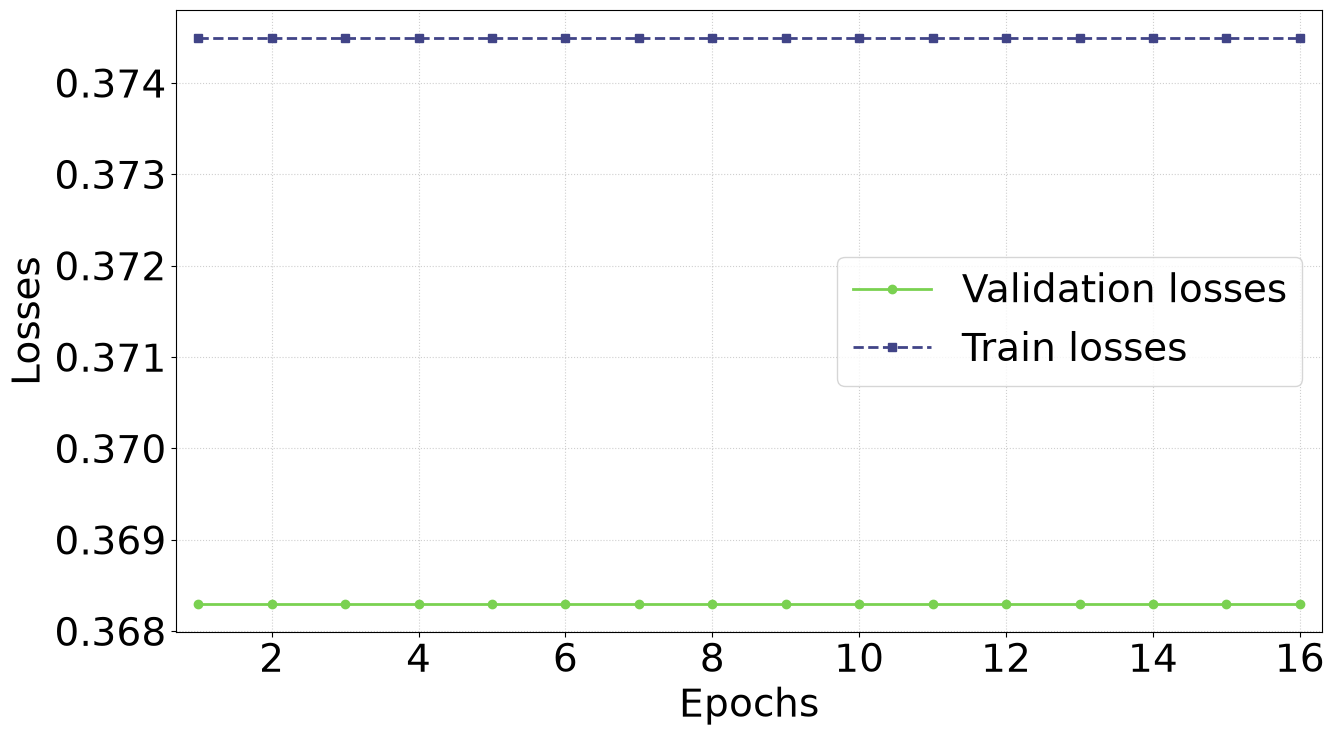

L=1:  val loss 0.3683 |  train loss 0.3745 | avg loss 0.3683  +- 0.0000  | accuracy = 0.470 | auc 0.754 | epochs 16


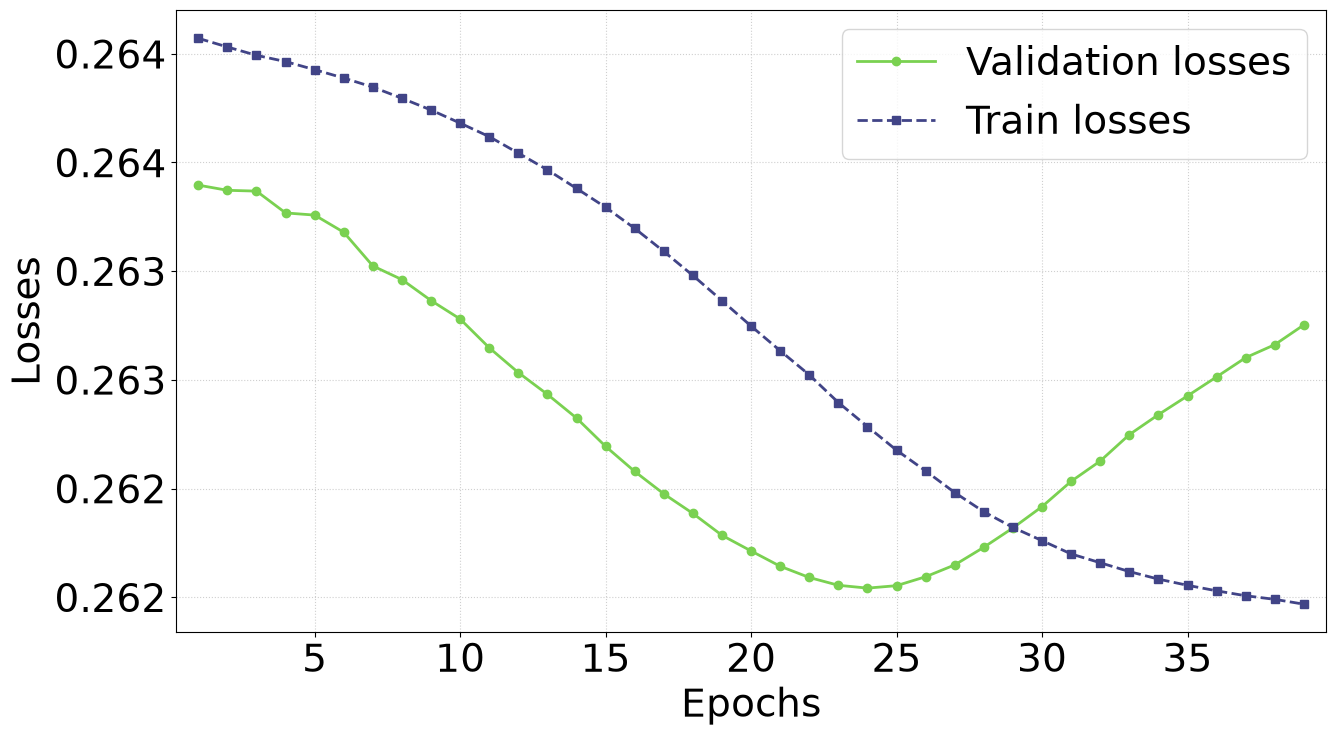

L=2:  val loss 0.2615 |  train loss 0.2623 | avg loss 0.2629  +- 0.0019  | accuracy = 0.677 | auc 0.793 | epochs 39


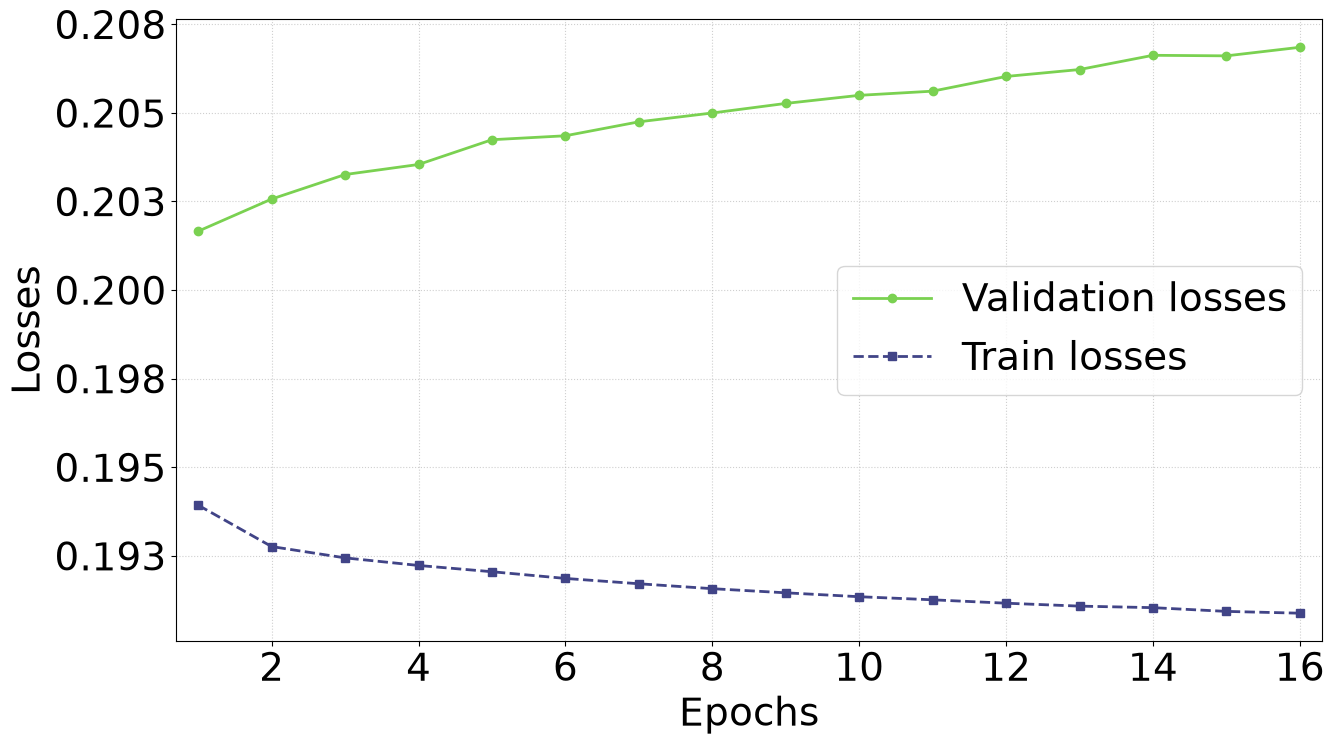

L=3:  val loss 0.2017 |  train loss 0.1939 | avg loss 0.2079  +- 0.0018  | accuracy = 0.727 | auc 0.764 | epochs 16


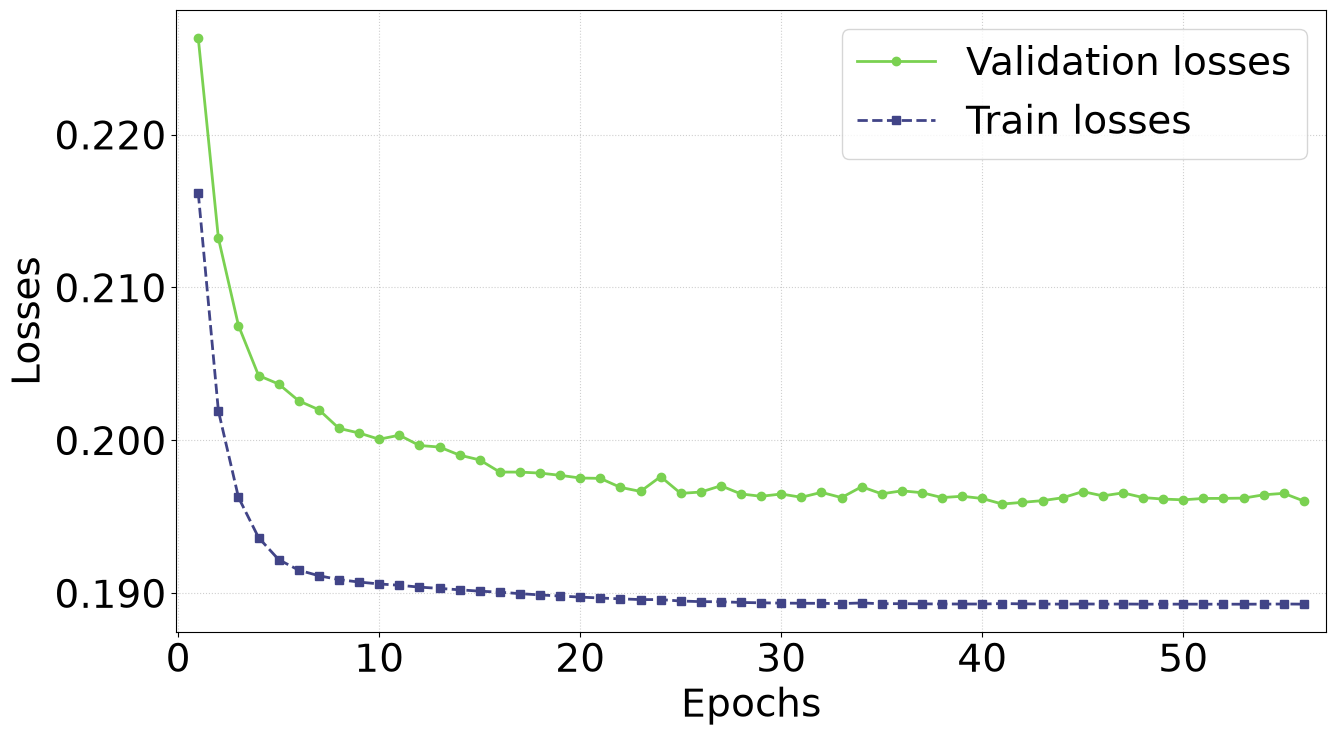

L=4:  val loss 0.1958 |  train loss 0.1893 | avg loss 0.2115  +- 0.0048  | accuracy = 0.734 | auc 0.744 | epochs 56


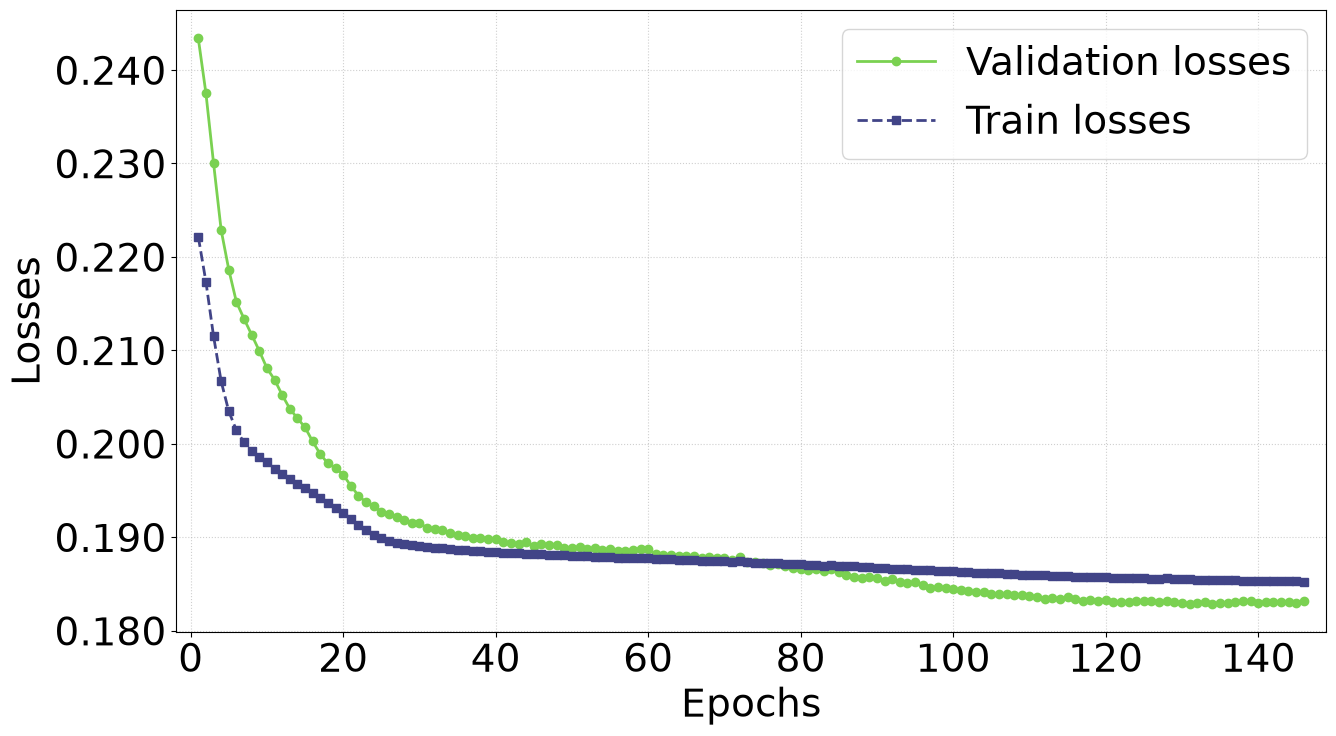

L=5:  val loss 0.1828 |  train loss 0.1855 | avg loss 0.2066  +- 0.0081  | accuracy = 0.722 | auc 0.753 | epochs 146


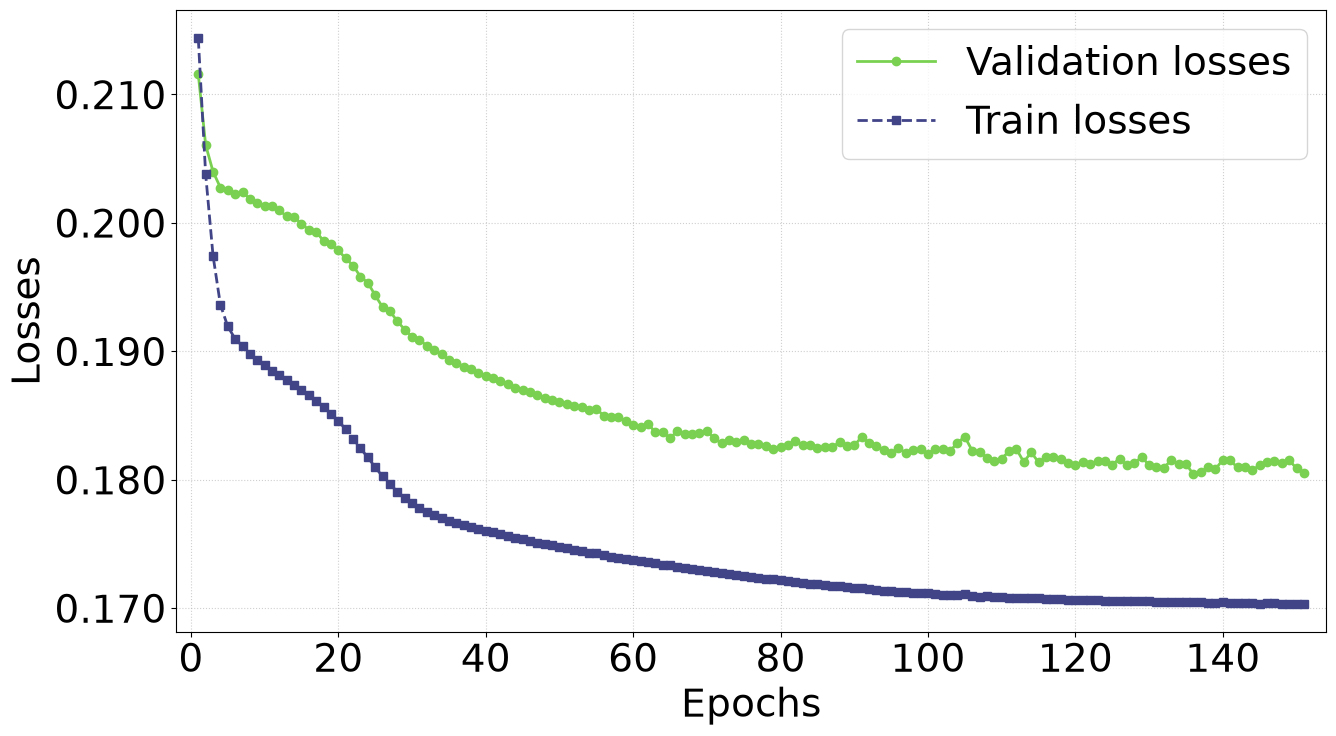

L=6:  val loss 0.1804 |  train loss 0.1705 | avg loss 0.2010  +- 0.0091  | accuracy = 0.718 | auc 0.802 | epochs 151


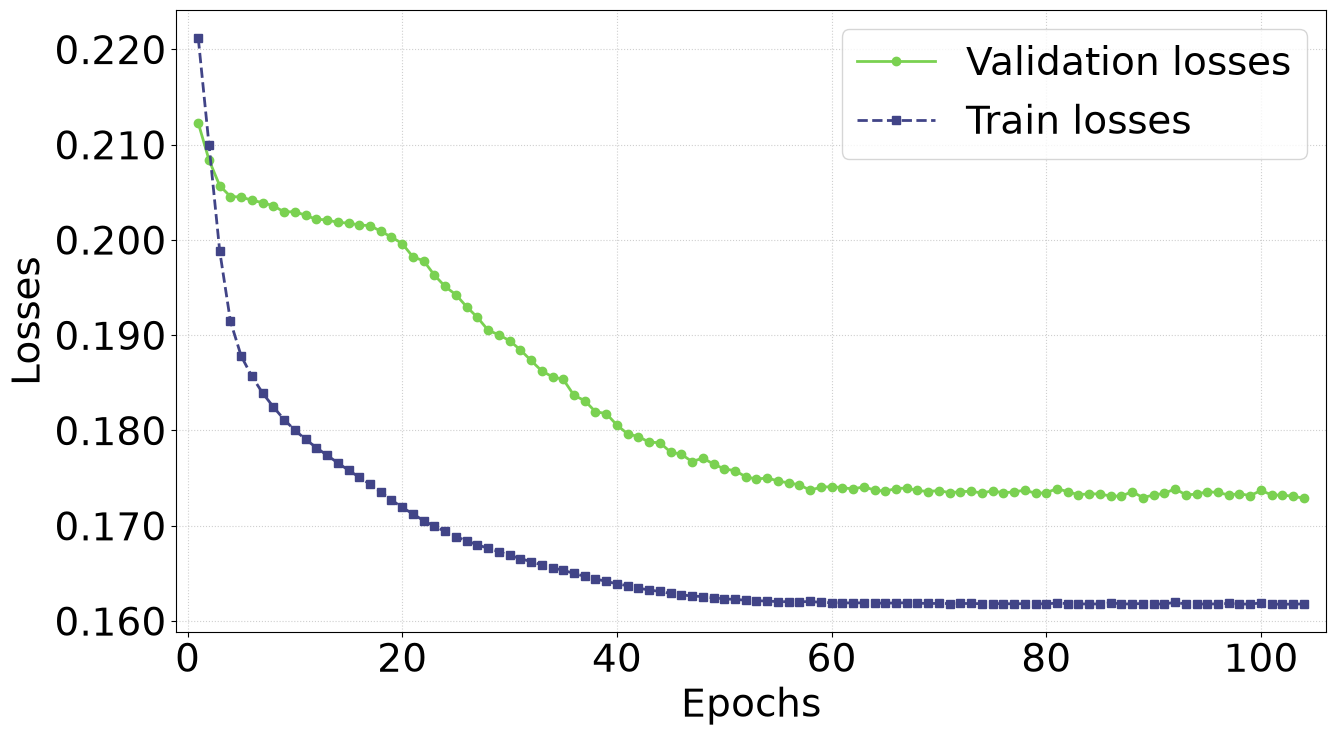

L=7:  val loss 0.1729 |  train loss 0.1618 | avg loss 0.1943  +- 0.0136  | accuracy = 0.746 | auc 0.827 | epochs 104


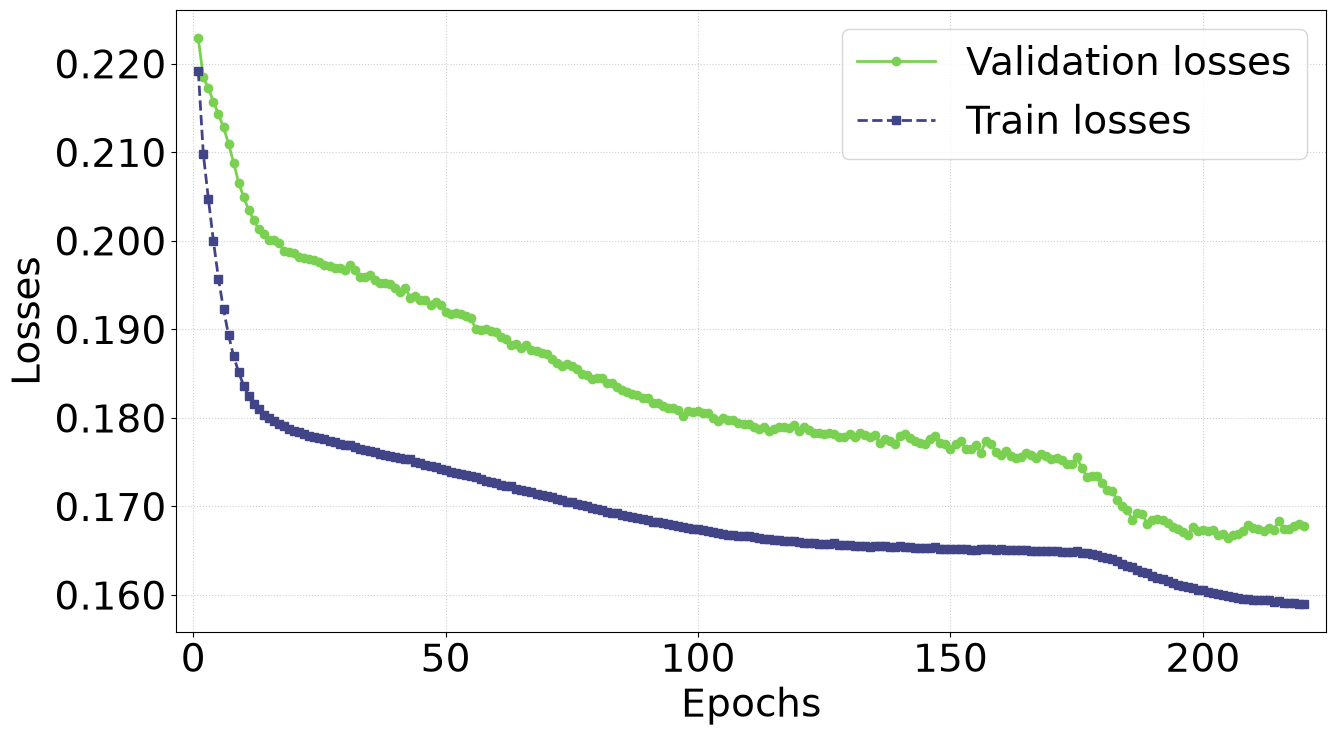

L=8:  val loss 0.1665 |  train loss 0.1599 | avg loss 0.1860  +- 0.0129  | accuracy = 0.754 | auc 0.834 | epochs 220


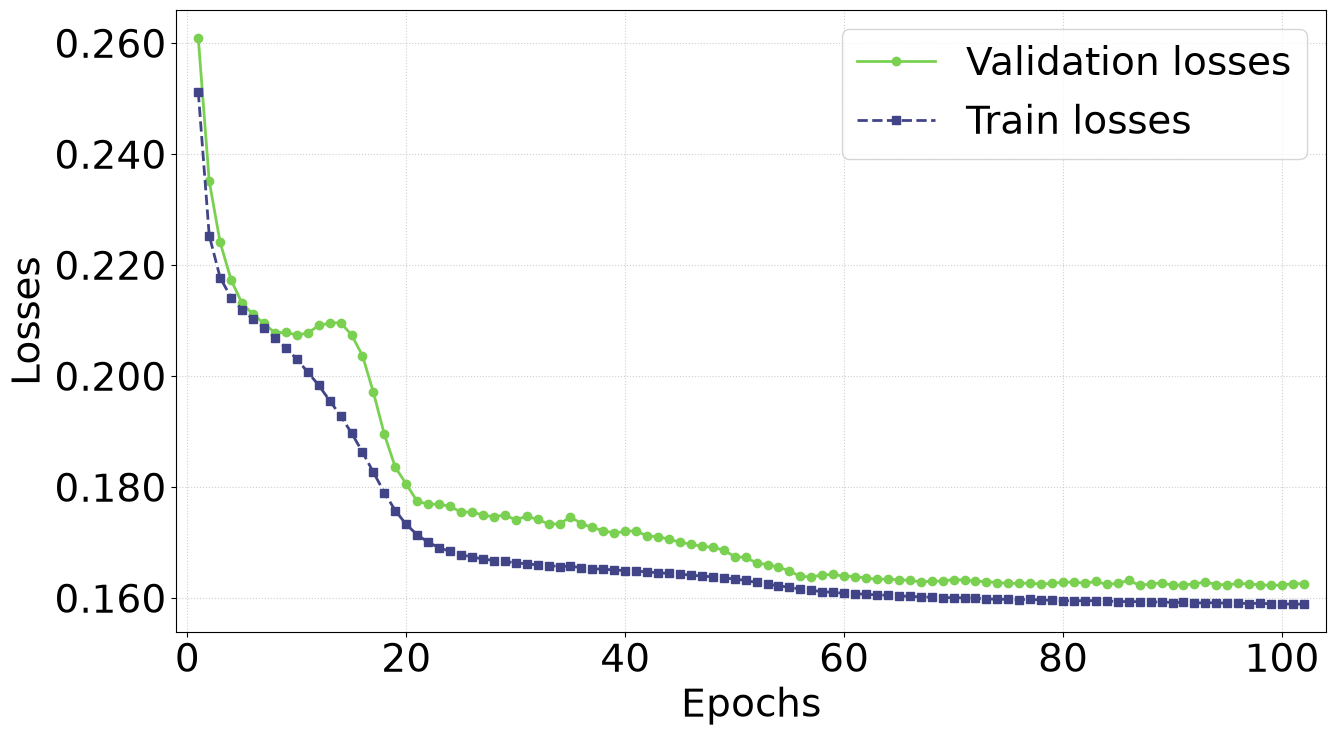

L=9:  val loss 0.1623 |  train loss 0.1593 | avg loss 0.1854  +- 0.0187  | accuracy = 0.743 | auc 0.822 | epochs 102


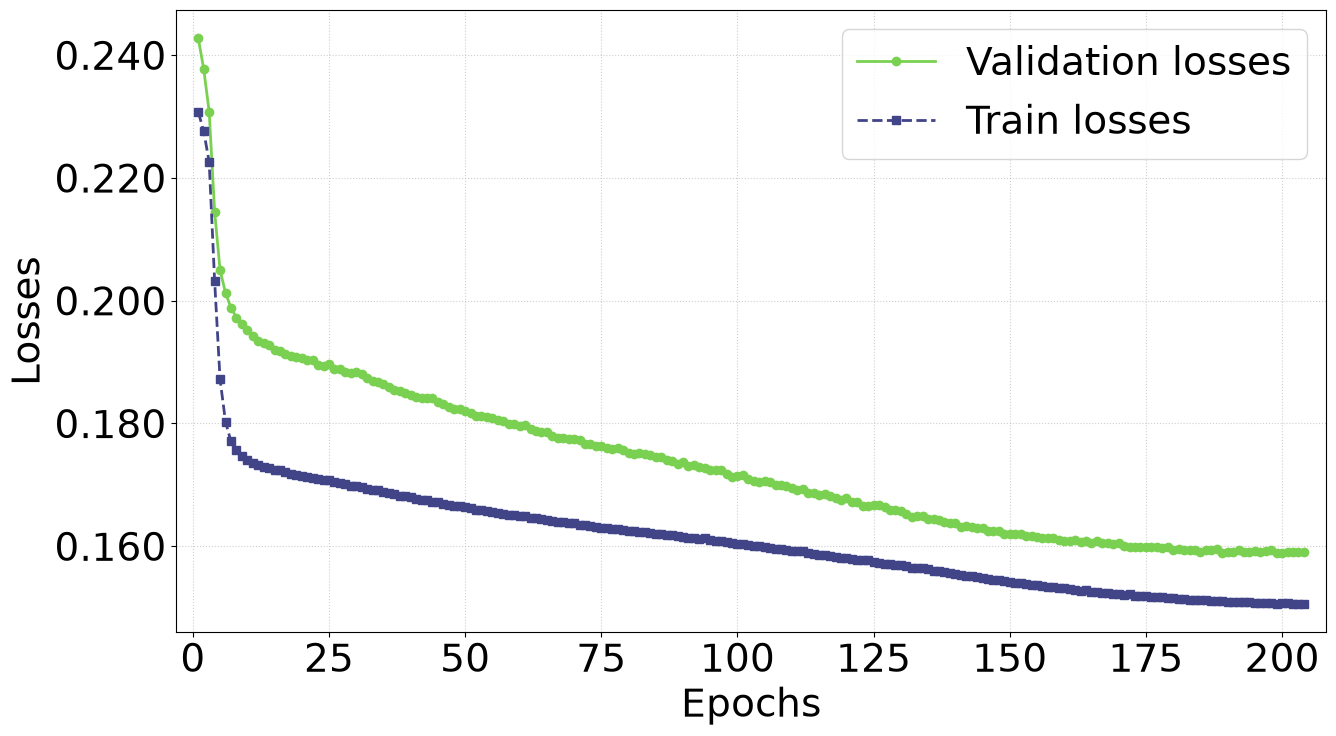

L=10:  val loss 0.1588 |  train loss 0.1511 | avg loss 0.1862  +- 0.0228  | accuracy = 0.778 | auc 0.848 | epochs 204
model angle-twolocal-2


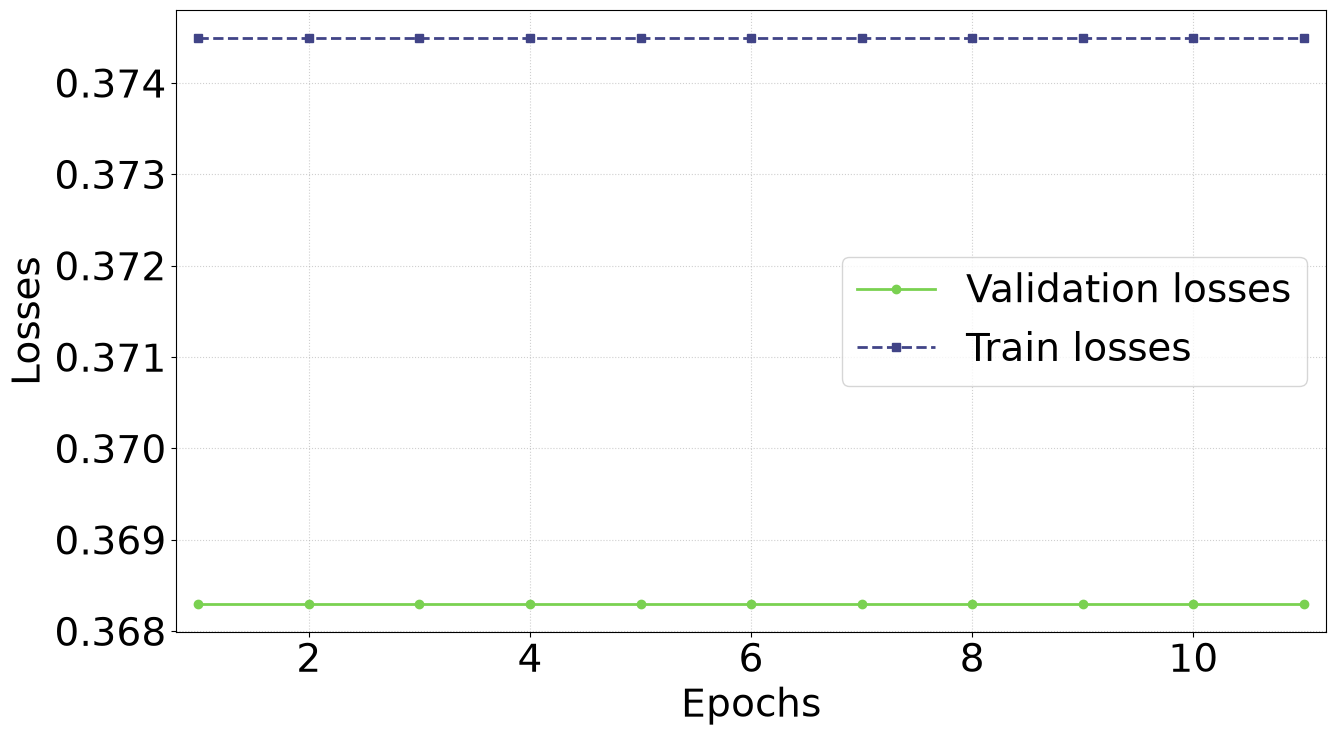

L=1:  val loss 0.3683 |  train loss 0.3745 | avg loss 0.3683  +- 0.0000  | accuracy = 0.470 | auc 0.754 | epochs 11


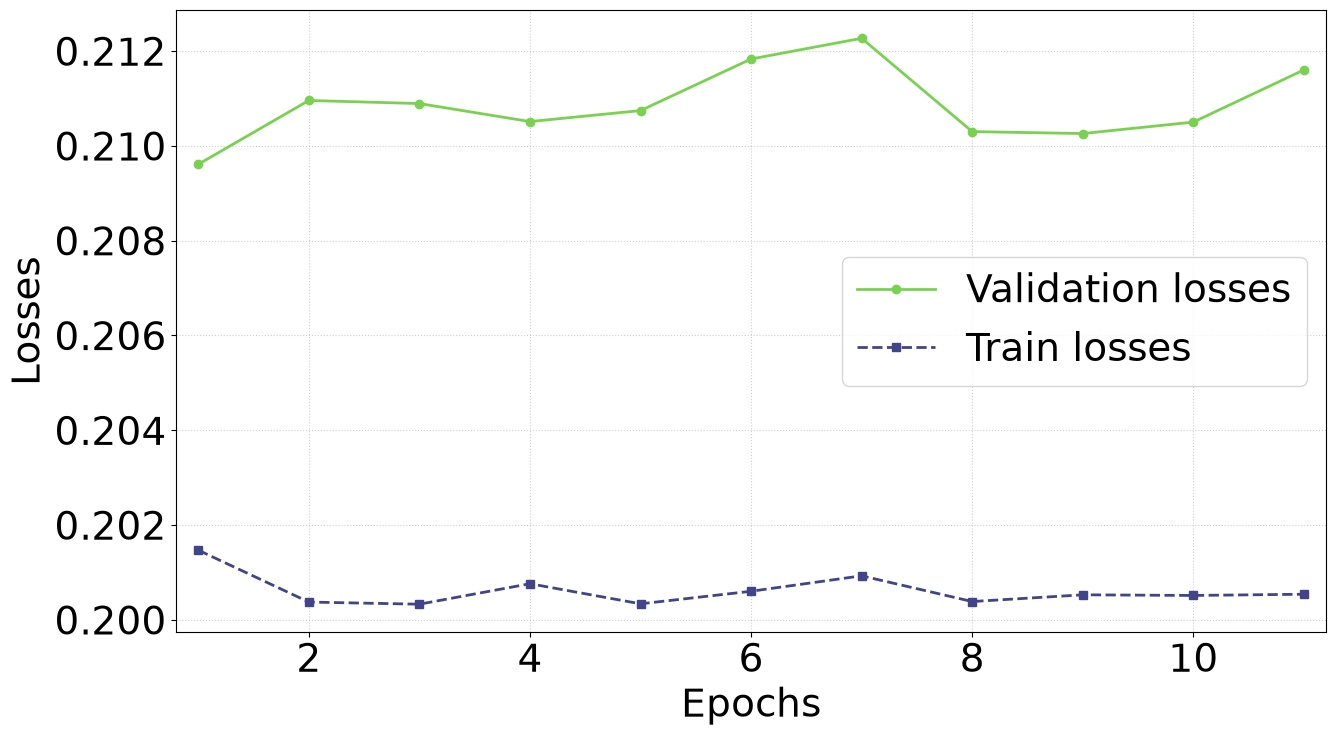

L=2:  val loss 0.2096 |  train loss 0.2015 | avg loss 0.2102  +- 0.0002  | accuracy = 0.735 | auc 0.785 | epochs 11


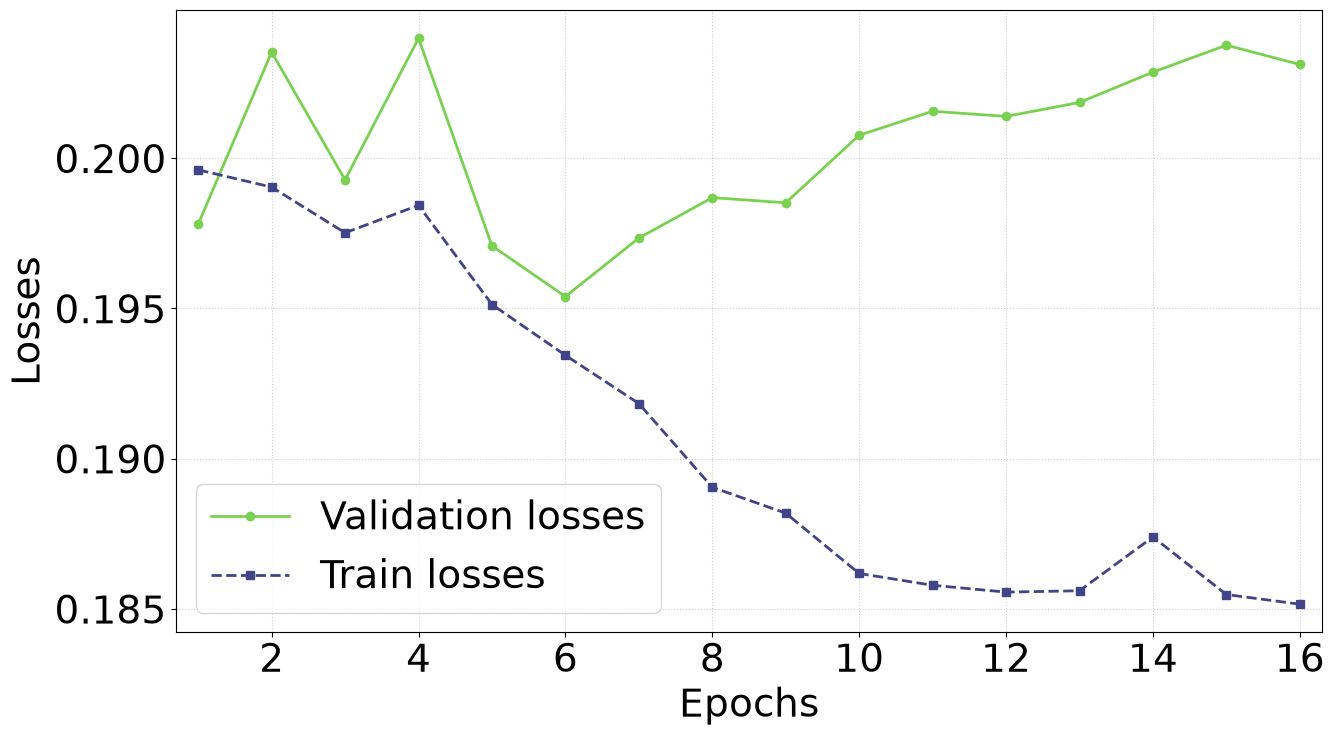

L=3:  val loss 0.1954 |  train loss 0.1934 | avg loss 0.2022  +- 0.0031  | accuracy = 0.708 | auc 0.739 | epochs 16


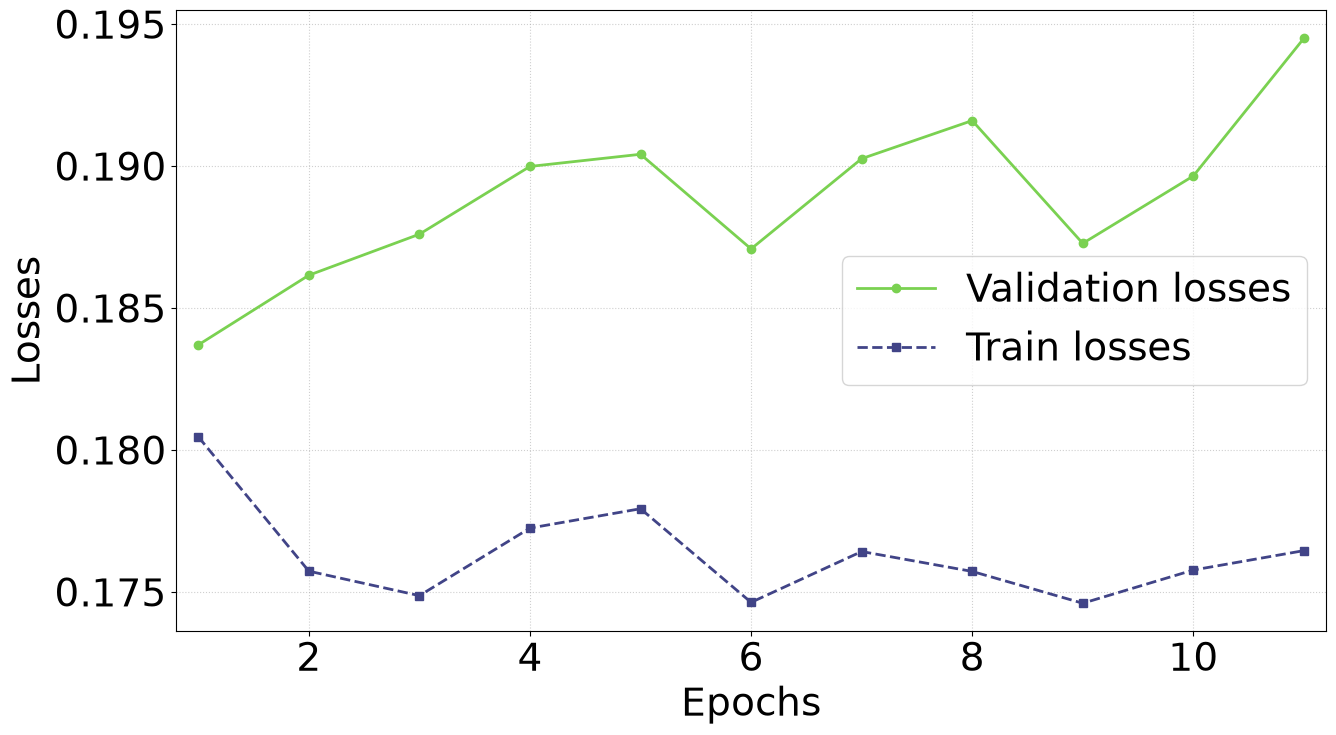

L=4:  val loss 0.1837 |  train loss 0.1805 | avg loss 0.1897  +- 0.0034  | accuracy = 0.725 | auc 0.793 | epochs 11


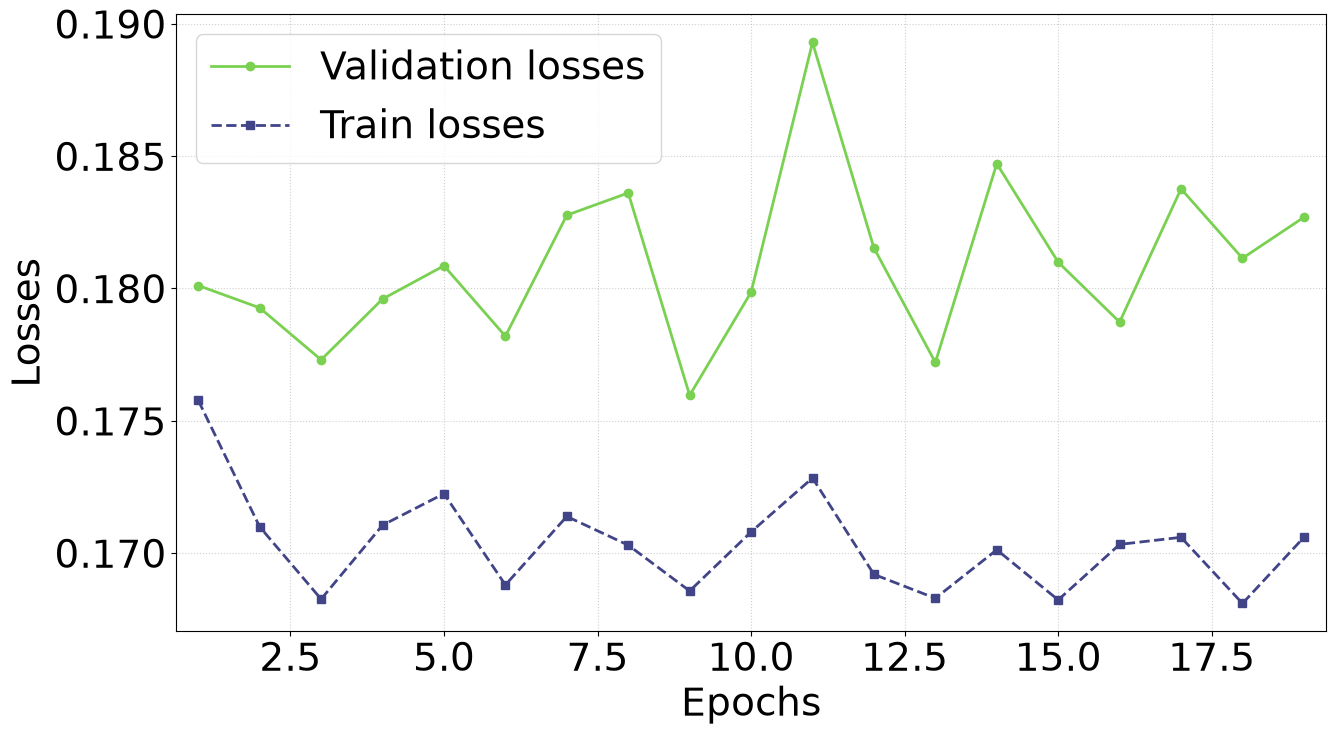

L=5:  val loss 0.1760 |  train loss 0.1686 | avg loss 0.1815  +- 0.0061  | accuracy = 0.735 | auc 0.813 | epochs 19


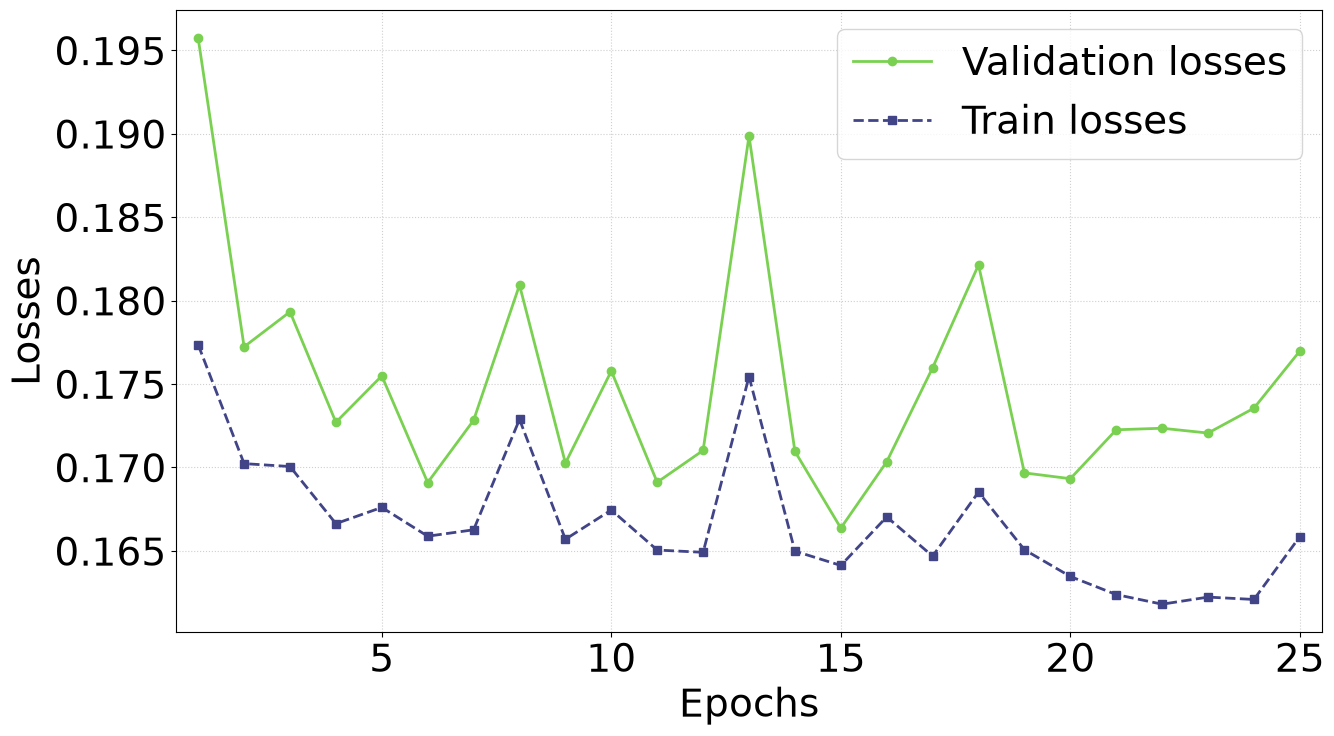

L=6:  val loss 0.1664 |  train loss 0.1641 | avg loss 0.1760  +- 0.0104  | accuracy = 0.732 | auc 0.815 | epochs 25


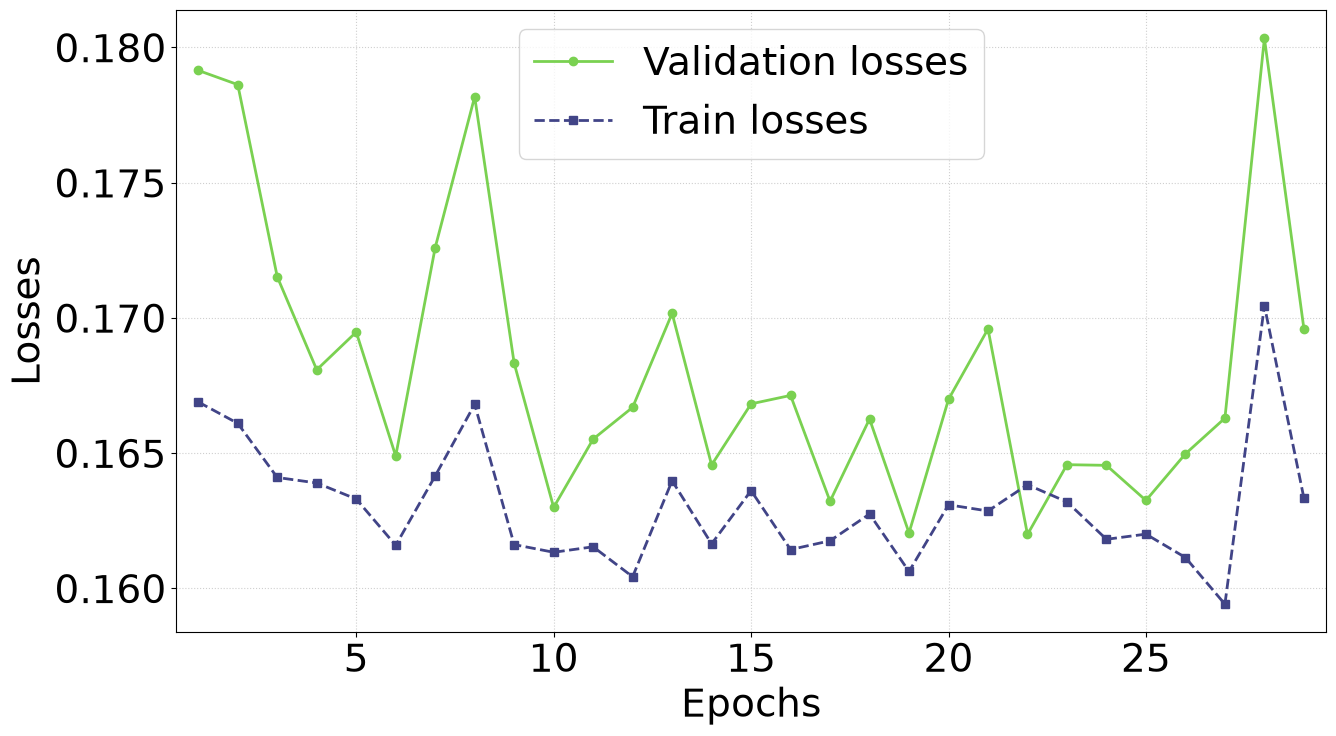

L=7:  val loss 0.1621 |  train loss 0.1606 | avg loss 0.1717  +- 0.0098  | accuracy = 0.743 | auc 0.819 | epochs 29


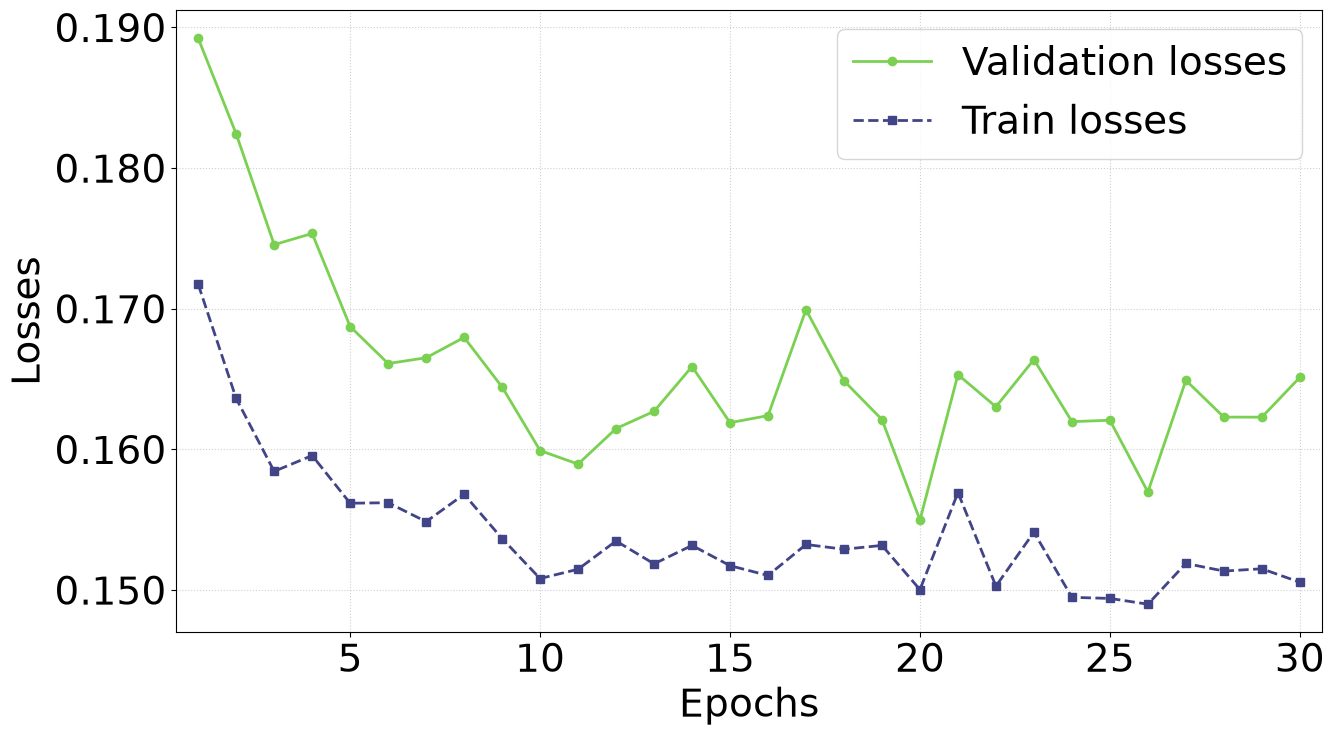

L=8:  val loss 0.1550 |  train loss 0.1500 | avg loss 0.1624  +- 0.0091  | accuracy = 0.782 | auc 0.852 | epochs 30


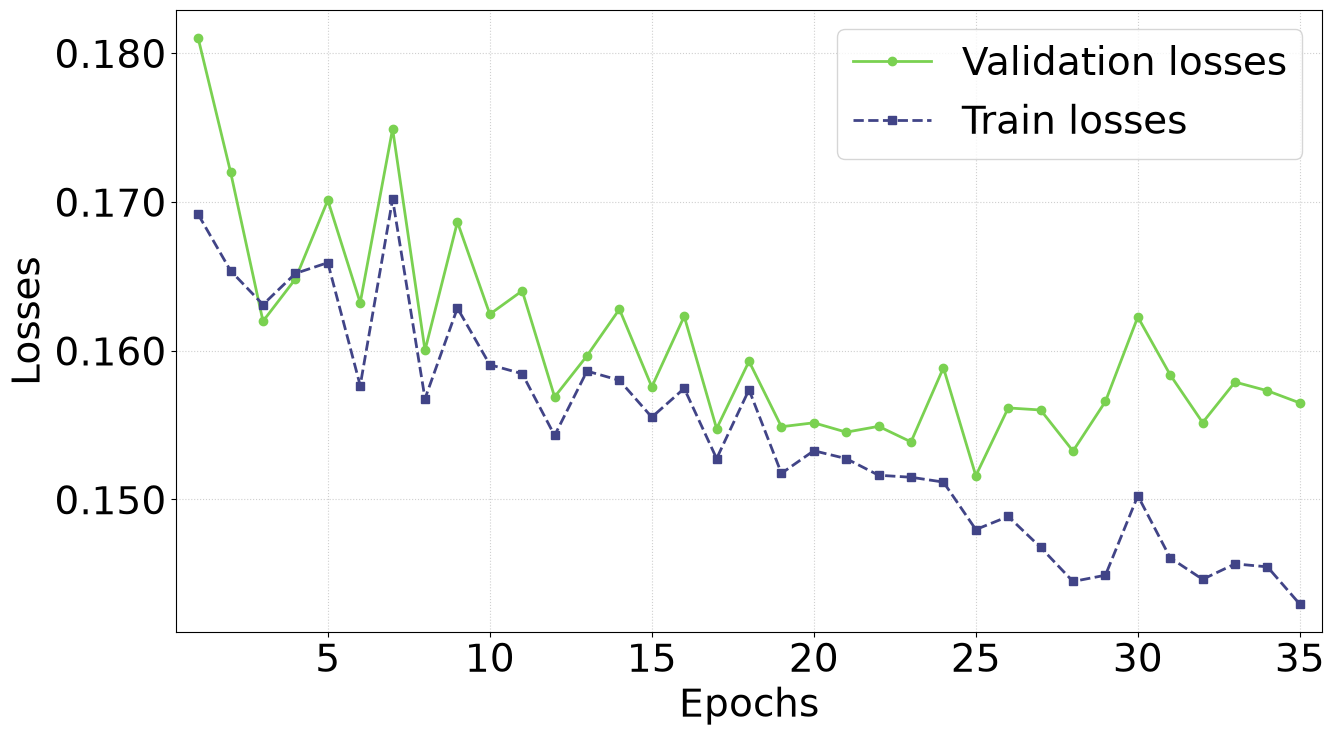

L=9:  val loss 0.1516 |  train loss 0.1480 | avg loss 0.1579  +- 0.0117  | accuracy = 0.789 | auc 0.848 | epochs 35


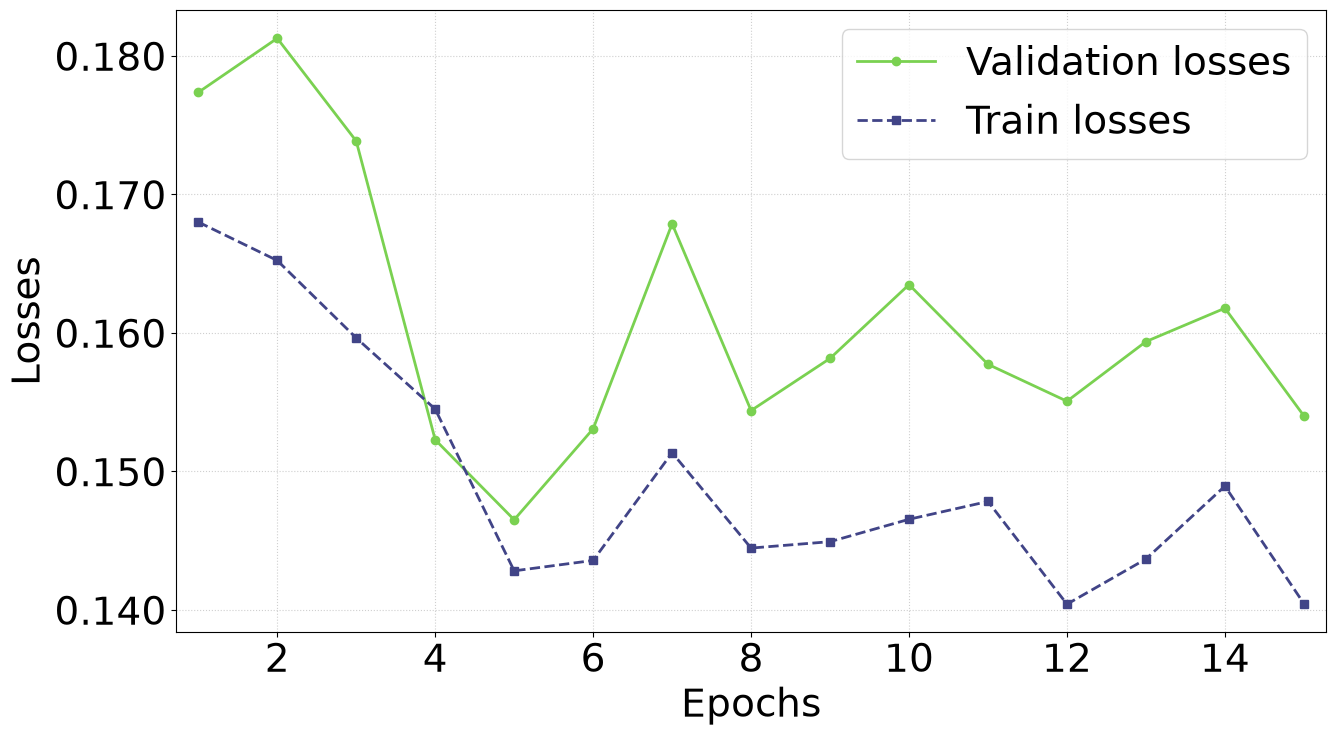

L=10:  val loss 0.1465 |  train loss 0.1428 | avg loss 0.1538  +- 0.0105  | accuracy = 0.800 | auc 0.851 | epochs 15
model angle-treetensor


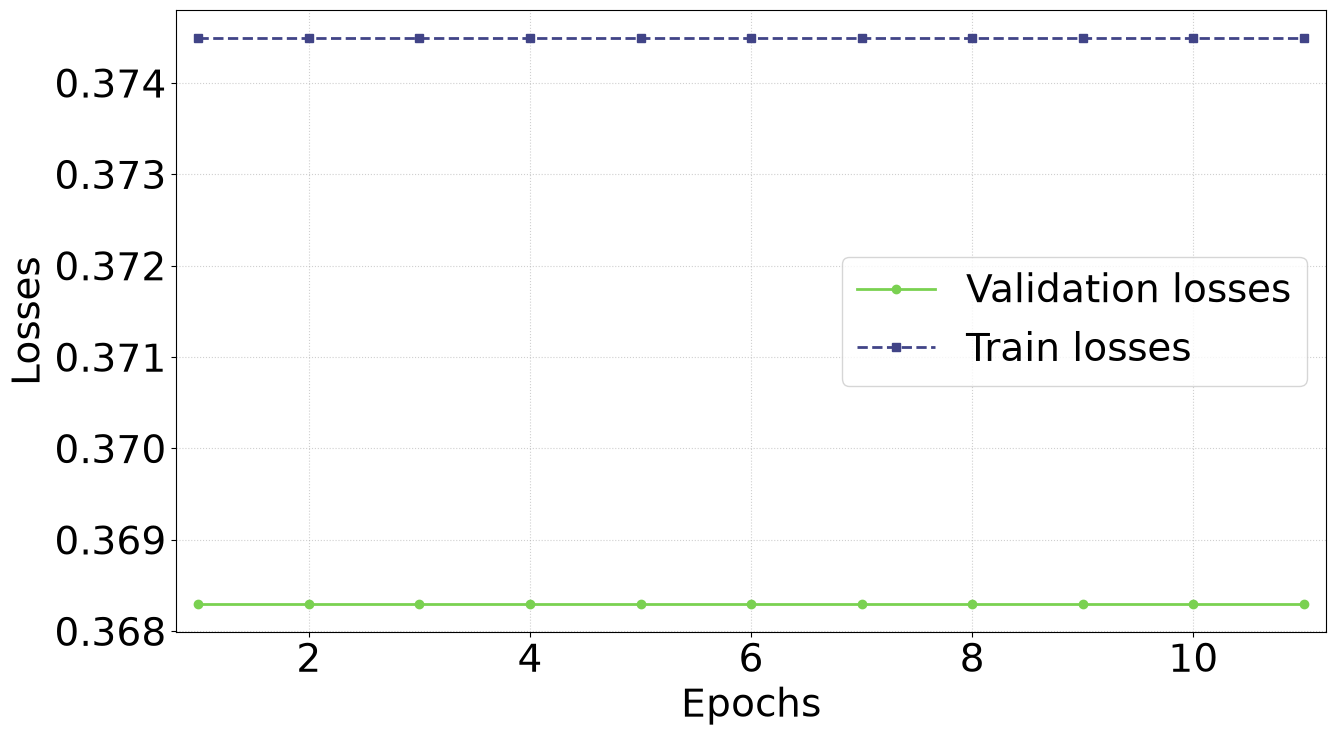

L=1:  val loss 0.3683 |  train loss 0.3745 | avg loss 0.3683  +- 0.0000  | accuracy = 0.470 | auc 0.754 | epochs 11


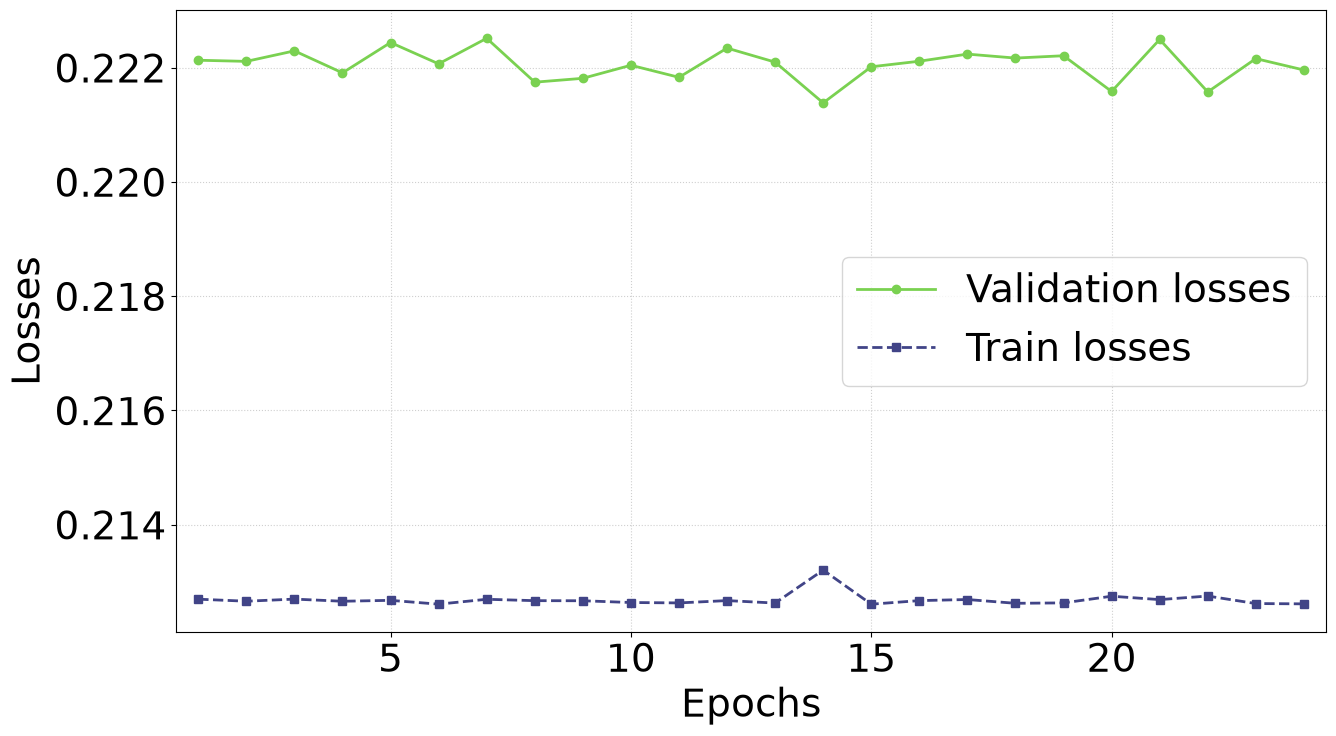

L=2:  val loss 0.2214 |  train loss 0.2132 | avg loss 0.2217  +- 0.0001  | accuracy = 0.746 | auc 0.742 | epochs 24


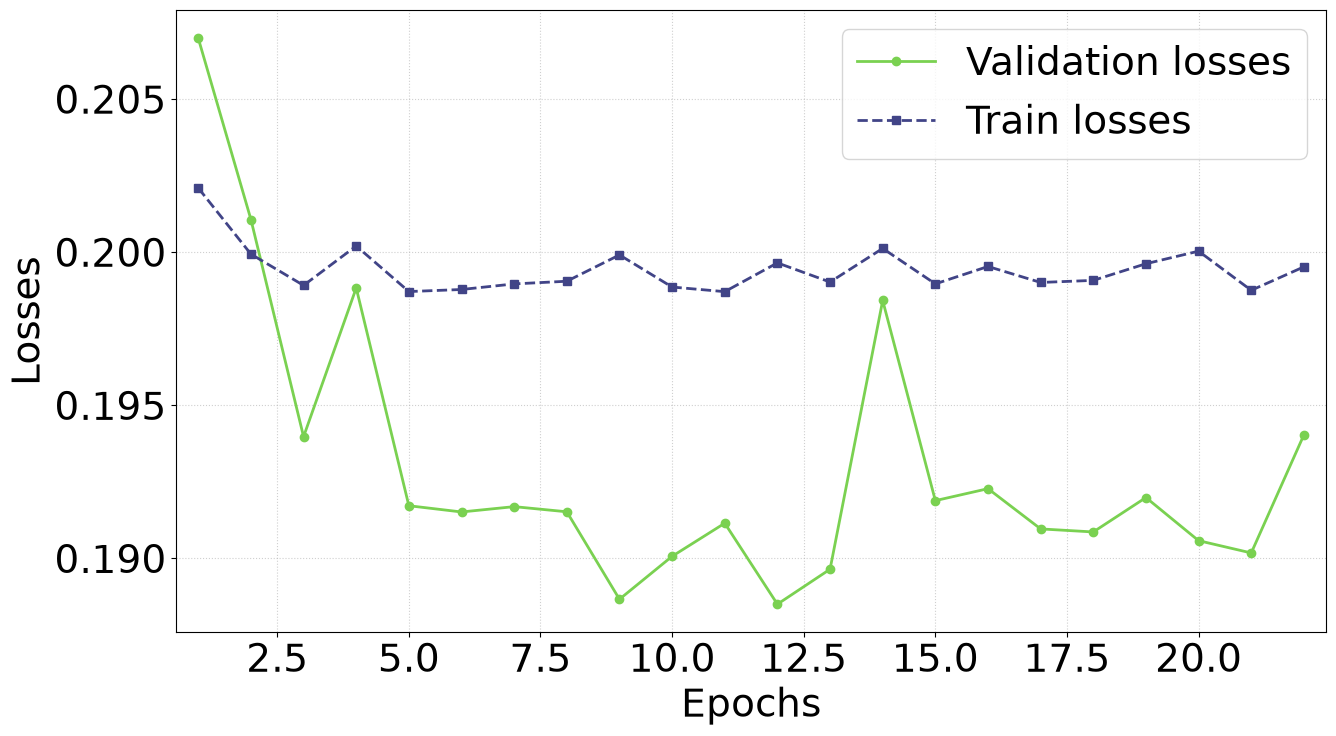

L=3:  val loss 0.1885 |  train loss 0.1996 | avg loss 0.1989  +- 0.0127  | accuracy = 0.733 | auc 0.747 | epochs 22


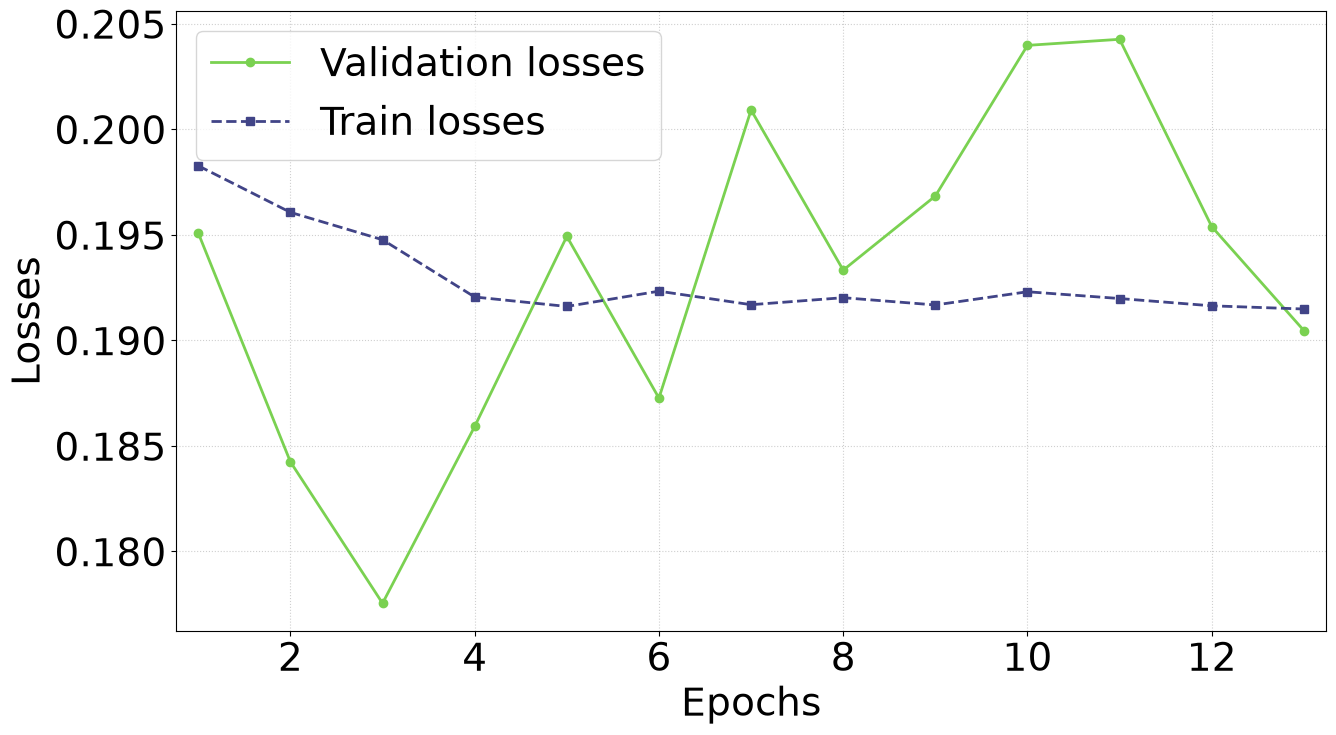

L=4:  val loss 0.1775 |  train loss 0.1948 | avg loss 0.1953  +- 0.0060  | accuracy = 0.760 | auc 0.795 | epochs 13


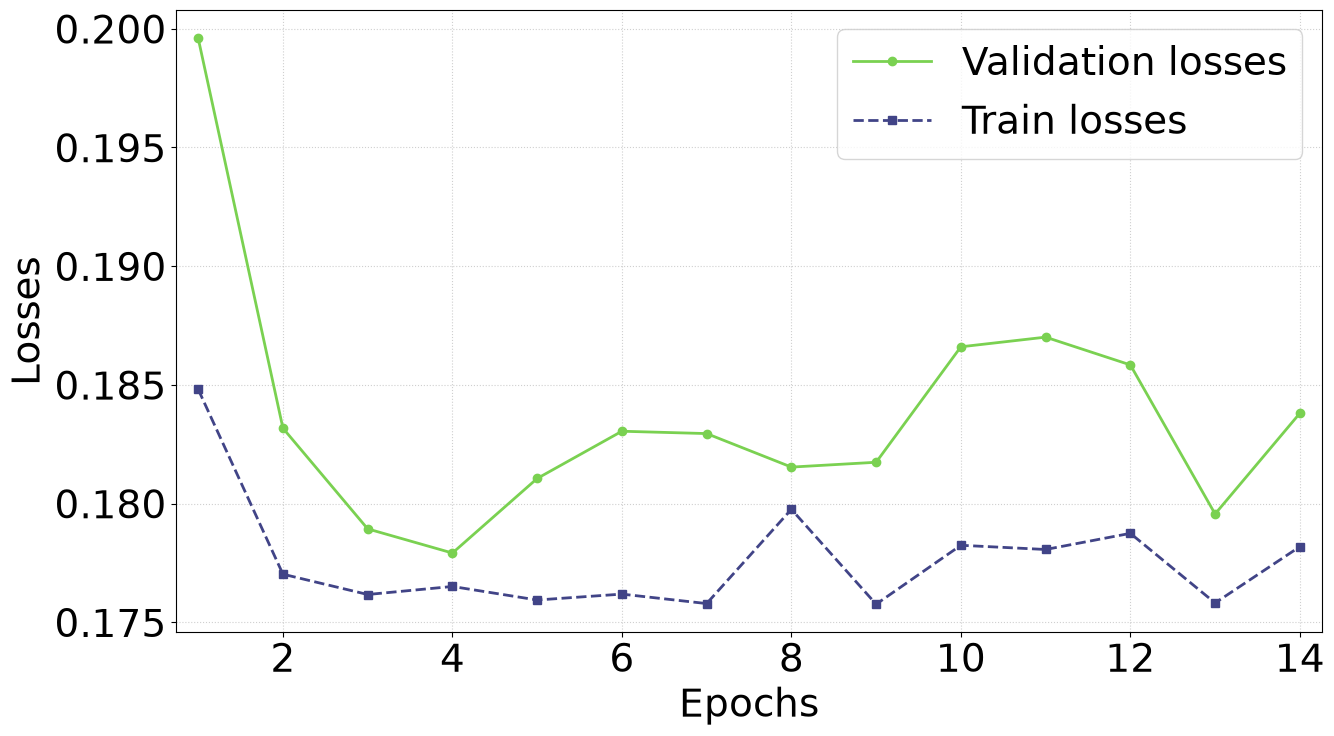

L=5:  val loss 0.1779 |  train loss 0.1765 | avg loss 0.1883  +- 0.0060  | accuracy = 0.773 | auc 0.816 | epochs 14


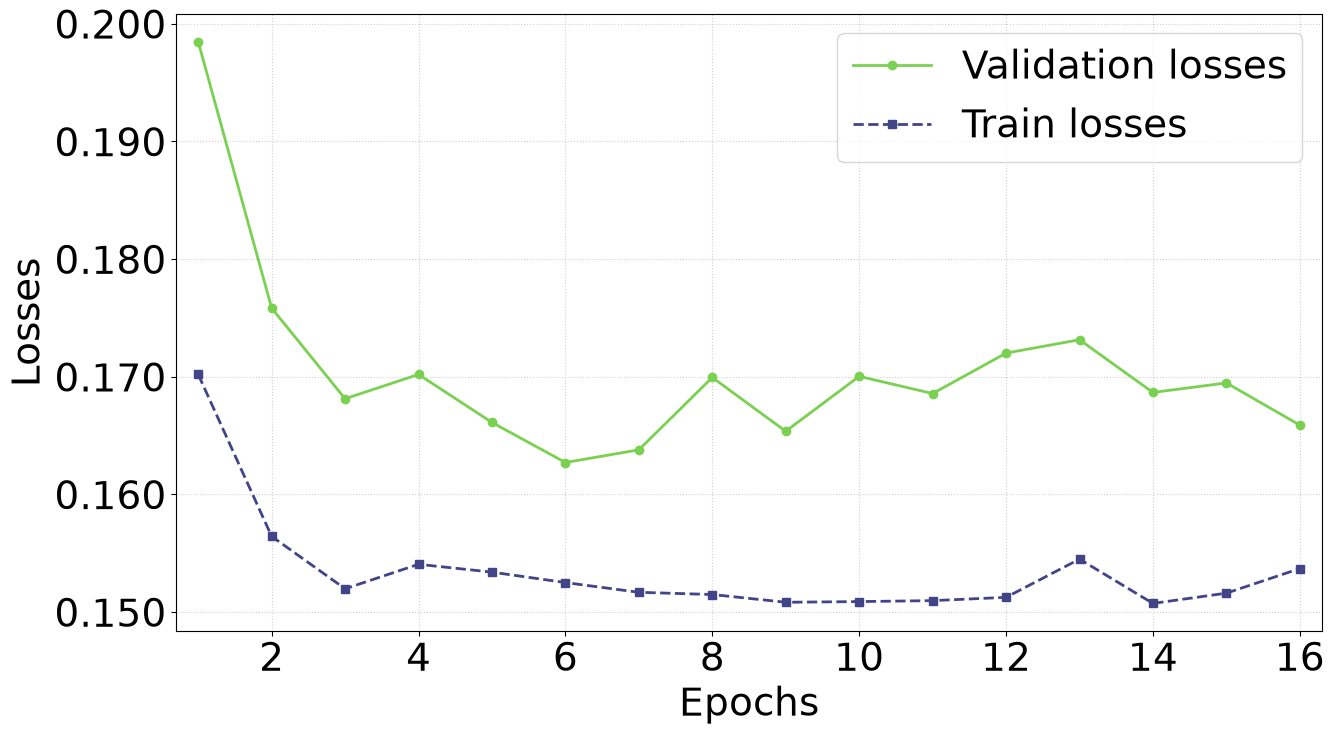

L=6:  val loss 0.1627 |  train loss 0.1525 | avg loss 0.1793  +- 0.0083  | accuracy = 0.797 | auc 0.860 | epochs 16


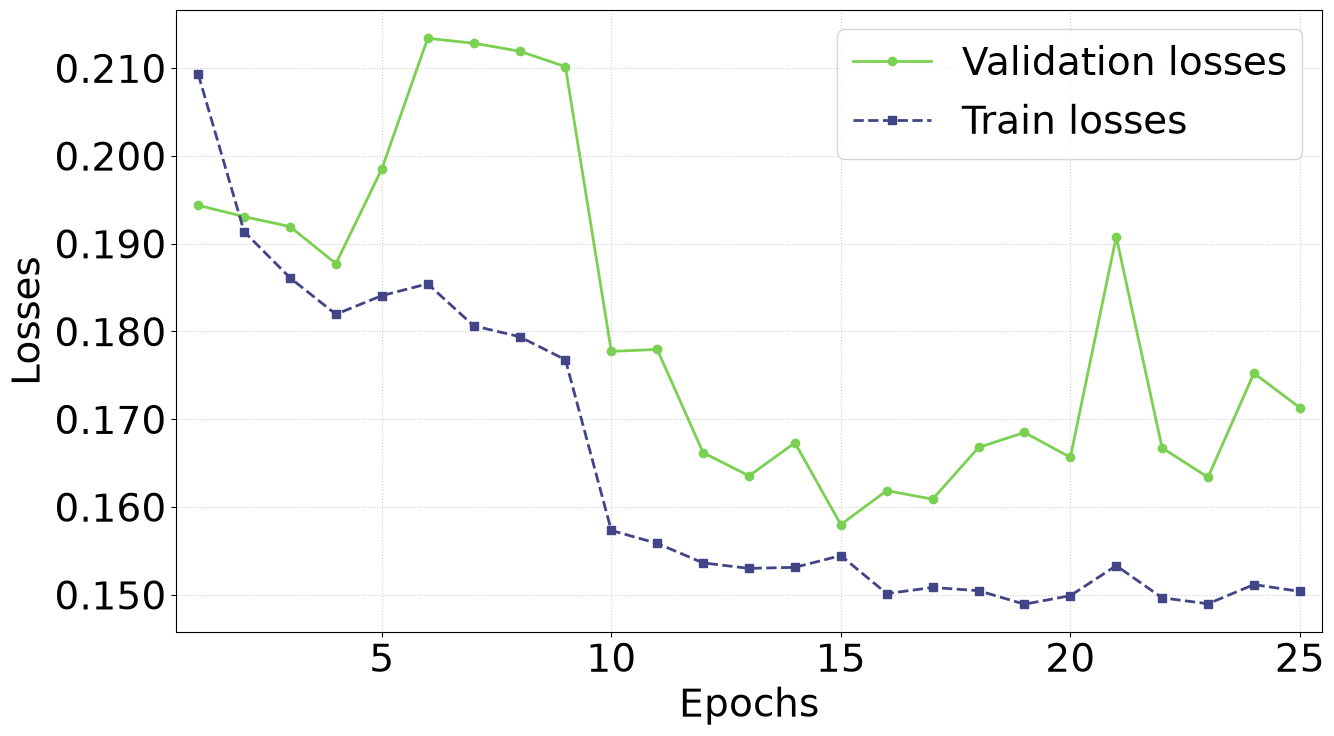

L=7:  val loss 0.1580 |  train loss 0.1545 | avg loss 0.1746  +- 0.0106  | accuracy = 0.814 | auc 0.864 | epochs 25


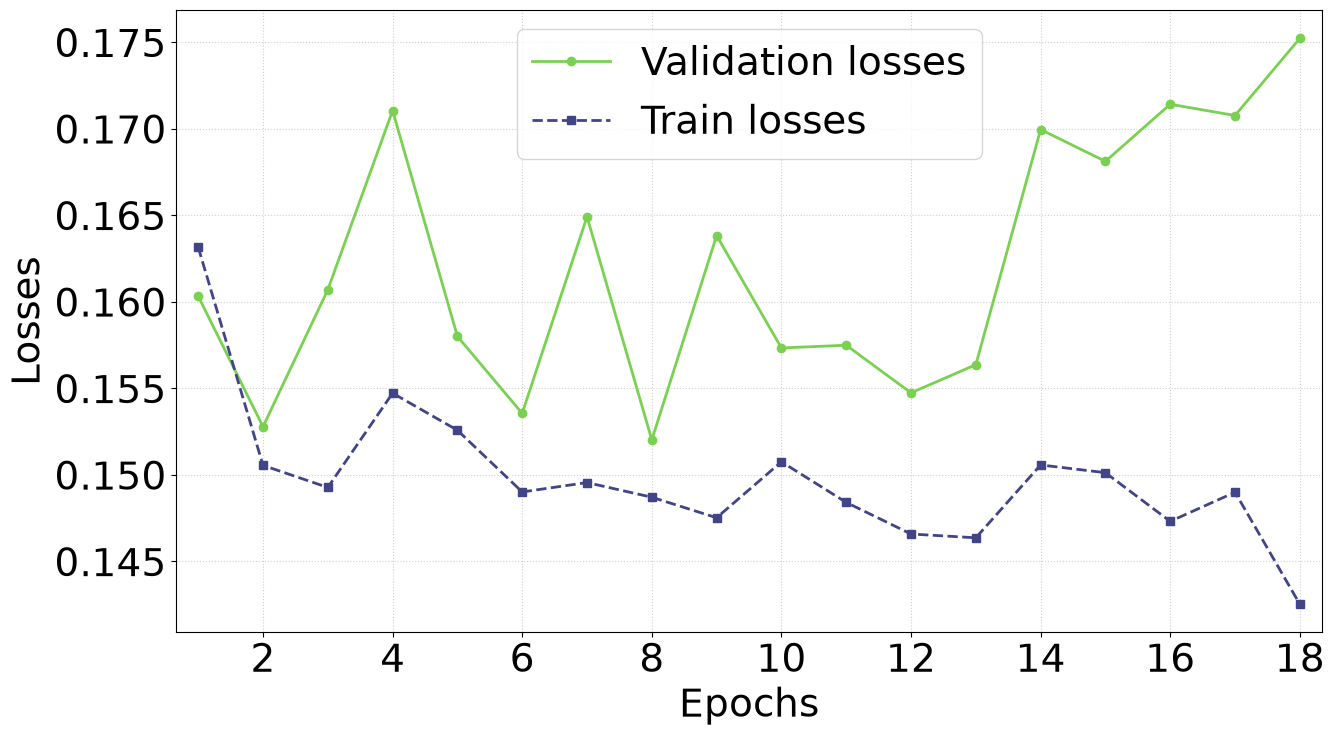

L=8:  val loss 0.1520 |  train loss 0.1487 | avg loss 0.1681  +- 0.0107  | accuracy = 0.794 | auc 0.852 | epochs 18


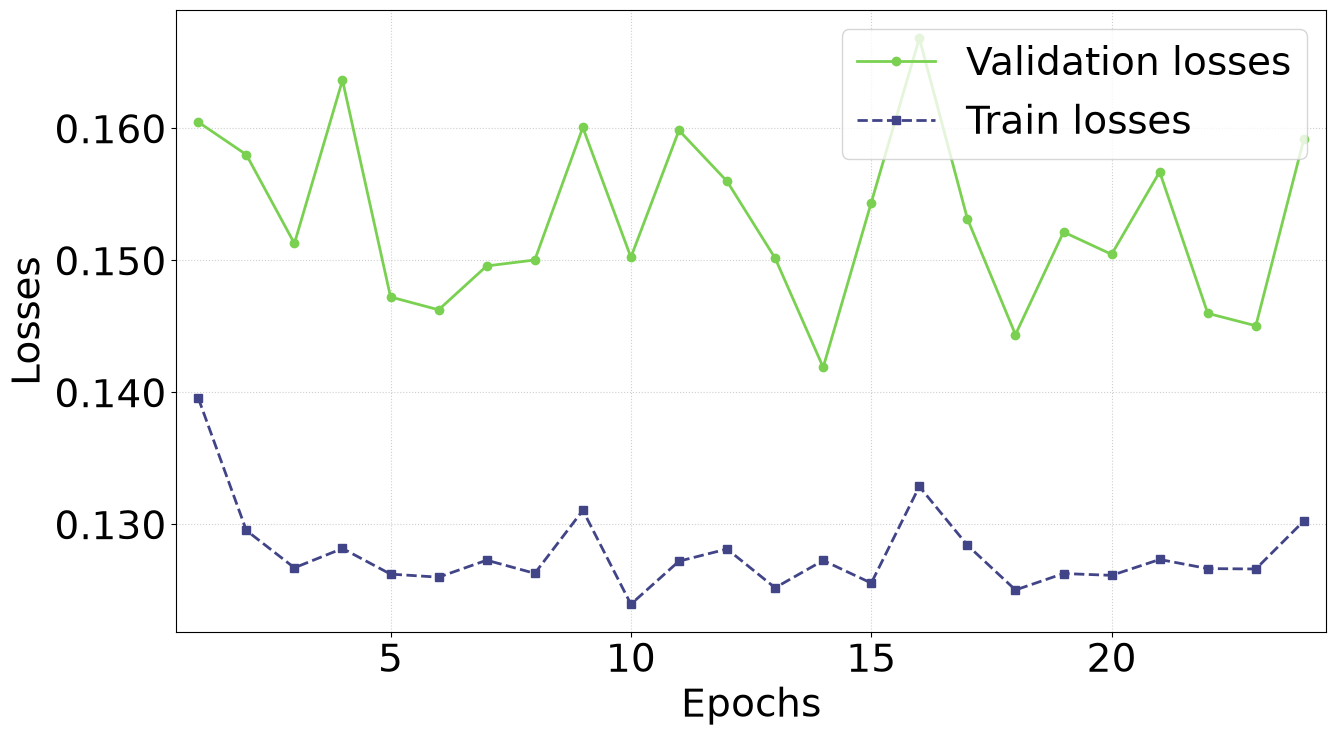

L=9:  val loss 0.1419 |  train loss 0.1273 | avg loss 0.1707  +- 0.0189  | accuracy = 0.823 | auc 0.893 | epochs 24


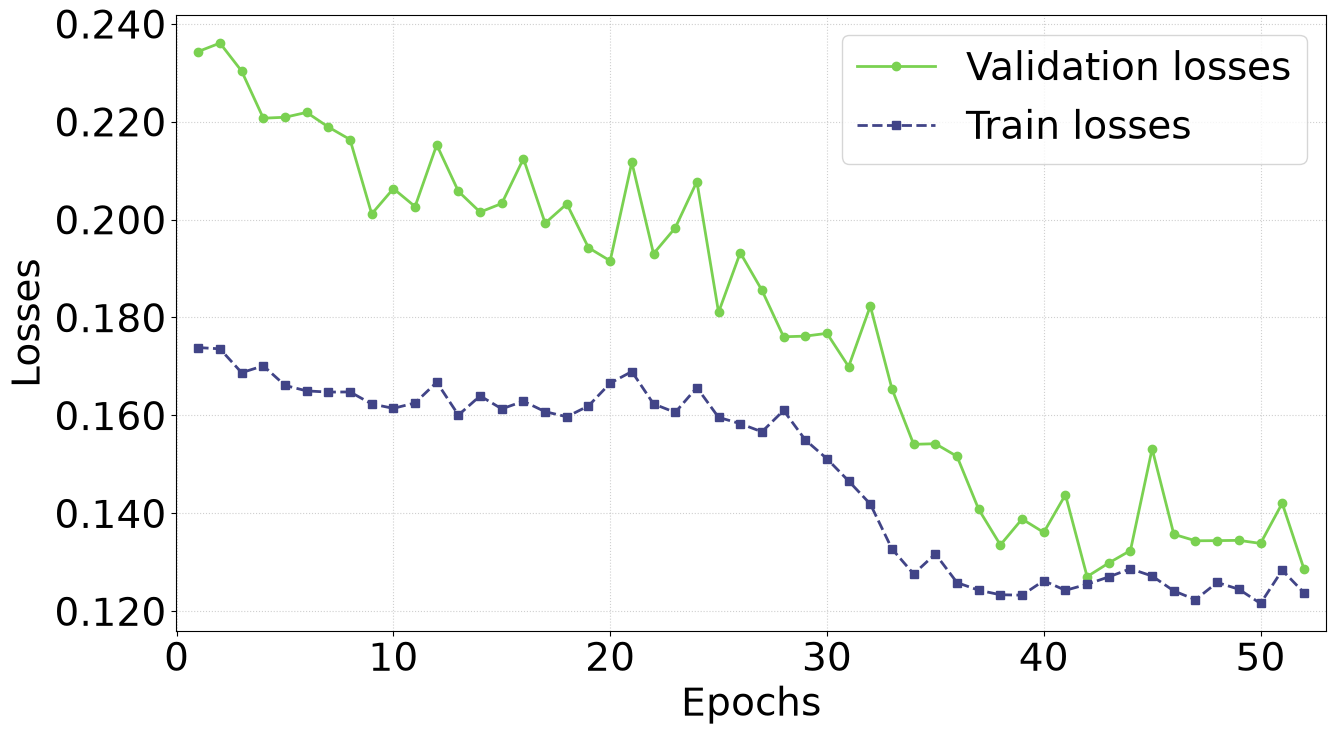

L=10:  val loss 0.1270 |  train loss 0.1255 | avg loss 0.1659  +- 0.0234  | accuracy = 0.820 | auc 0.890 | epochs 52


In [17]:
result = run_layers(models=models_overlap, dataset=dataset)

model angle-twolocal-1


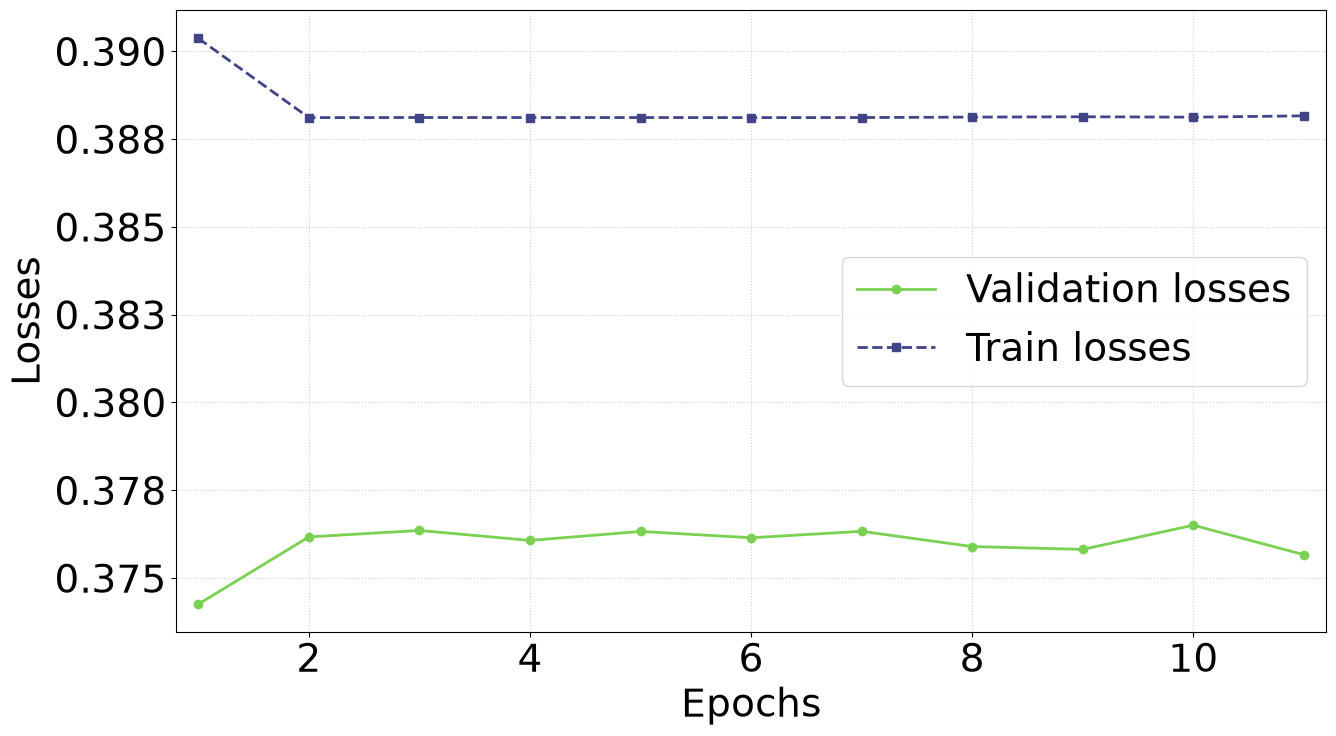

L=1:  val loss 0.3743 |  train loss 0.3904 | avg loss 0.3753  +- 0.0005  | accuracy = 0.603 | auc 0.728 | epochs 11


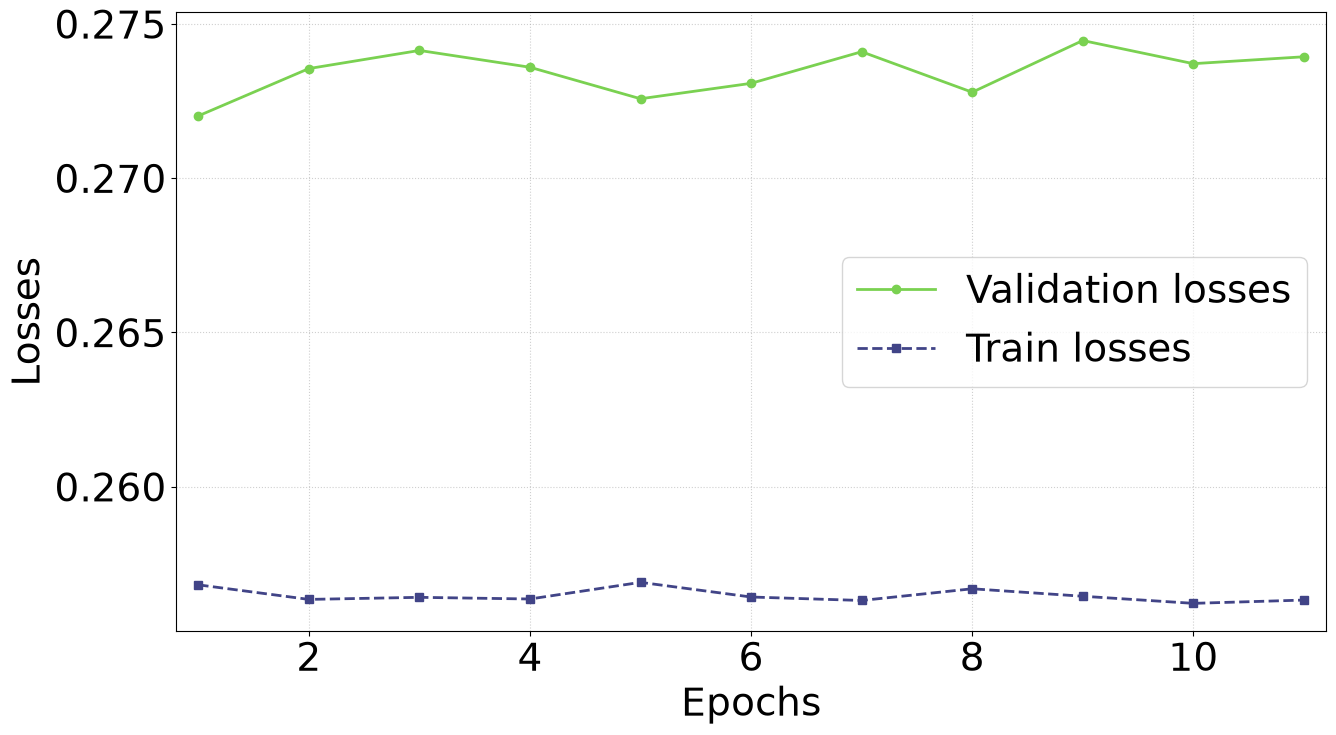

L=2:  val loss 0.2720 |  train loss 0.2568 | avg loss 0.2746  +- 0.0029  | accuracy = 0.694 | auc 0.843 | epochs 11


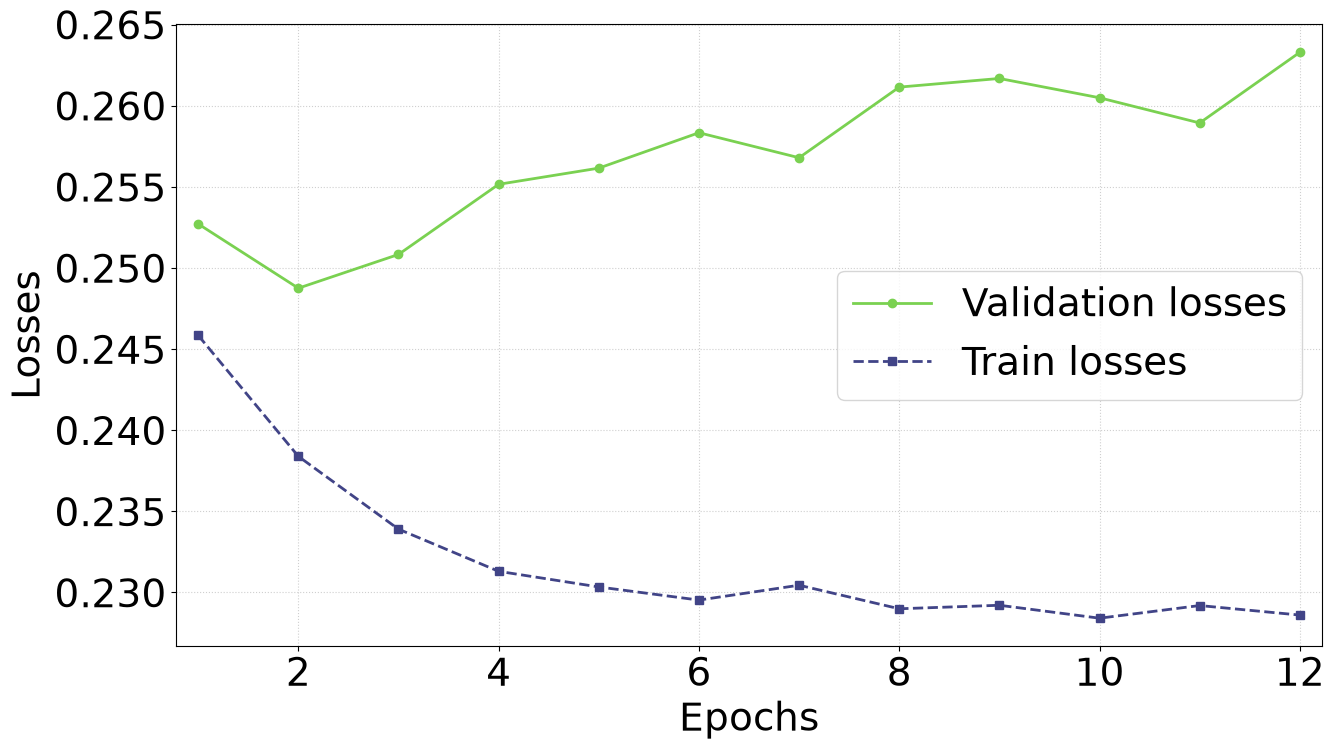

L=3:  val loss 0.2488 |  train loss 0.2384 | avg loss 0.2589  +- 0.0076  | accuracy = 0.684 | auc 0.827 | epochs 12


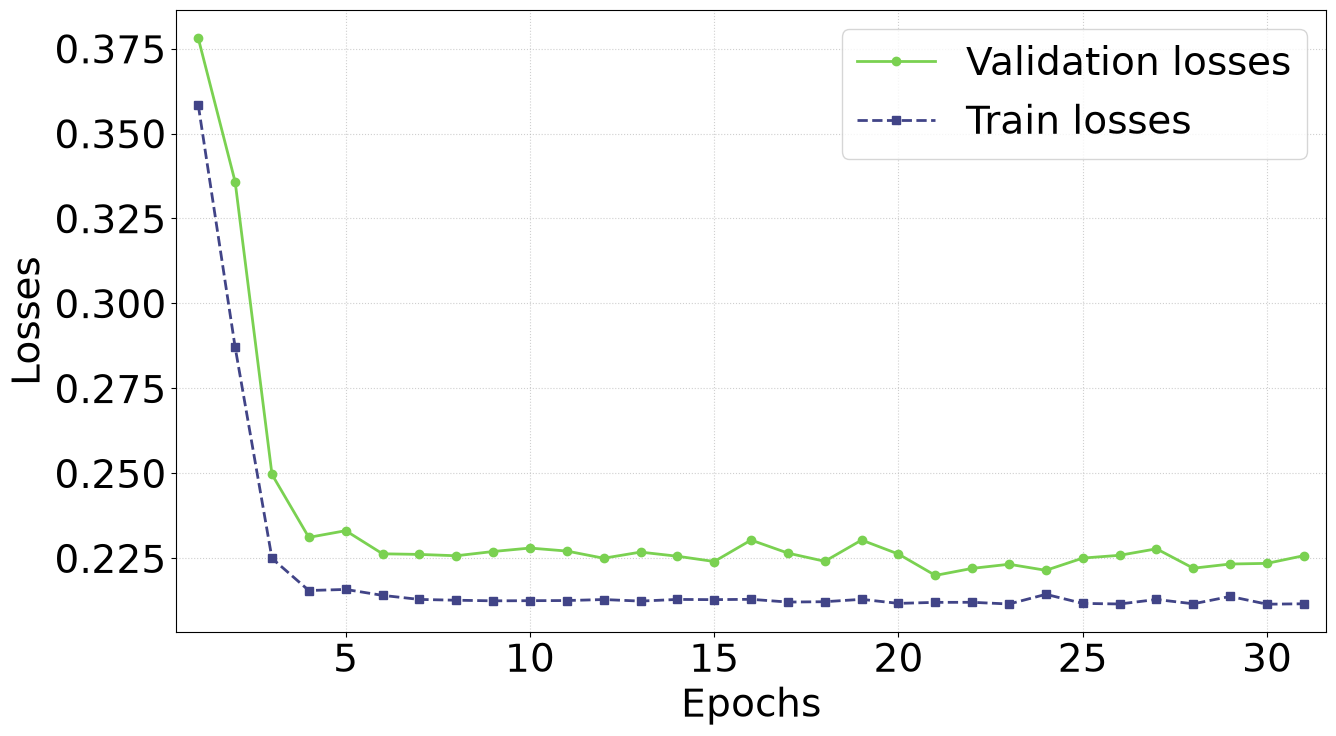

L=4:  val loss 0.2199 |  train loss 0.2120 | avg loss 0.2368  +- 0.0097  | accuracy = 0.731 | auc 0.882 | epochs 31


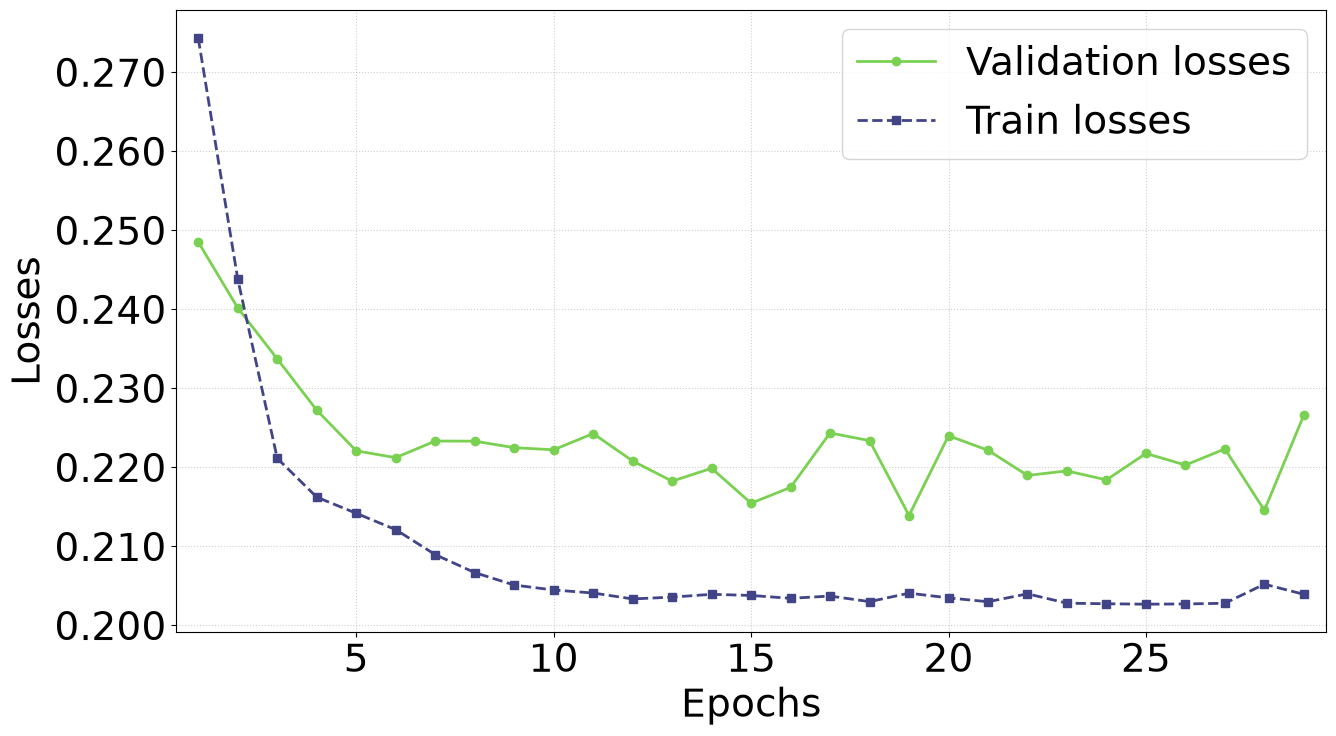

L=5:  val loss 0.2139 |  train loss 0.2041 | avg loss 0.2291  +- 0.0144  | accuracy = 0.729 | auc 0.903 | epochs 29


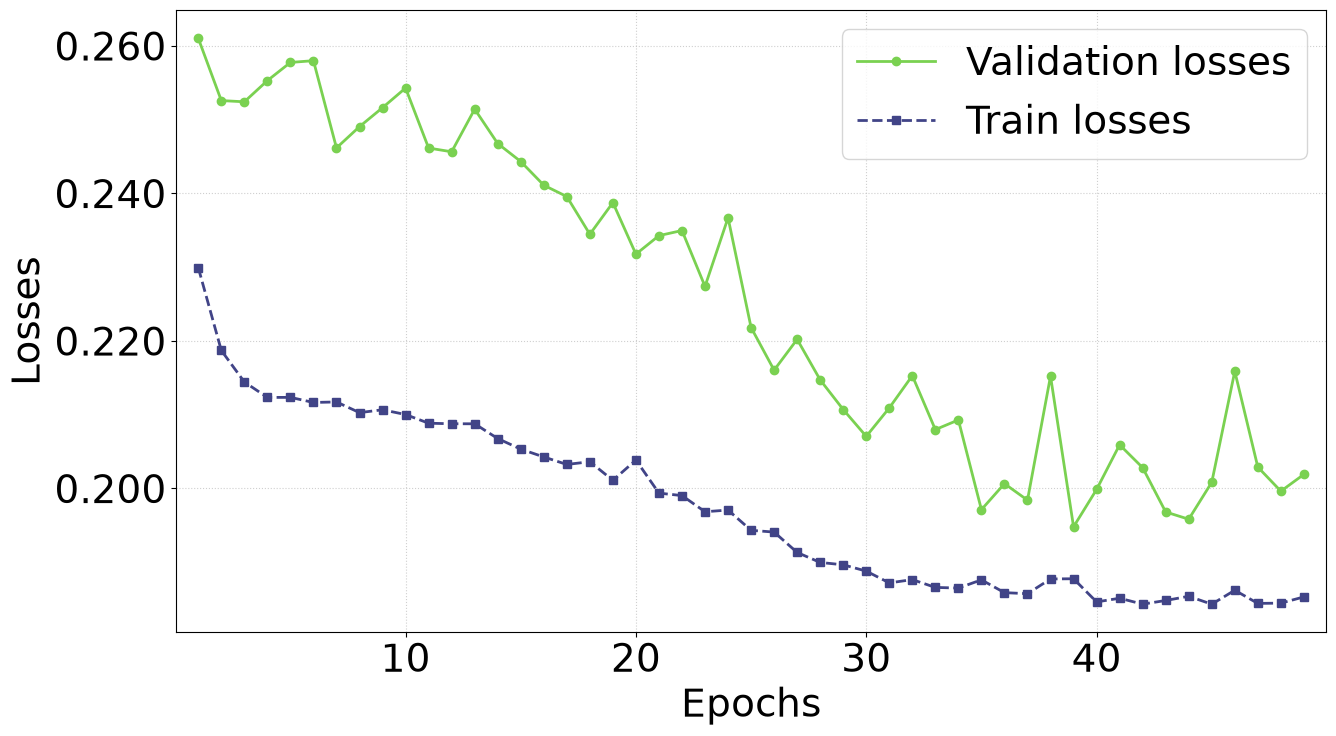

L=6:  val loss 0.1948 |  train loss 0.1877 | avg loss 0.2264  +- 0.0229  | accuracy = 0.731 | auc 0.935 | epochs 49


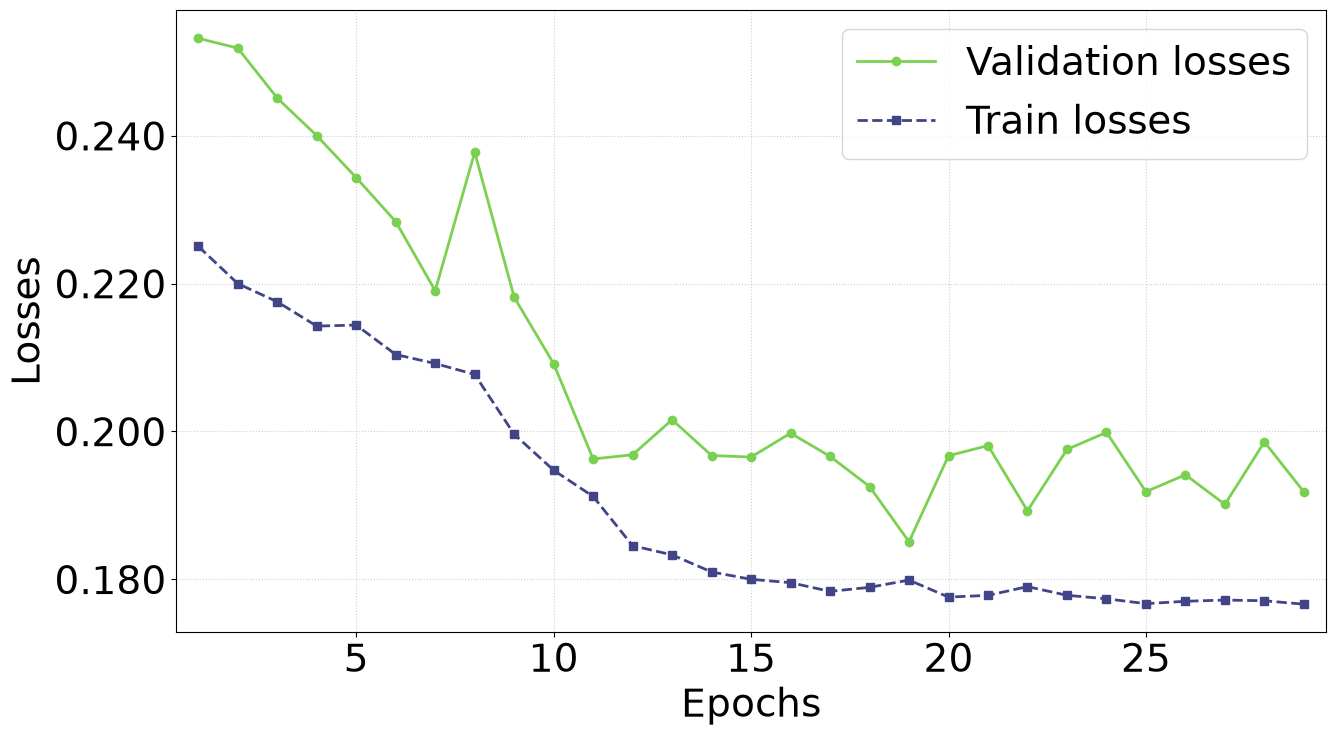

L=7:  val loss 0.1851 |  train loss 0.1799 | avg loss 0.2105  +- 0.0240  | accuracy = 0.737 | auc 0.921 | epochs 29


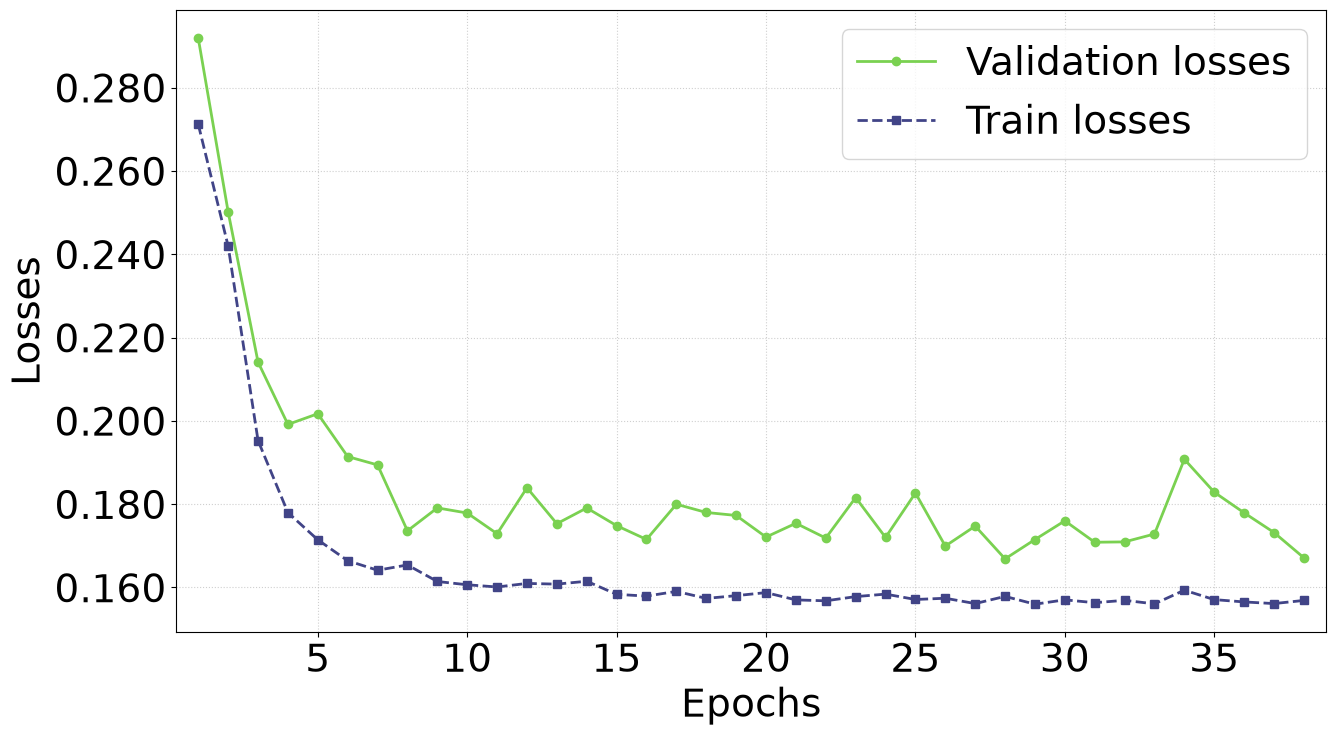

L=8:  val loss 0.1669 |  train loss 0.1579 | avg loss 0.1909  +- 0.0308  | accuracy = 0.767 | auc 0.945 | epochs 38


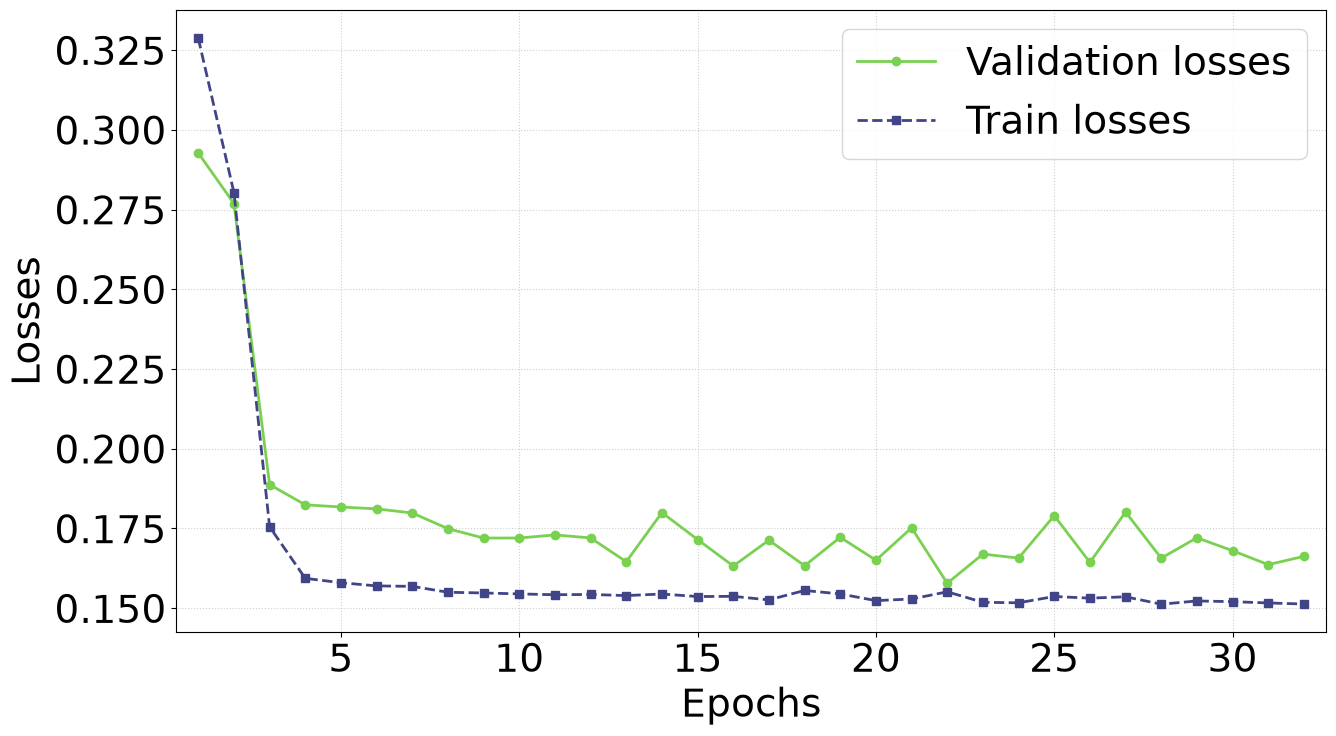

L=9:  val loss 0.1578 |  train loss 0.1551 | avg loss 0.1782  +- 0.0285  | accuracy = 0.773 | auc 0.955 | epochs 32


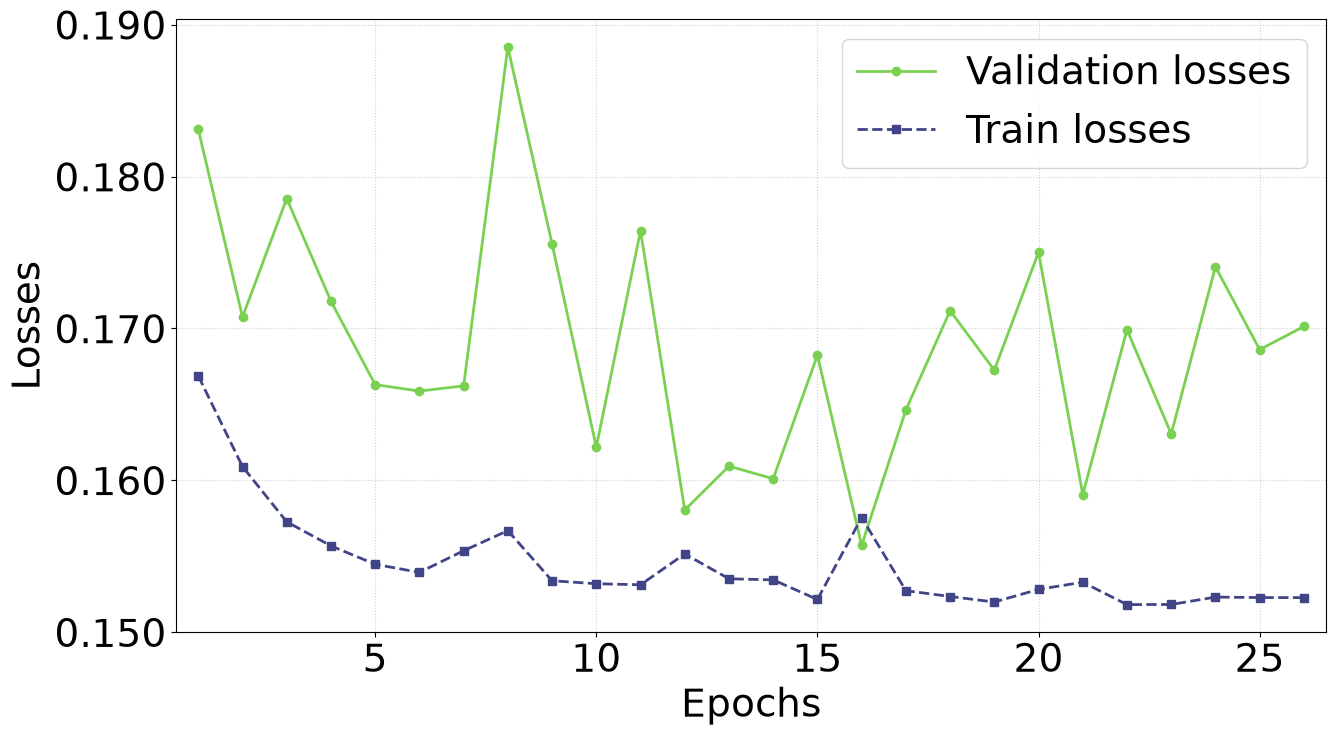

L=10:  val loss 0.1557 |  train loss 0.1575 | avg loss 0.1718  +- 0.0326  | accuracy = 0.765 | auc 0.950 | epochs 26
model angle-twolocal-2


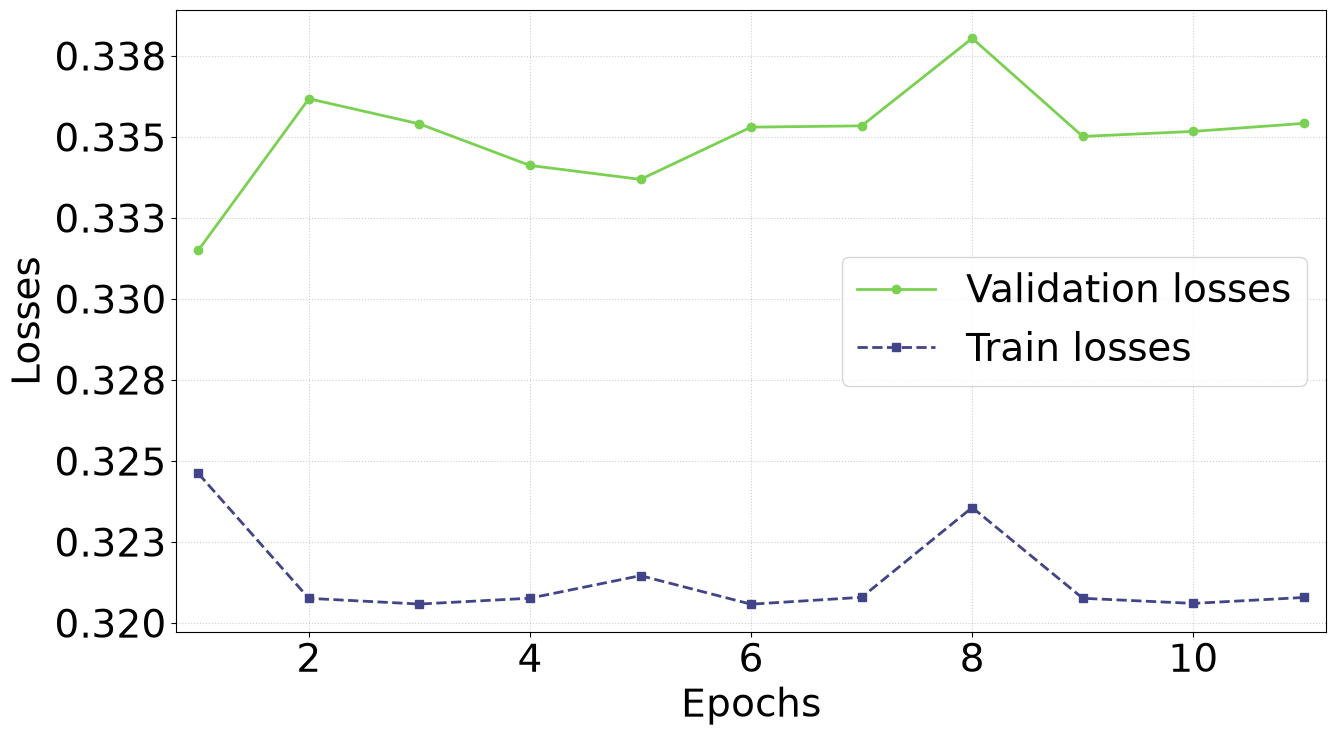

L=1:  val loss 0.3315 |  train loss 0.3246 | avg loss 0.3339  +- 0.0007  | accuracy = 0.577 | auc 0.759 | epochs 11


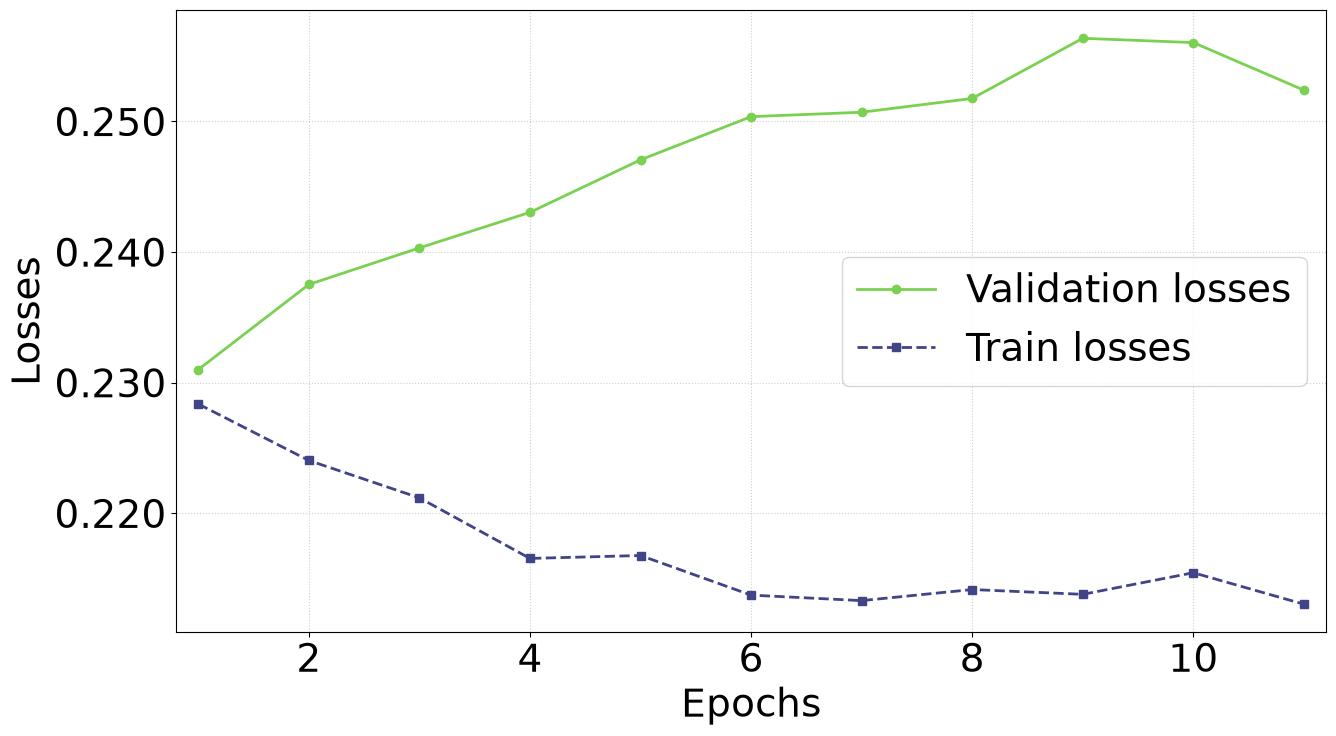

L=2:  val loss 0.2310 |  train loss 0.2284 | avg loss 0.2451  +- 0.0036  | accuracy = 0.703 | auc 0.846 | epochs 11


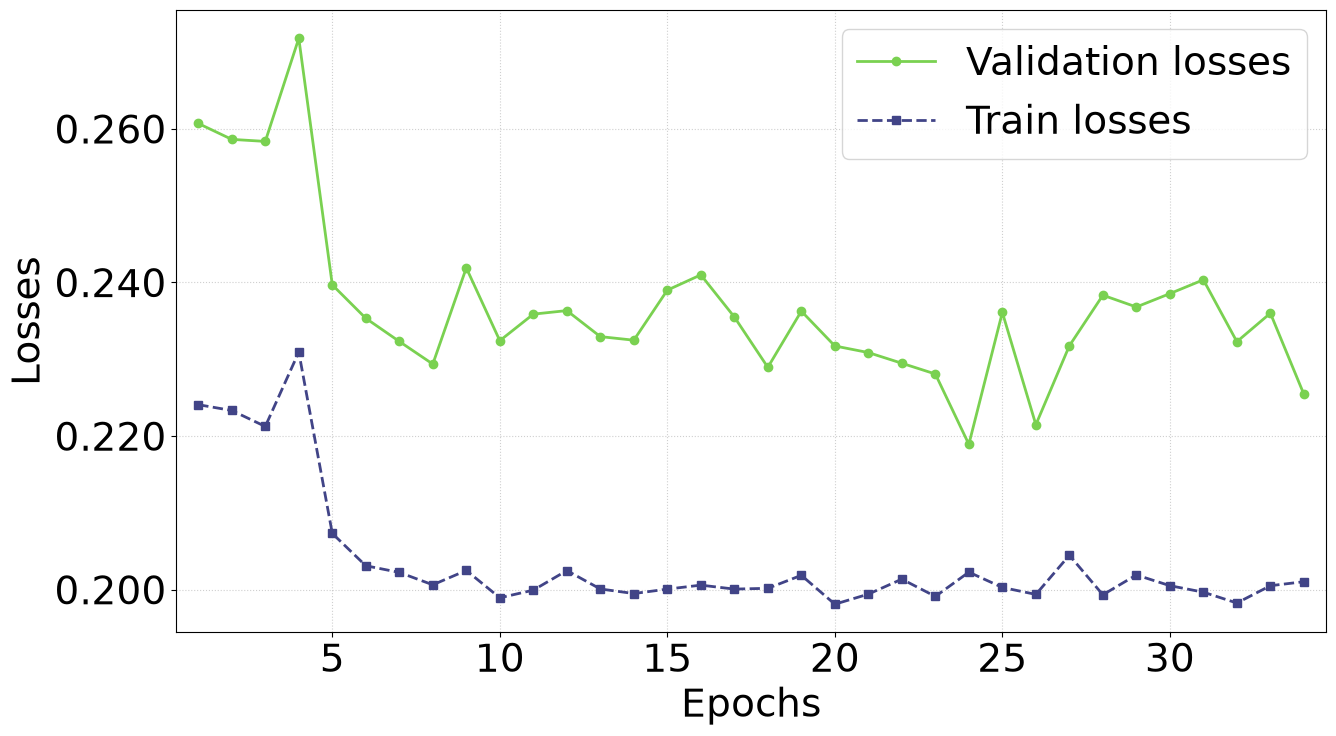

L=3:  val loss 0.2189 |  train loss 0.2023 | avg loss 0.2276  +- 0.0057  | accuracy = 0.720 | auc 0.901 | epochs 34


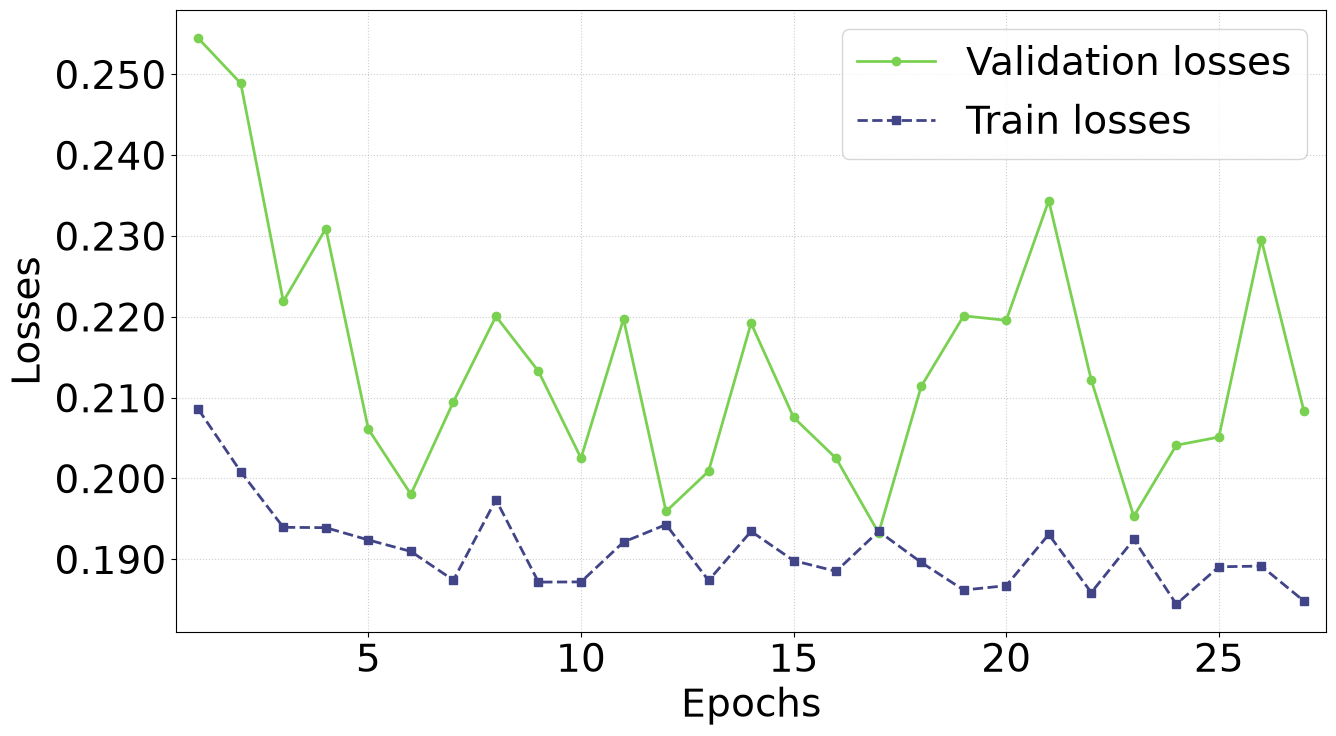

L=4:  val loss 0.1933 |  train loss 0.1935 | avg loss 0.2023  +- 0.0037  | accuracy = 0.730 | auc 0.917 | epochs 27


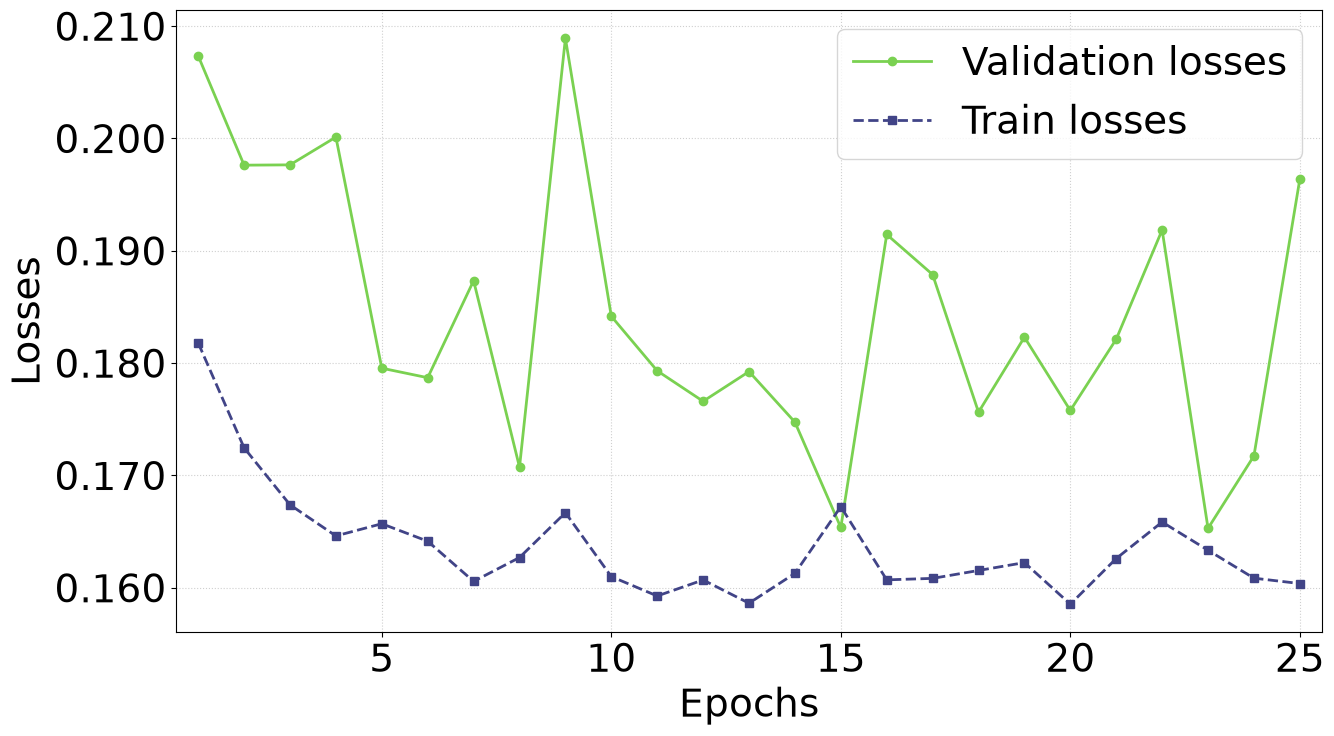

L=5:  val loss 0.1653 |  train loss 0.1672 | avg loss 0.1761  +- 0.0068  | accuracy = 0.760 | auc 0.930 | epochs 25


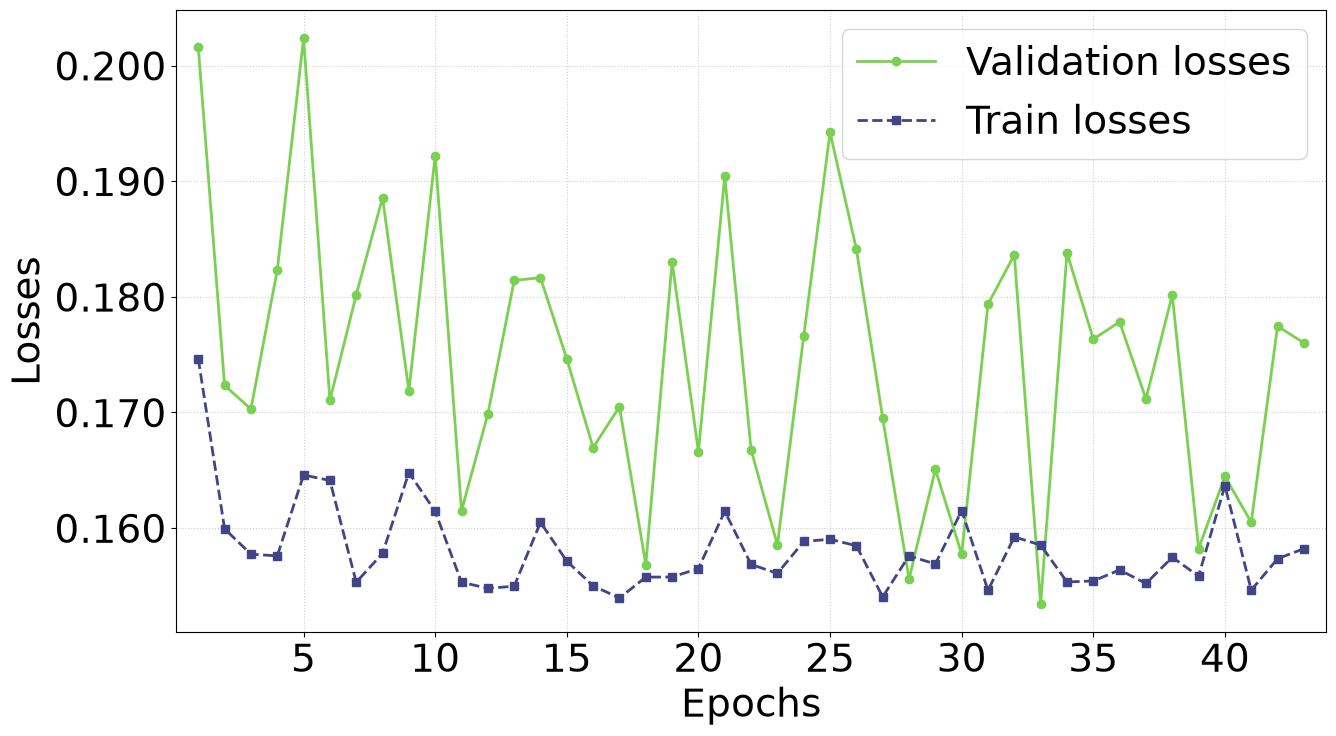

L=6:  val loss 0.1534 |  train loss 0.1585 | avg loss 0.1623  +- 0.0058  | accuracy = 0.765 | auc 0.949 | epochs 43


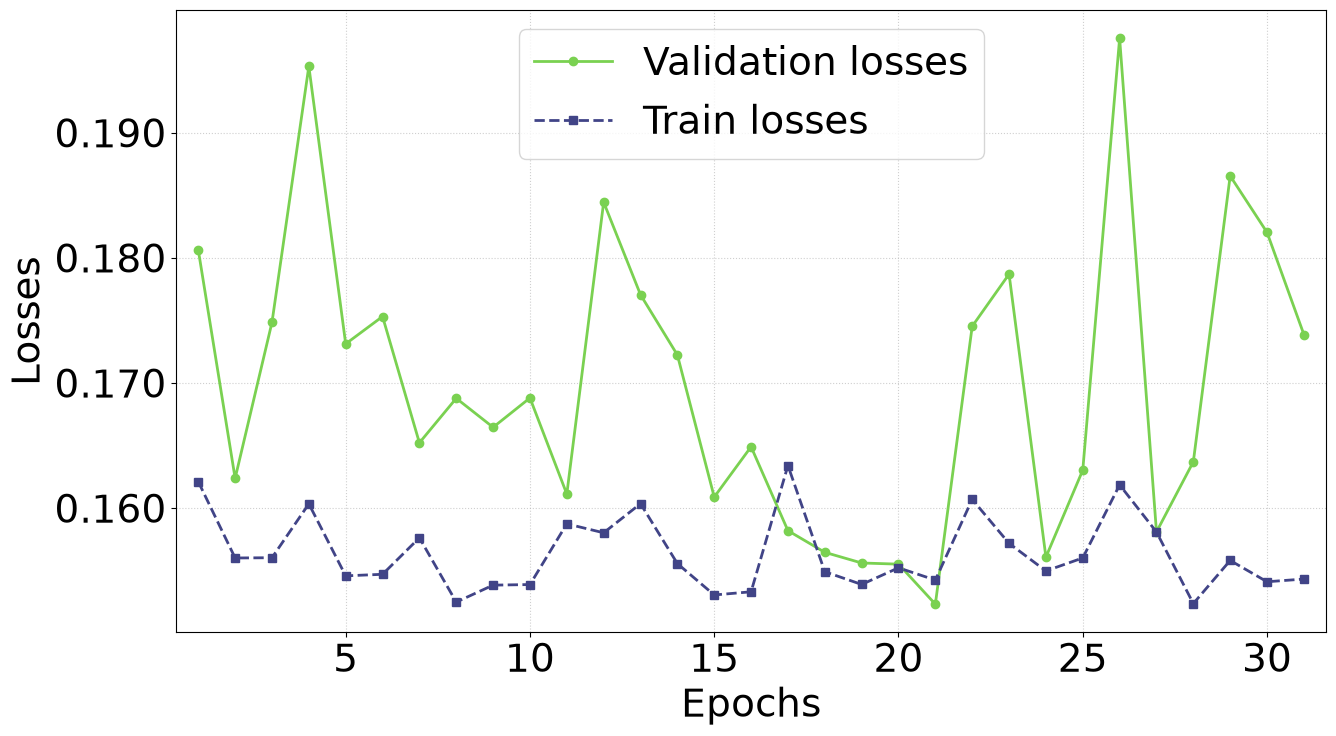

L=7:  val loss 0.1523 |  train loss 0.1542 | avg loss 0.1571  +- 0.0027  | accuracy = 0.774 | auc 0.958 | epochs 31


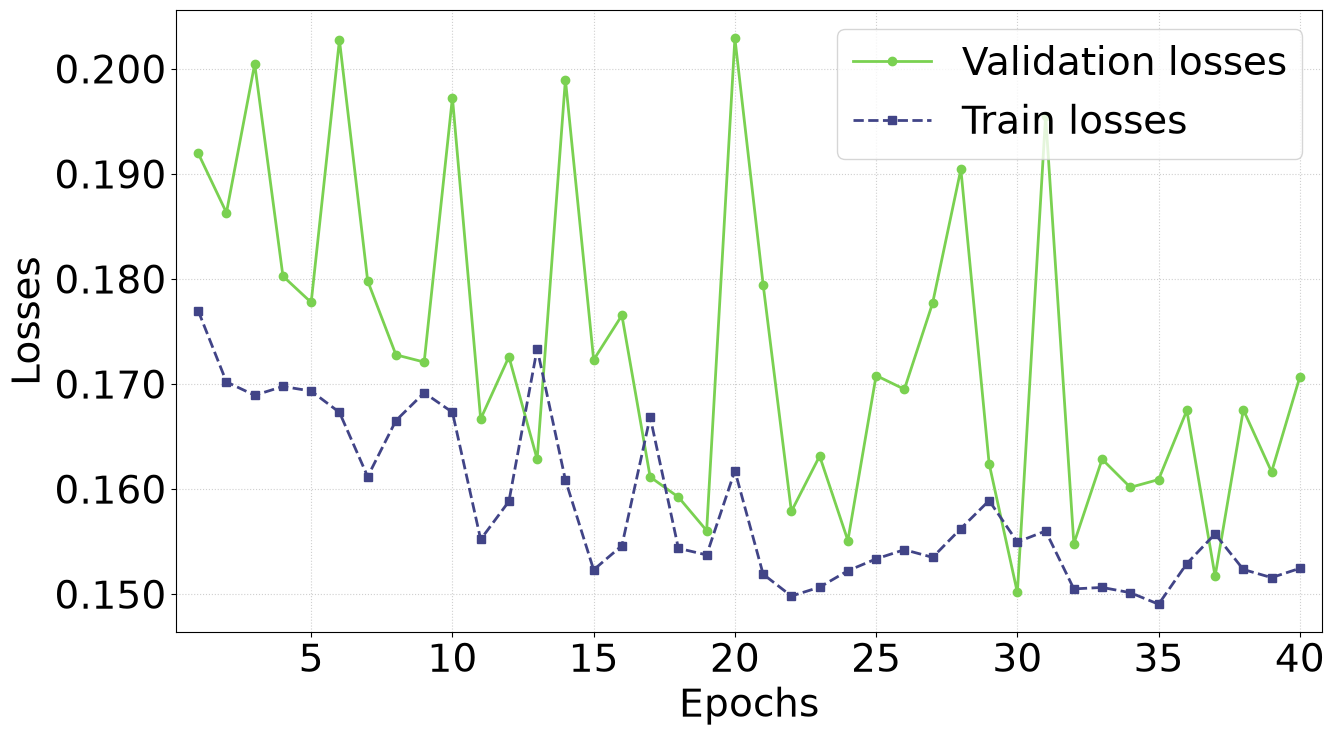

L=8:  val loss 0.1501 |  train loss 0.1549 | avg loss 0.1552  +- 0.0030  | accuracy = 0.777 | auc 0.953 | epochs 40


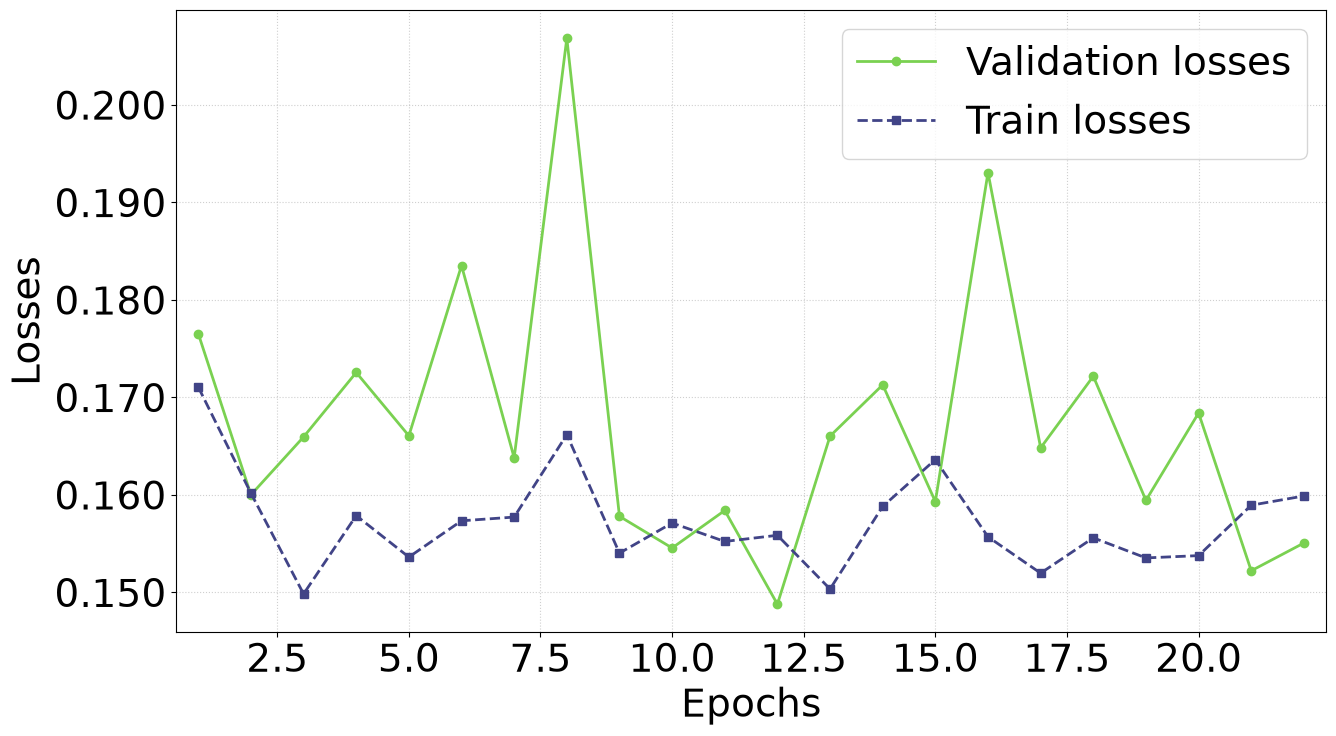

L=9:  val loss 0.1488 |  train loss 0.1558 | avg loss 0.1553  +- 0.0035  | accuracy = 0.777 | auc 0.953 | epochs 22


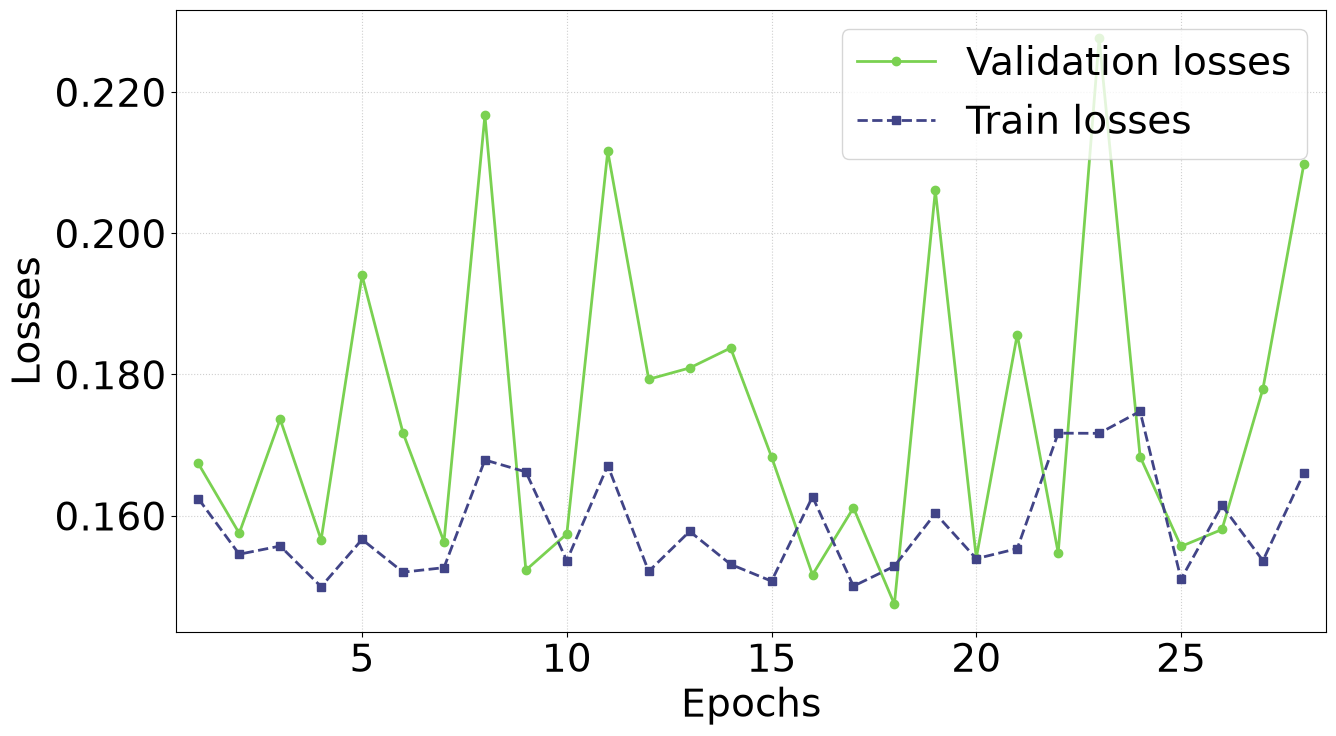

L=10:  val loss 0.1475 |  train loss 0.1529 | avg loss 0.1547  +- 0.0040  | accuracy = 0.776 | auc 0.959 | epochs 28
model angle-treetensor


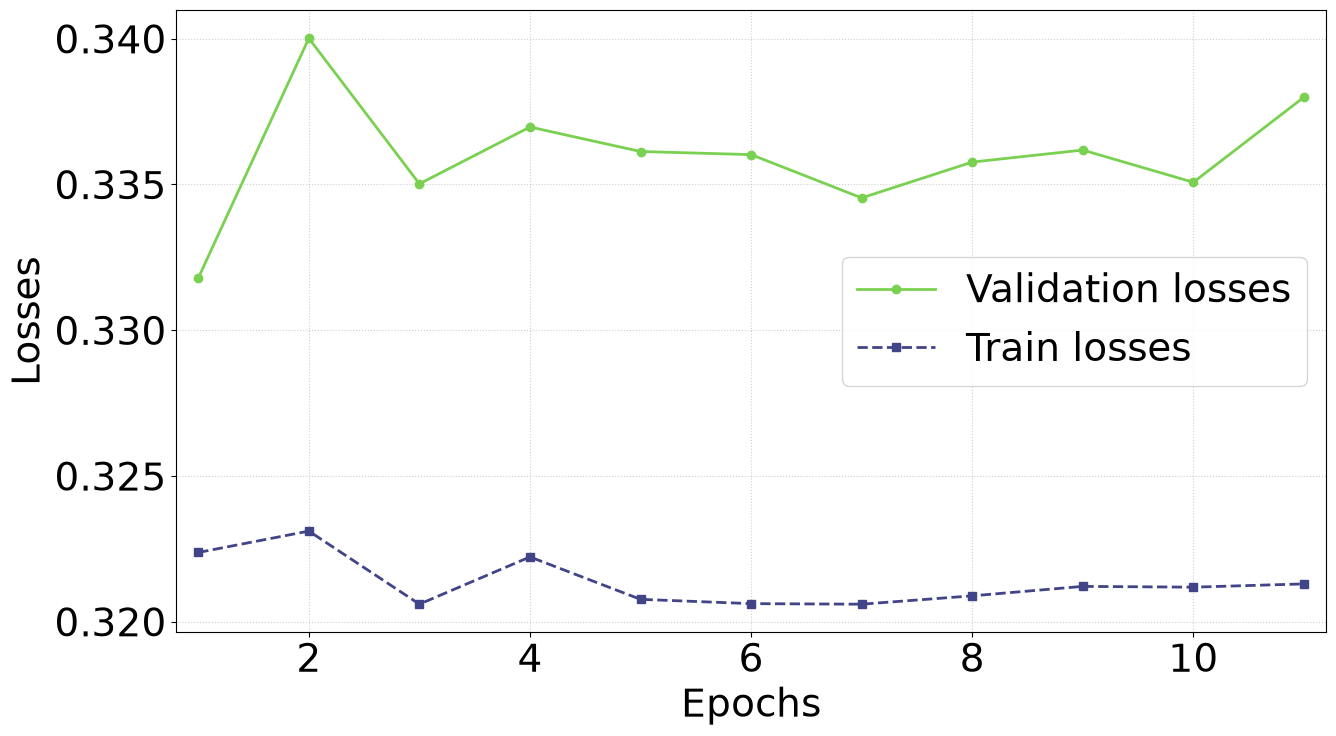

L=1:  val loss 0.3318 |  train loss 0.3224 | avg loss 0.3339  +- 0.0007  | accuracy = 0.575 | auc 0.752 | epochs 11


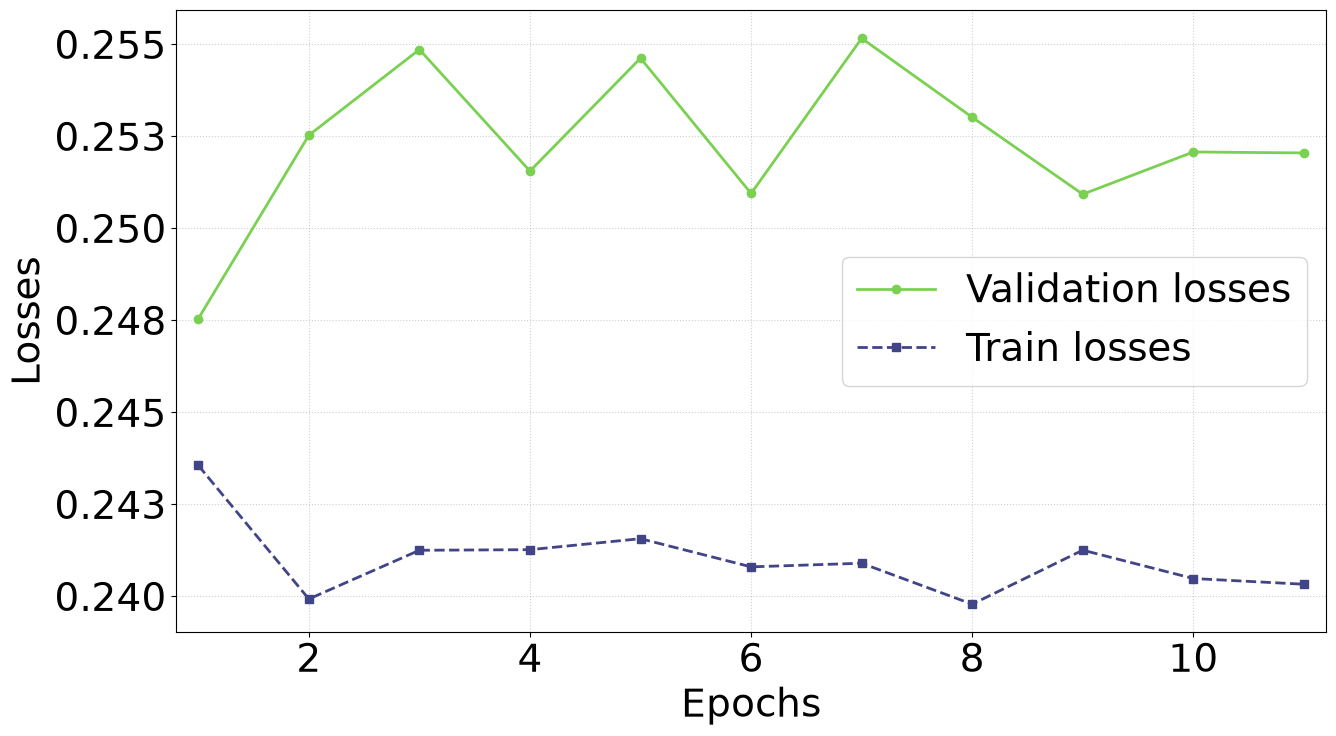

L=2:  val loss 0.2475 |  train loss 0.2436 | avg loss 0.2530  +- 0.0070  | accuracy = 0.683 | auc 0.784 | epochs 11


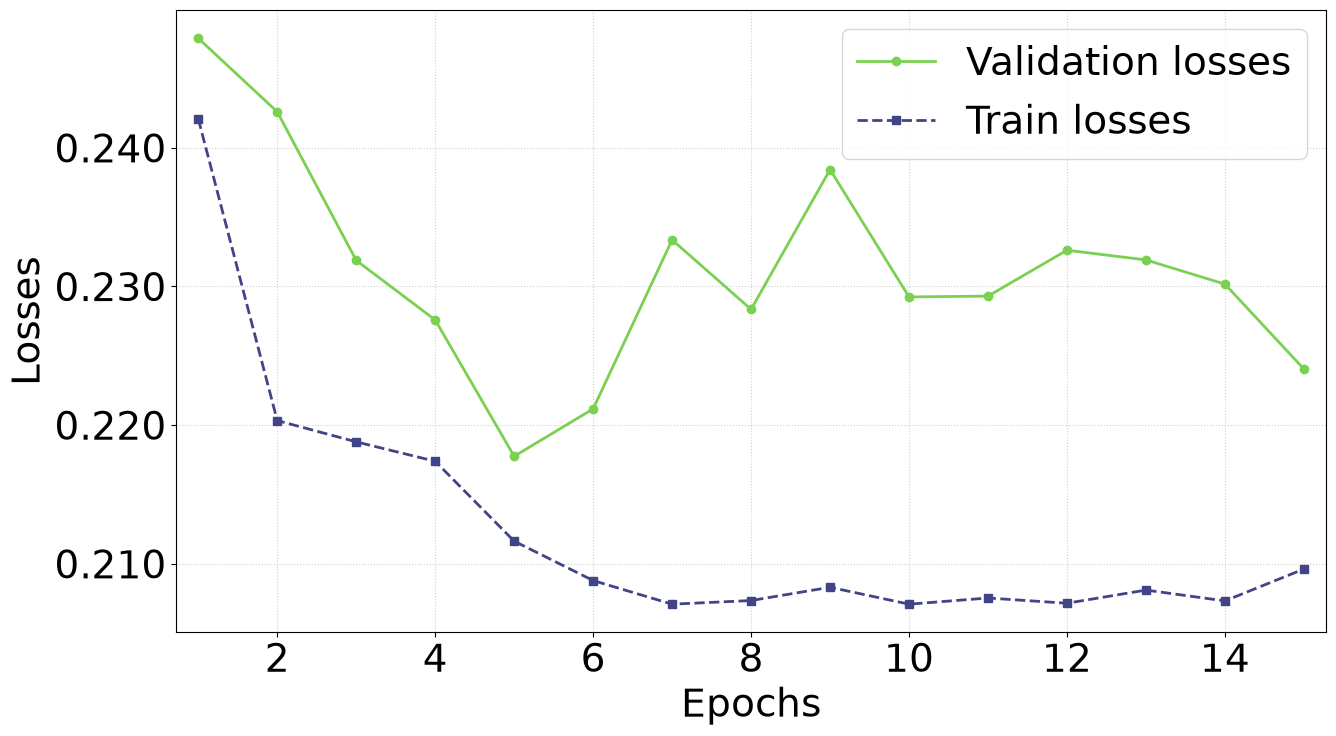

L=3:  val loss 0.2177 |  train loss 0.2116 | avg loss 0.2328  +- 0.0077  | accuracy = 0.700 | auc 0.875 | epochs 15


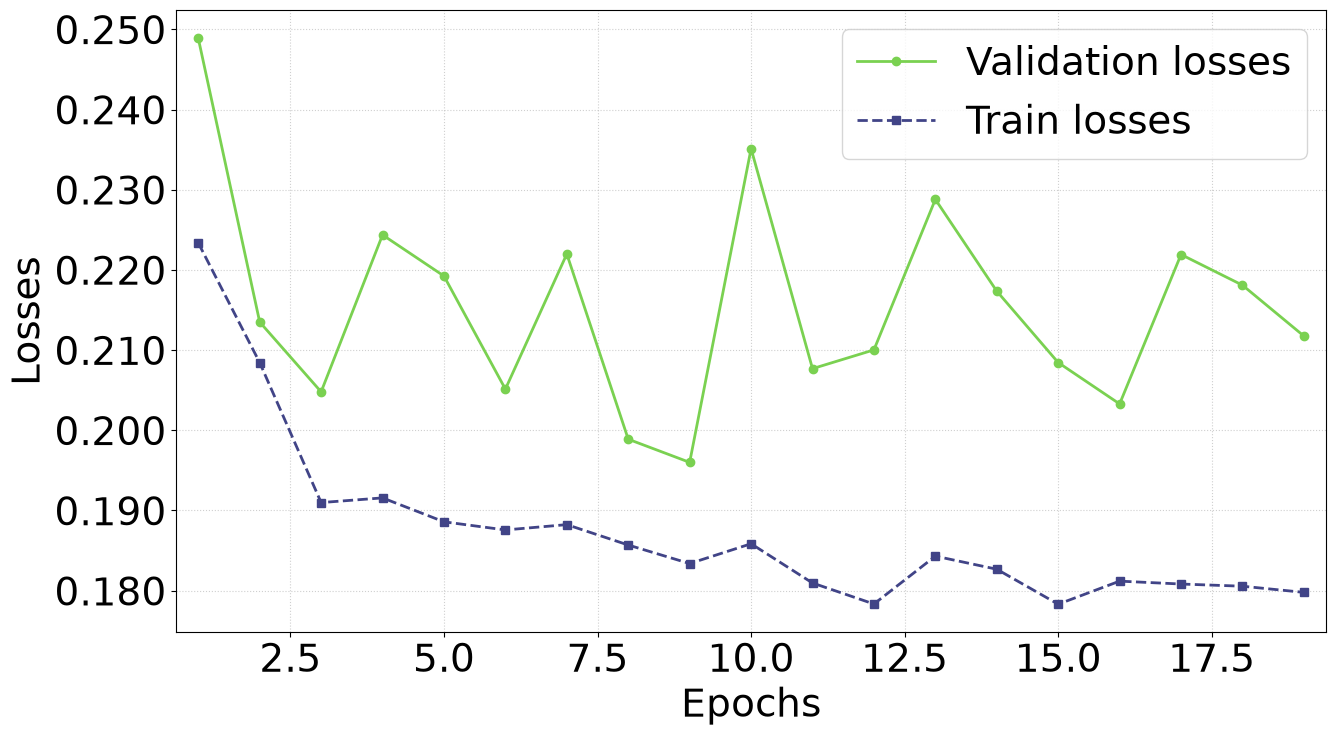

L=4:  val loss 0.1960 |  train loss 0.1834 | avg loss 0.2208  +- 0.0136  | accuracy = 0.727 | auc 0.904 | epochs 19


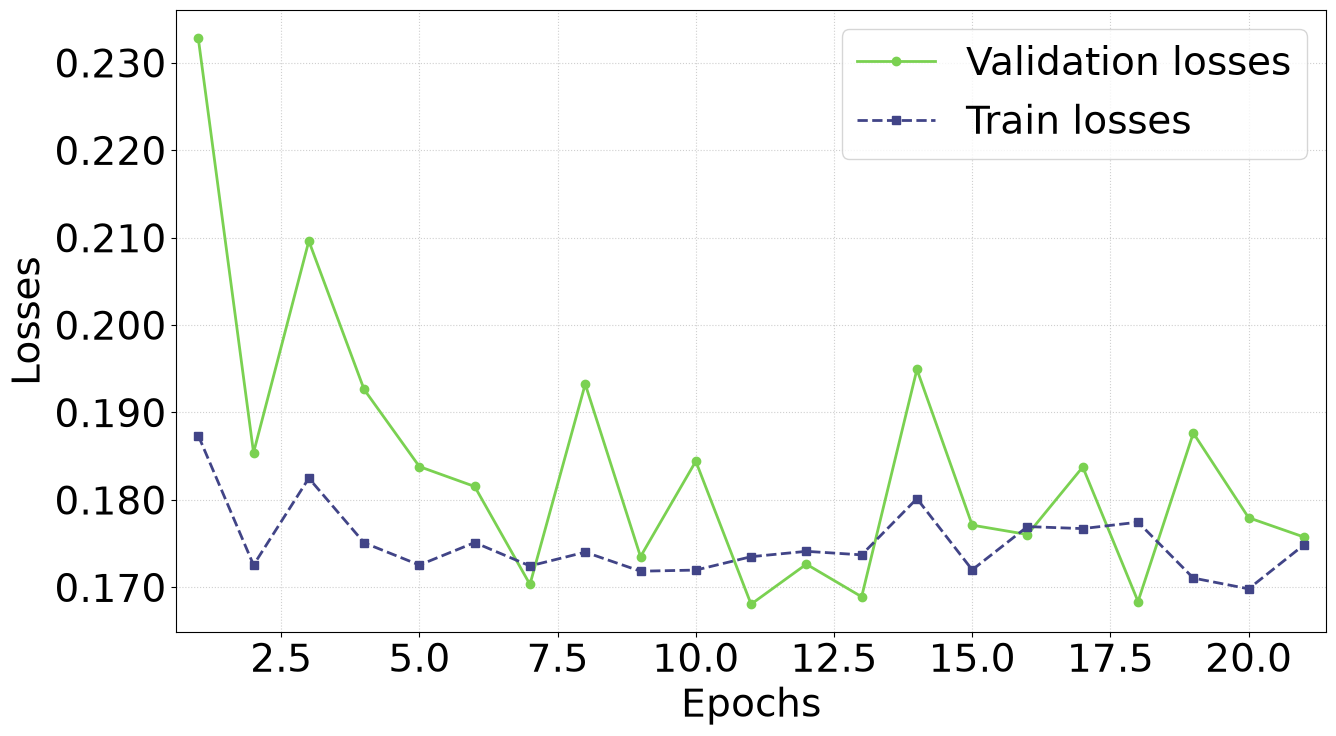

L=5:  val loss 0.1681 |  train loss 0.1735 | avg loss 0.2031  +- 0.0156  | accuracy = 0.757 | auc 0.921 | epochs 21


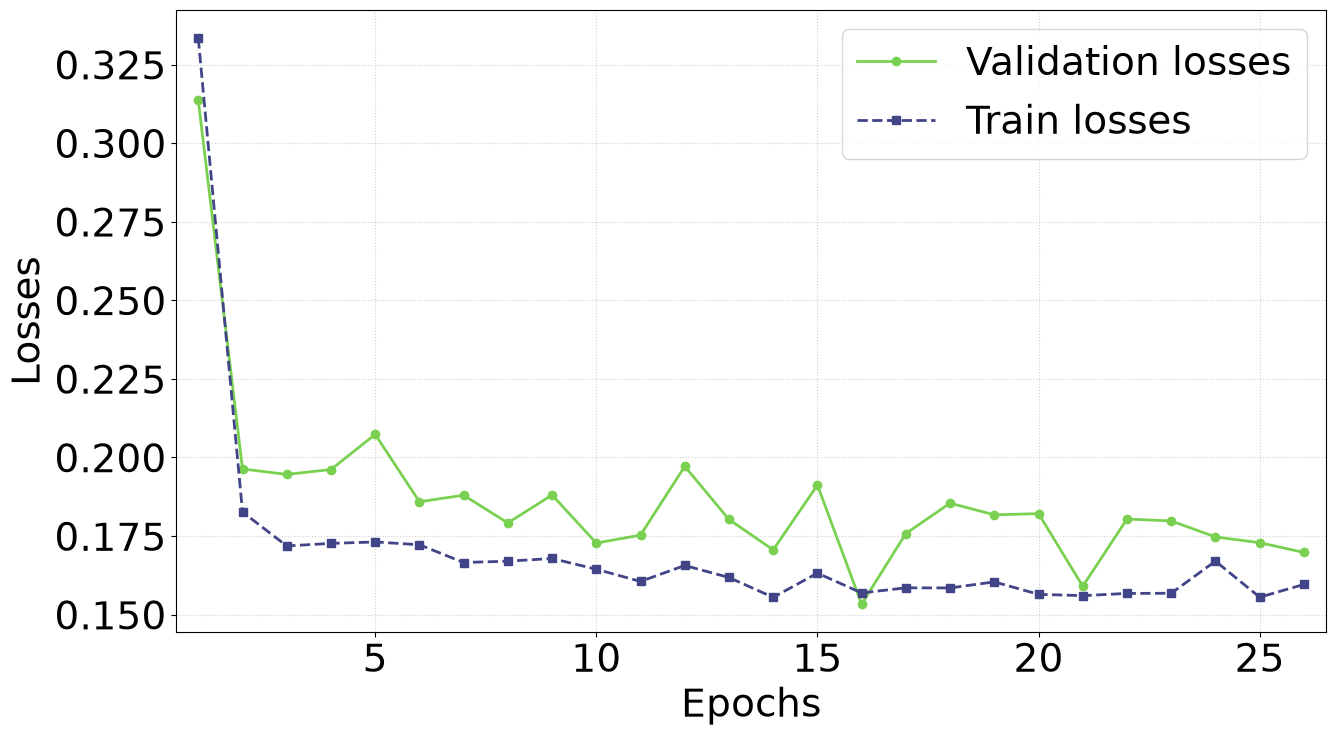

L=6:  val loss 0.1533 |  train loss 0.1569 | avg loss 0.1988  +- 0.0398  | accuracy = 0.782 | auc 0.943 | epochs 26


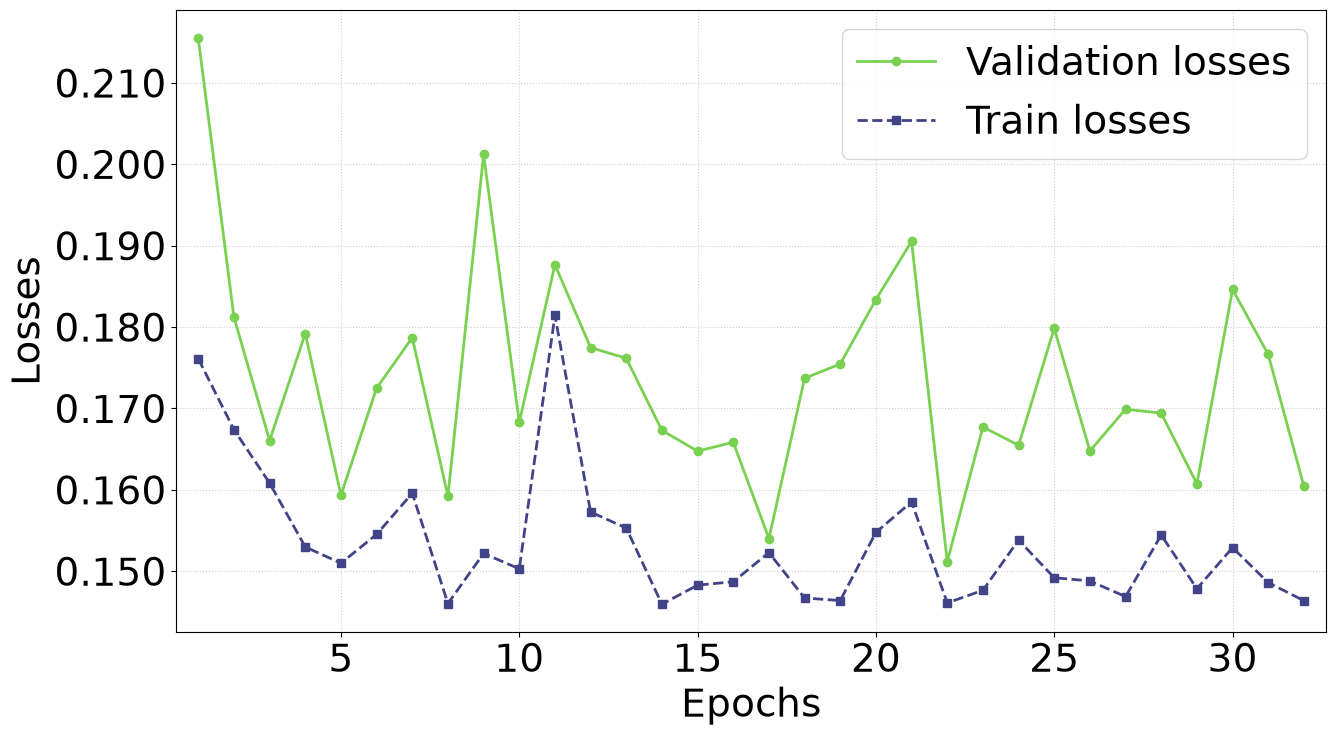

L=7:  val loss 0.1511 |  train loss 0.1461 | avg loss 0.2005  +- 0.0502  | accuracy = 0.788 | auc 0.938 | epochs 32


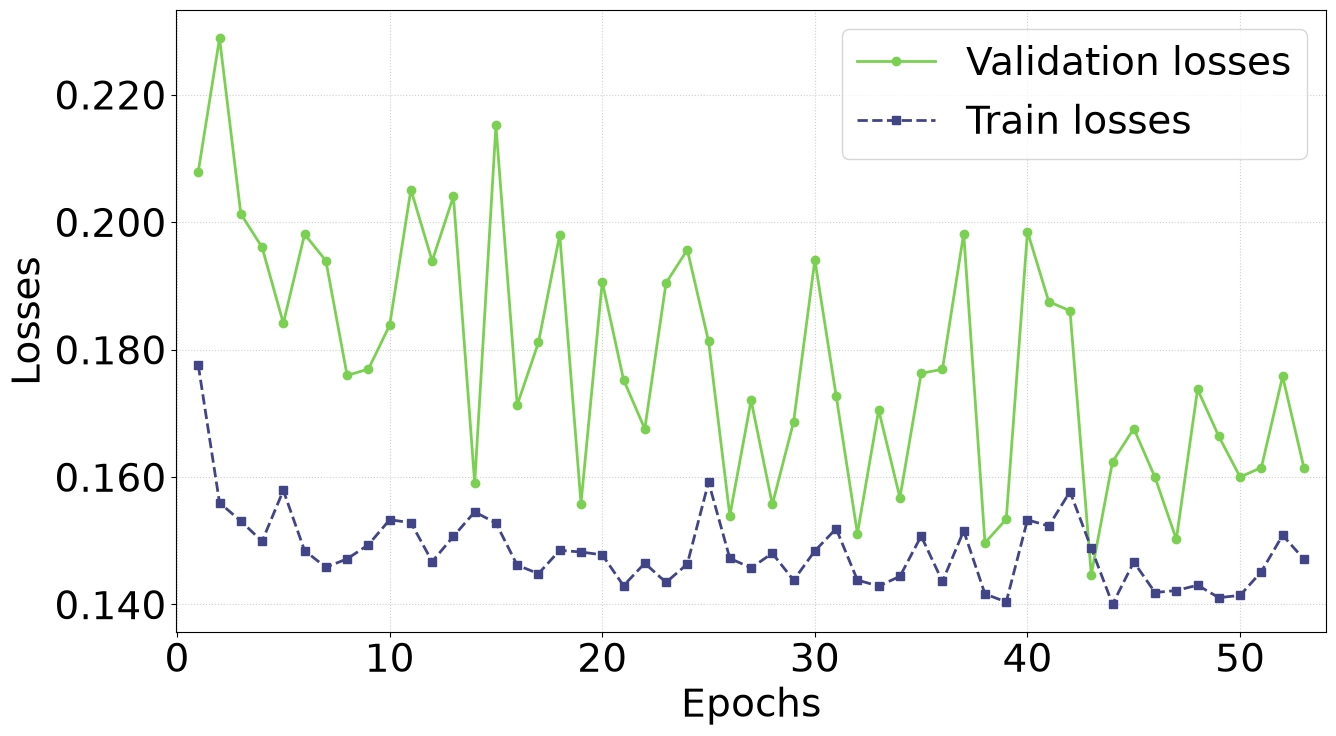

L=8:  val loss 0.1447 |  train loss 0.1488 | avg loss 0.1854  +- 0.0448  | accuracy = 0.796 | auc 0.948 | epochs 53


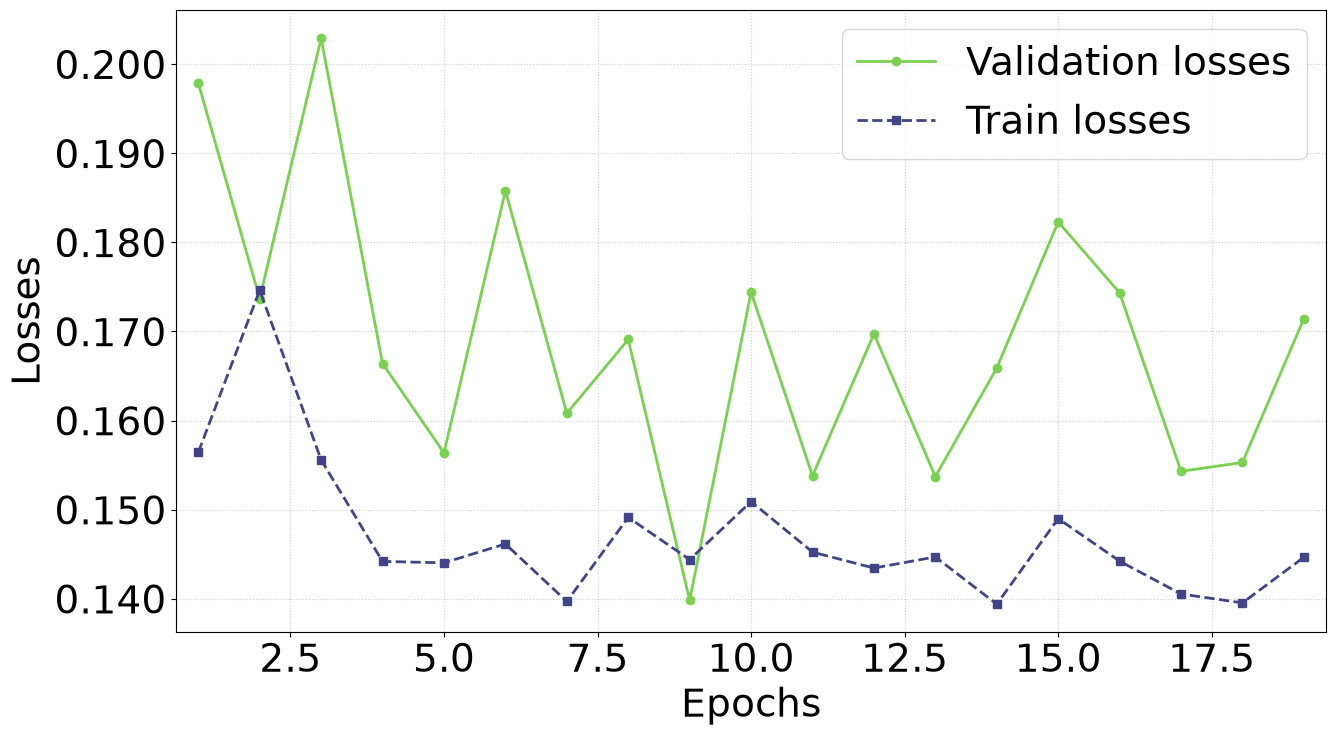

L=9:  val loss 0.1398 |  train loss 0.1444 | avg loss 0.1951  +- 0.0546  | accuracy = 0.792 | auc 0.943 | epochs 19


In [ ]:
result = run_layers(models=models_sim, dataset=dataset)
